
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

# ---------------------------------------------------------------------------
# Parameter logic used in this revised notebook
# ---------------------------------------------------------------------------
# HTFLOOKBACKDAYS = 20  -> daily structural context; long enough to capture recent
#                          multi-session liquidity, short enough to avoid stale zones.
# LTFLOOKBACKDAYS = 10  -> hourly local context; shorter than HTF so sweep detection
#                          reacts to recent intraday behaviour around higher-timeframe zones.
# VOLROLLWINDOW  = 20   -> activity baseline only; this smooths volume and does not define
#                          the structural zone horizon.
# HTFPIVOTWINDOW = 5    -> balanced confirmation for daily swings.
# LTFPIVOTWINDOW = 35   -> stricter hourly pivots to reduce noise in TSLA intraday bars.
# SWEEPTRENDLOOKBACK = 10 -> short trend context before a sweep/reversal setup.



## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [44]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml
%pip install --upgrade nbformat ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : D:\DSBS\RMSC6007\Project\RMSC6007_Liquidity-Zones\data\raw


In [2]:
# ===========================================================================
# Zone Data Structure (Mutable Class)
# ===========================================================================

class Zone:
    """
    Mutable zone object storing liquidity level state and lifecycle metrics.
    Uses __slots__ for memory efficiency and performance.
    Includes decay factor for automatic zone expiration after HTF_LOOKBACK_DAYS.
    """
    __slots__ = [
        'top', 'bottom', 'height', 'touches',
        'first_idx', 'last_idx', 
        'first_time', 'last_time',
        'total_volume', 'avg_volume', 'avg_absorption',
        'zone_type', 
        'pattern_strength', 'volume_confirmation', 'institutional_score', 'composite_score',
        'is_double_top', 'is_double_bottom',
        'formation_volume_ratio',
        'zone_id', 'origin_vol', 'market_vol_baseline', 'state',
        'volume_node_score', 'strength', 'any_double', 'zone_side',
        'zone_age_bars', 'zone_lifecycle_phase', 'decay_factor', 'is_expired'
    ]
    
    def __init__(self, top, bottom, touches, first_idx, last_idx, first_time, last_time,
                 total_volume, avg_volume, zone_type, pattern_strength=0.0,
                 volume_confirmation=0.0, institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False, formation_volume_ratio=None,
                 zone_id=None, origin_vol=0.0, market_vol_baseline=0.0, state='active',
                 decay_factor=1.0, is_expired=False):
        """Initialize Zone with all attributes, including decay factor for time-based expiration."""
        self.top = top
        self.bottom = bottom
        self.height = abs(top - bottom)  # Price range of zone
        self.touches = touches
        self.first_idx = first_idx
        self.last_idx = last_idx
        self.first_time = first_time
        self.last_time = last_time
        self.total_volume = total_volume
        self.avg_volume = avg_volume
        self.zone_type = zone_type
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top
        self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id
        self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline
        self.state = state
        
        # Dynamic attributes (set later during processing)
        self.avg_absorption = 0.0
        self.volume_node_score = 0.0
        self.strength = 0.0
        self.any_double = False
        self.zone_side = 'neutral'
        self.zone_age_bars = 0
        self.zone_lifecycle_phase = 'established'
        self.decay_factor = decay_factor  # Time-based decay: 1.0 (fresh) -> 0.0 (expired)
        self.is_expired = is_expired      # True if zone age > HTF_LOOKBACK_DAYS
    
    def calculate_decay(self, current_time, lookback_days=20):
        """Calculate decay factor based on zone age. Returns 1.0 (fresh) to 0.0 (expired)."""
        days_old = (current_time - self.first_time).days
        if days_old >= lookback_days:
            self.is_expired = True
            self.decay_factor = 0.0
        elif days_old > 0:
            # Linear decay: 1.0 at day 0, 0.0 at day lookback_days
            self.decay_factor = max(0.0, 1.0 - (days_old / lookback_days))
        else:
            self.decay_factor = 1.0
        return self.decay_factor
    
    def to_dict(self):
        """Convert Zone to dictionary for DataFrame storage."""
        return {slot: getattr(self, slot) for slot in self.__slots__}
    
    def __repr__(self):
        return f"Zone(top={self.top}, bottom={self.bottom}, height={self.height}, touches={self.touches}, zone_id={self.zone_id})"


In [3]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
# Revised parameter logic: keep structural memory separate from activity baselines.
# Daily zones use a 20-trading-day rolling context, hourly sweeps use a 10-trading-day
# local context, and 20-bar volume windows are used only for smoothing/standardisation.
VOL_ROLL_WINDOW        = 20    # rolling window for average volume; smooths single-bar noise to give a reliable activity baseline
MIDAS_ROLLING_WINDOW   = 20    # rolling window for MIDAS preprocessing; matches HTF lookback for consistency
VOL_SPIKE_THRESHOLD    = 1.5   # vol_ratio >= threshold marks a spike; bars above this likely reflect institutional participation
USE_VOL_FILTER         = True  # when True, only sweeps with elevated volume are flagged, filtering low-conviction breakouts
VOL_PROFILE_BIN_PCT    = 0.2   # 0.2% of rolling average price for percentage-based POC binning

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True  # when True, enrich zones and sweeps with MIDAS institutional microstructure features;
                  # enables side-by-side comparison of analysis with and without order-level data

# ---------------------------------------------------------------------------
# Multi-day liquidity sweep detection config
# ---------------------------------------------------------------------------
# HTF (High Timeframe): Daily data — structural liquidity zone identification (20-day rolling lookback)
# LTF (Low Timeframe): Hourly data — sweep detection on multi-day zones (30-hour rolling window)

# Layer 1: Price-based patterns detection      
# Layer 2: Volume-related features   
# Layer 3: Microstructure metrics from MIDAS

# HTF Liquidity Zone Identification (structural context)
# Detects 30+ day liquidity levels that persist across multiple trading sessions
HTF_ABSORPTION_SCORE = 0.10   # Absorption filter for daily zones 
HTF_PIVOT_WINDOW = 5          # 2 bars for daily pivot detection
HTF_VOL_MULT = 1.0            # Standard volume multiplier for daily zones
HTF_MIN_TOUCHES = 1           # Minimum touches for zone confirmation on daily
HTF_LOOKBACK_DAYS = 20        # 20-day rolling lookback for zone identification (multi-day structure)
HTF_ZONE_EXPIRY_DAYS = 365     # Daily zones live for up to 1 year

# LTF Liquidity Zone Identification (to skip or use LTF zones as a confluence filter for sweeps???)
LTF_ABSORPTION_SCORE = 0.30   # Absorption score threshold for hourly sweeps
LTF_PIVOT_WINDOW = 35         # 35 bars each side for hourly pivot detection
LTF_VOL_MULT = 1.2            # Volume multiplier for hourly sweeps
LTF_MIN_TOUCHES = 1           # Minimum touches for hourly zone confirmation
LTF_LOOKBACK_DAYS = 10        # 10-day rolling window for multi-day sweep detection
LTF_ZONE_EXPIRY_DAYS = 30    # Hourly zones fade within a month

# Volume analysis config for sweep detection
VOL_PROFILE_BIN_PCT = 0.2     # 0.2% of rolling average price for percentage-based POC binning in sweep detection;
VOL_ZSCORE_WINDOW = 20        # 20-hour window for volume z-score baseline (institutional spike detection)
RSI_PERIOD = 20               # RSI(20) over 20-hour window for momentum confirmation
MOMENTUM_PERIOD = 20          # Rate of change window (hours)

MIDAS_CONFIRM_FIELD  = "hidden_rate_avg"  # Layer 3: MIDAS zone column used for institutional enrichment filtering;
                                          # options: "hidden_rate_avg"      (dark-pool execution fraction)
                                          #          "cancel_to_trade_avg"  (algo probing / spoofing intensity)
                                          #          "fill_rate_avg"        (inverse: low fill = iceberg/spoof)

MIDAS_CONFIRM_PCT    = 35    # Layer 3: percentile threshold for the MIDAS institutional filter (0–100):
                              #   50 = keep zones above median institutional activity (moderate filter)
                              #   75 = keep only top quartile (strict — fewer, higher-conviction zones)


print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"\nHTF (Daily) config  : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS} days")
print(f"LTF (Hourly) config : pivot_window={LTF_PIVOT_WINDOW}  |  absorption={LTF_ABSORPTION_SCORE}  |  lookback={LTF_LOOKBACK_DAYS} days")
print(f"MIDAS filter: {MIDAS_CONFIRM_FIELD} at {MIDAS_CONFIRM_PCT}th percentile")

Vol window : 20  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS data : enabled

HTF (Daily) config  : pivot_window=5  |  absorption=0.1  |  lookback=20 days
LTF (Hourly) config : pivot_window=35  |  absorption=0.3  |  lookback=10 days
MIDAS filter: hidden_rate_avg at 35th percentile


In [4]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [5]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from D:\DSBS\RMSC6007\Project\RMSC6007_Liquidity-Zones\data\TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [6]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data\raw\TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data\raw\TSLA_hourly_2021-01-04_2024-09-30.csv


In [7]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
print(reload_daily.head(3))
print("Hourly head:")
print(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:
                 Close        High         Low        Open     Volume
Datetime                                                             
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
Hourly head:
                       Open    High     Low   Close % Change    Volume
Datetime                                                              
2021-01-04 09:30:00  239.68  247.91  239.06  246.72    2.94%  48538308
2021-01-04 10:30:00  246.67  248.16  242.75  245.21   -0.59%  25522500
2021-01-04 11:30:00  245.11  245.25  239.35  241.28   -1.56%  21004254


In [8]:

# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

midas_df = None  # Initialize to None (will be populated only if USE_MIDAS is True and file loads successfully)

if USE_MIDAS:
    try:
        # Try to load MIDAS data
        midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
        midas_df["date"] = pd.to_datetime(midas_df["date"])
        midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
        midas_df.index = midas_df.index.normalize()   # strip any time-of-day component
        
        print(f"✓ MIDAS data loaded successfully")
        print(f"  Rows       : {len(midas_df)}")
        print(f"  Date range : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
        print(f"  Columns    : {midas_df.columns.tolist()}")
        print(midas_df.describe().round(3))
        
    except FileNotFoundError as e:
        print(f"⚠ WARNING: MIDAS file not found: {MIDAS_PATH}")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis (zones and sweeps will be detected without institutional microstructure)")
        midas_df = None
        USE_MIDAS = False
        
    except KeyError as e:
        print(f"⚠ WARNING: MIDAS sheet '{MIDAS_SHEET}' or columns not found")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
        
    except Exception as e:
        print(f"⚠ WARNING: Unexpected error loading MIDAS data: {type(e).__name__}: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
else:
    print("USE_MIDAS = False — MIDAS data not loaded.")


✓ MIDAS data loaded successfully
  Rows       : 941
  Date range : 2021-01-04 -> 2024-09-30
  Columns    : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']
       Cancel_to_Trade  Hidden_Rate  Hidden_Volume  Trade_to_Order_Volume  \
count          941.000      941.000        941.000                941.000   
mean            18.853       30.190         25.196                  3.608   
std              6.782        8.664          6.648                  1.441   
min              5.700       12.183         10.479                  1.115   
25%             13.630       21.986         19.441                  2.498   
50%             18.270       31.953         25.270                  3.318   
75%             22.839       38.154         30.926                  4.519   
max             46.722       45.673         44.220                 10.498   

       Oddlot_Rate  Oddlot_Volume  
count      941.000        941.000  
mean        82.085

## Part 2 — Data Processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes


In [9]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (941, 5)
Date range: 2021-01-04 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
        Close    High     Low    Open        Volume
count  941.00  941.00  941.00  941.00  9.410000e+02
mean   237.46  242.79  232.06  237.60  1.008086e+08
std     54.69   56.12   53.31   54.89  4.023200e+07
min    108.10  111.75  101.81  103.00  2.940180e+07
25%    197.41  201.78  192.20  197.32  7.114590e+07
50%    233.94  238.47  228.18  233.87  9.391650e+07
75%    266.68  273.17  261.20  267.48  1.208318e+08
max    409.97  414.50  405.67  411.47  3.065906e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (6577, 6)
Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Open     

In [10]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    hourly_fill_vol = daily_vol / 7
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 941

Hourly volume:
  Missing values: 0
  Zero values: 264
  Total valid: 6313

→ Found 264 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 264 bars
  - 138 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 137473011


In [11]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2021-01-04     145914600    138854073.0                   1.0
2021-01-05      96735600     87119124.0                   1.0
2021-01-06     134100000    129531942.0                   1.0
2021-01-07     154496700    145369788.0                   1.0
2021-01-08     225166500    219834303.0                   1.0
2021-01-11     177904800    172612128.0                   1.0
2021-01-12     138812100    132122601.0                   1.0
2021-01-13      99937500     94706133.0                   1.0
2021-01-14      93798900     91119210.0                   1.0
2021-01-15     116332800    111465387.0                   1.0

Average Hourly/Daily ratio: 0.9329
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


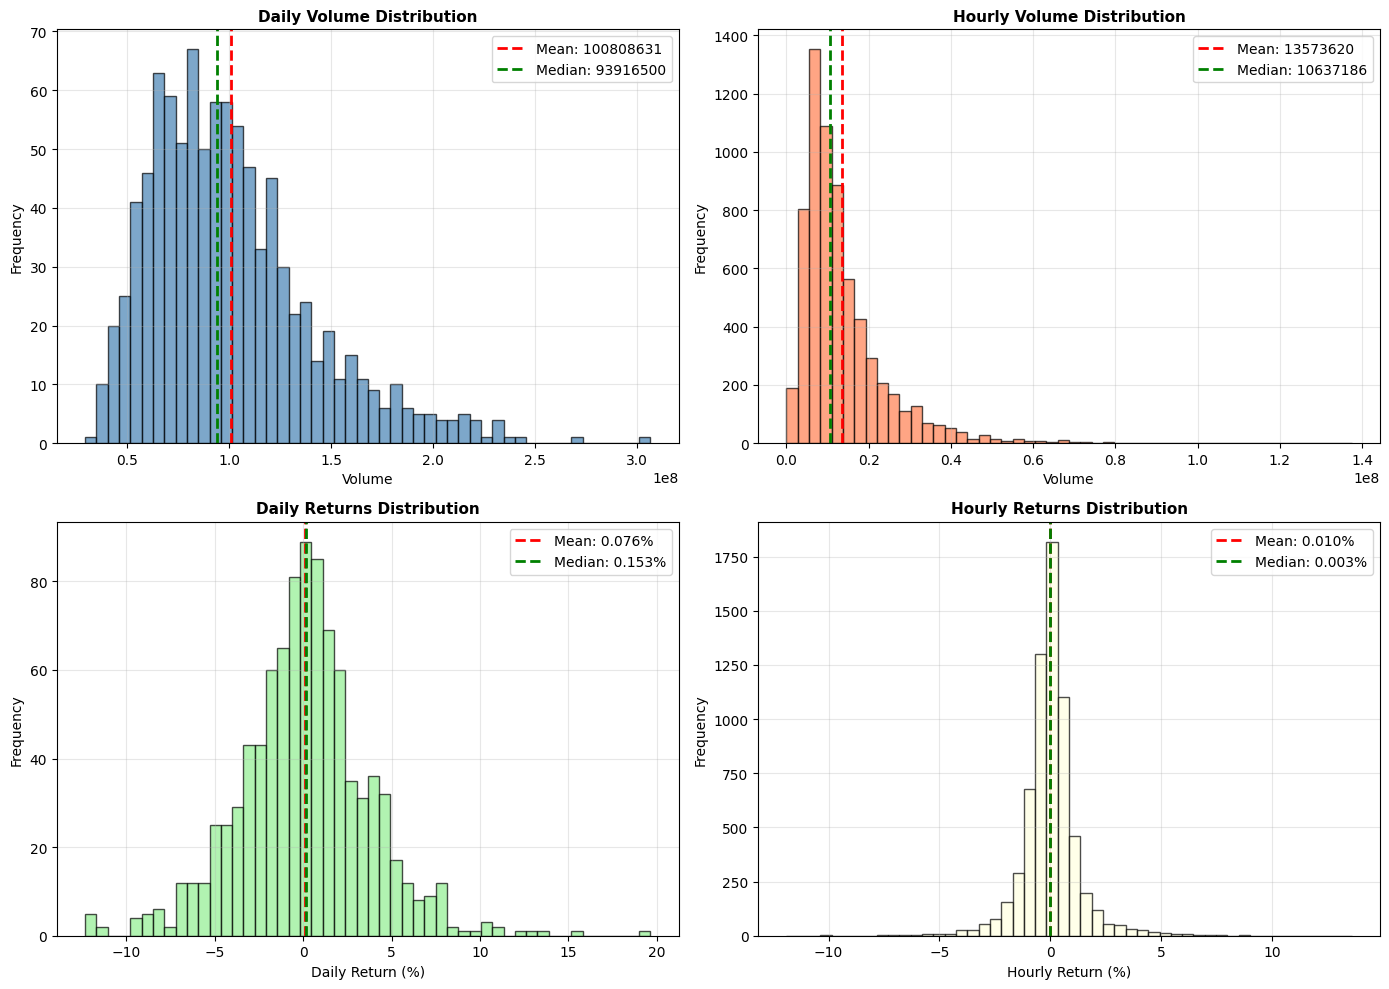

Saved: outputs/eda_distributions.png


In [12]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


MIDAS DATA SANITY CHECK

1. MISSING VALUES (NaN) CHECK:
----------------------------------------------------------------------
  ✓ Cancel_to_Trade               :    0 NaN (  0.00%)
  ✓ Hidden_Rate                   :    0 NaN (  0.00%)
  ✓ Hidden_Volume                 :    0 NaN (  0.00%)
  ✓ Trade_to_Order_Volume         :    0 NaN (  0.00%)
  ✓ Oddlot_Rate                   :    0 NaN (  0.00%)
  ✓ Oddlot_Volume                 :    0 NaN (  0.00%)

  Total NaN: 0.00% of all data points

2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):
----------------------------------------------------------------------
  MIDAS rows        : 941
  Daily trading days: 941
  Hourly trading days: 941
  MIDAS date range  : 2021-01-04 to 2024-09-30
  Daily date range  : 2021-01-04 to 2024-09-30

  Days in DAILY but NOT in MIDAS: 0
  Days in MIDAS but NOT in DAILY: 0
  Alignment: 100.0% of daily dates have MIDAS data

3. SUMMARY STATISTICS:
---------------------------------------------------------------

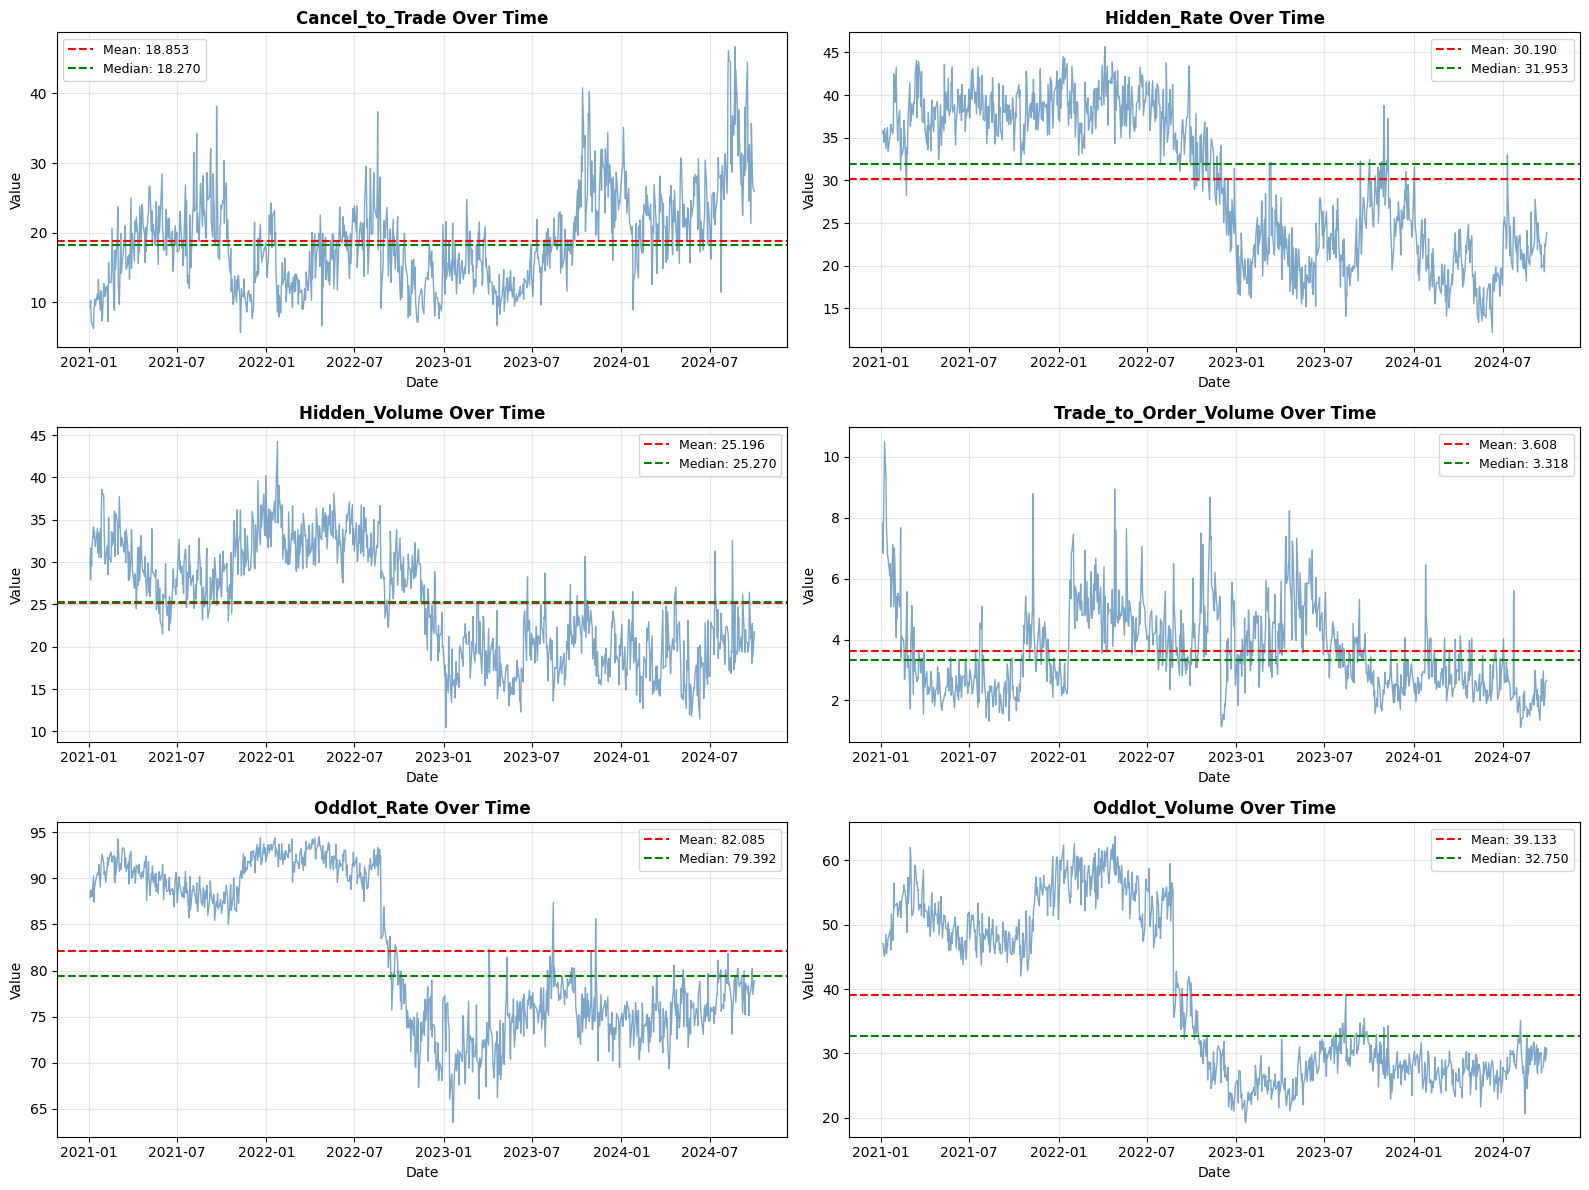


  ✓ Saved: outputs/midas_sanity_check_timeseries.png


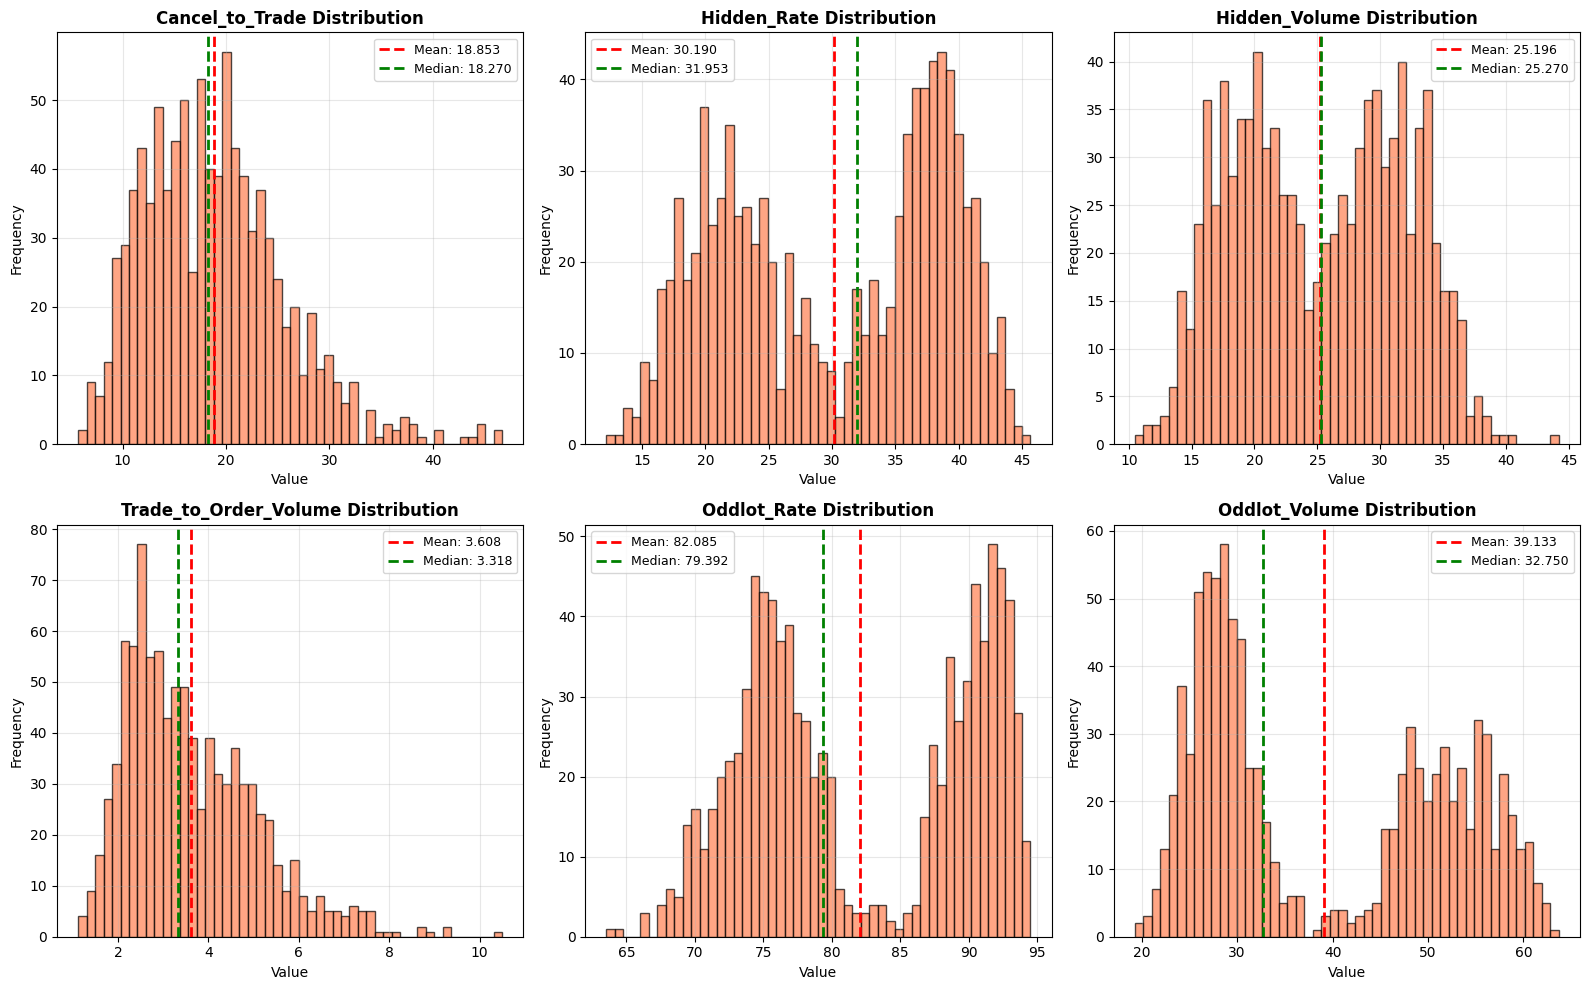

  ✓ Saved: outputs/midas_sanity_check_distributions.png


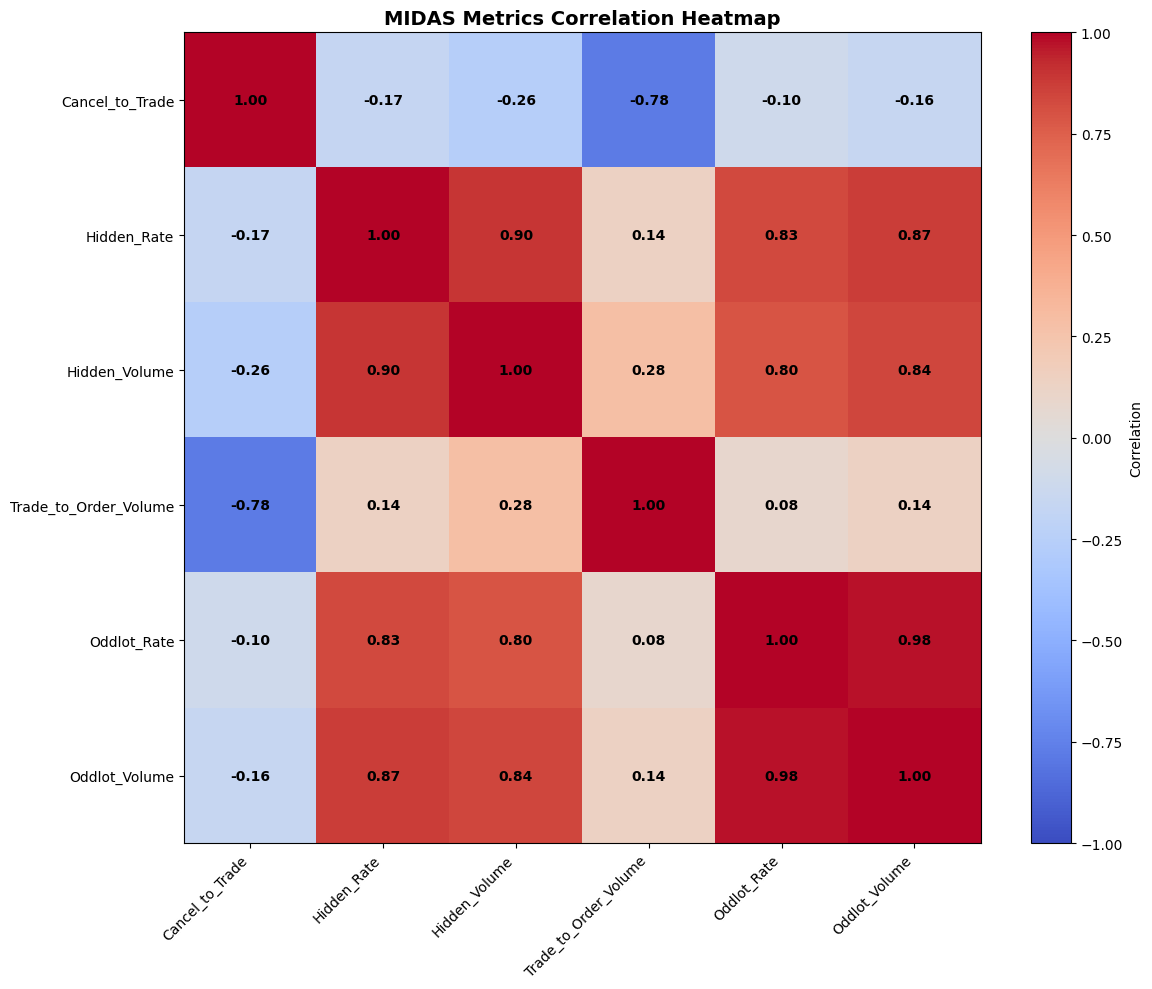

  ✓ Saved: outputs/midas_sanity_check_correlation.png

MIDAS SANITY CHECK SUMMARY

✓ MIDAS data validation complete!
  - 941 rows loaded
  - 6 metrics available
  - Date alignment: 100.0% with daily data
  - Average NaN percentage: 0.00%
  - Ready for zone enrichment and filtering (Layer 3)


In [13]:
# ---------------------------------------------------------------------------
# MIDAS Data Sanity Check
# ---------------------------------------------------------------------------
# Comprehensive validation of MIDAS data for alignment, completeness, and quality

if midas_df is not None and not midas_df.empty and USE_MIDAS:
    print("\n" + "="*70)
    print("MIDAS DATA SANITY CHECK")
    print("="*70)
    
    # ─────────────────────────────────────────────────────────────────────
    # 1. MISSING/NAN VALUES CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n1. MISSING VALUES (NaN) CHECK:")
    print("-" * 70)
    
    nan_counts = midas_df.isnull().sum()
    nan_pct = (nan_counts / len(midas_df)) * 100
    
    for col in midas_df.columns:
        nan_cnt = nan_counts[col]
        nan_p = nan_pct[col]
        status = "✓" if nan_p == 0 else "⚠" if nan_p < 20 else "✗"
        print(f"  {status} {col:30s}: {nan_cnt:4d} NaN ({nan_p:6.2f}%)")
    
    total_nan_pct = (midas_df.isnull().sum().sum() / (len(midas_df) * len(midas_df.columns))) * 100
    print(f"\n  Total NaN: {total_nan_pct:.2f}% of all data points")
    
    # ─────────────────────────────────────────────────────────────────────
    # 2. DATE ALIGNMENT CHECK (MIDAS vs Price Data)
    # ─────────────────────────────────────────────────────────────────────
    print("\n2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):")
    print("-" * 70)
    
    midas_dates = set(midas_df.index.date)
    daily_dates = set(reload_daily.index.date)
    hourly_dates = set(reload_hourly.index.date)
    
    dates_in_daily_not_midas = daily_dates - midas_dates
    dates_in_midas_not_daily = midas_dates - daily_dates
    dates_in_hourly_not_midas = hourly_dates - midas_dates
    
    print(f"  MIDAS rows        : {len(midas_df)}")
    print(f"  Daily trading days: {len(daily_dates)}")
    print(f"  Hourly trading days: {len(hourly_dates)}")
    print(f"  MIDAS date range  : {midas_df.index.min().date()} to {midas_df.index.max().date()}")
    print(f"  Daily date range  : {reload_daily.index.min().date()} to {reload_daily.index.max().date()}")
    
    print(f"\n  Days in DAILY but NOT in MIDAS: {len(dates_in_daily_not_midas)}")
    if len(dates_in_daily_not_midas) > 0 and len(dates_in_daily_not_midas) <= 10:
        print(f"    → {sorted(dates_in_daily_not_midas)[:5]}" + ("..." if len(dates_in_daily_not_midas) > 5 else ""))
    
    print(f"  Days in MIDAS but NOT in DAILY: {len(dates_in_midas_not_daily)}")
    if len(dates_in_midas_not_daily) > 0 and len(dates_in_midas_not_daily) <= 10:
        print(f"    → {sorted(dates_in_midas_not_daily)[:5]}" + ("..." if len(dates_in_midas_not_daily) > 5 else ""))
    
    alignment_pct = (len(midas_dates & daily_dates) / len(daily_dates)) * 100 if daily_dates else 0
    print(f"  Alignment: {alignment_pct:.1f}% of daily dates have MIDAS data")
    
    # ─────────────────────────────────────────────────────────────────────
    # 3. SUMMARY STATISTICS (count, mean, median, min, max, std)
    # ─────────────────────────────────────────────────────────────────────
    print("\n3. SUMMARY STATISTICS:")
    print("-" * 70)
    
    stats_df = midas_df.describe().round(4)
    print(stats_df.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 4. PERCENTILE RANKS & OUTLIERS CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n4. PERCENTILE DISTRIBUTION & OUTLIERS:")
    print("-" * 70)
    
    for col in midas_df.columns:
        col_data = midas_df[col].dropna()
        if len(col_data) == 0:
            continue
        
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)  # median
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        outliers_low = (col_data < lower_fence).sum()
        outliers_high = (col_data > upper_fence).sum()
        total_outliers = outliers_low + outliers_high
        outlier_pct = (total_outliers / len(col_data)) * 100
        
        print(f"\n  {col}:")
        print(f"    Percentiles: Q1={q1:.4f}, Q2(Median)={q2:.4f}, Q3={q3:.4f}")
        print(f"    IQR={iqr:.4f}, Outlier Fences: [{lower_fence:.4f}, {upper_fence:.4f}]")
        print(f"    Outliers: {total_outliers} ({outlier_pct:.2f}%) [Low: {outliers_low}, High: {outliers_high}]")
    
    # ─────────────────────────────────────────────────────────────────────
    # 5. CORRELATION MATRIX (Relationship between MIDAS metrics)
    # ─────────────────────────────────────────────────────────────────────
    print("\n5. CORRELATION BETWEEN MIDAS METRICS:")
    print("-" * 70)
    
    corr_matrix = midas_df.corr().round(3)
    print(corr_matrix.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 6. VISUALIZATIONS
    # ─────────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    # Create a comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 6a. Time series of each MIDAS metric
    for idx, col in enumerate(midas_df.columns):
        ax = plt.subplot(3, 2, idx + 1)
        ax.plot(midas_df.index, midas_df[col], linewidth=1, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} Over Time', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3)
        
        # Add mean and median lines
        mean_val = midas_df[col].mean()
        median_val = midas_df[col].median()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
        ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  ✓ Saved: outputs/midas_sanity_check_timeseries.png")
    
    # 6b. Distribution histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(midas_df.columns):
        ax = axes[idx]
        col_data = midas_df[col].dropna()
        ax.hist(col_data, bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.axvline(col_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {col_data.mean():.3f}')
        ax.axvline(col_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {col_data.median():.3f}')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Remove extra subplot
    if len(midas_df.columns) < 6:
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_distributions.png")
    
    # 6c. Heatmap of correlation matrix
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values in cells
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title('MIDAS Metrics Correlation Heatmap', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_correlation.png")
    
    # ─────────────────────────────────────────────────────────────────────
    # SUMMARY
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MIDAS SANITY CHECK SUMMARY")
    print("="*70)
    
    print(f"\n✓ MIDAS data validation complete!")
    print(f"  - {len(midas_df)} rows loaded")
    print(f"  - {len(midas_df.columns)} metrics available")
    print(f"  - Date alignment: {alignment_pct:.1f}% with daily data")
    print(f"  - Average NaN percentage: {total_nan_pct:.2f}%")
    print(f"  - Ready for zone enrichment and filtering (Layer 3)")
    
else:
    print("\n⚠ MIDAS data not available for sanity check (midas_df is None or empty)")

In [14]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
date,,,,,,
2021-01-04,9.230069,35.772576,30.521597,7.828468,87.947450,47.103830
2021-01-05,10.303195,35.458893,27.879749,6.831907,88.720227,47.017219
2021-01-06,8.304282,35.778200,31.633233,8.004737,88.665709,46.150634
2021-01-07,7.020428,34.469931,29.535346,9.314816,88.091067,45.249066
2021-01-08,7.009115,36.076460,31.920673,10.498168,88.009125,45.116434


In [15]:
# =========================================================================
# DIAGNOSTIC: Distribution Analysis & Skewness Assessment
# =========================================================================
# Before applying transformations, visualize raw distributions and calculate 
# skewness to determine which features need log1p transformation.
# Decision rule: Apply log1p if skewness > 0.5 (moderate or higher)

print("\n" + "="*70)
print("DISTRIBUTION ANALYSIS: Volume & MIDAS Indicators")
print("="*70)

# --- Volume Analysis ---
print("\n[VOLUME DATA]")
vol_skewness = reload_daily['Volume'].skew()
print(f"  Daily Volume Skewness: {vol_skewness:.4f}")
print(f"  Recommendation: {'Apply log1p (high skew)' if vol_skewness > 0.5 else 'Use raw z-score'}")

vol_skewness_hourly = reload_hourly['Volume'].skew()
print(f"  Hourly Volume Skewness: {vol_skewness_hourly:.4f}")
print(f"  Recommendation: {'Apply log1p (high skew)' if vol_skewness_hourly > 0.5 else 'Use raw z-score'}")

# --- MIDAS Indicators Analysis ---
if midas_df is not None and not midas_df.empty:
    print("\n[MIDAS INDICATORS]")
    midas_cols = ["Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
                  "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"]
    
    skewness_report = {}
    for col in midas_cols:
        if col in midas_df.columns:
            skew = midas_df[col].skew()
            skewness_report[col] = skew
            recommendation = "log1p → Z-score" if skew > 0.5 else "Z-score only"
            print(f"  {col:25s} Skewness: {skew:7.4f}  →  {recommendation}")

print("\n✓ Distribution analysis complete. Preprocessing will apply log1p for high-skew features.")
print("="*70 + "\n")


DISTRIBUTION ANALYSIS: Volume & MIDAS Indicators

[VOLUME DATA]
  Daily Volume Skewness: 1.1089
  Recommendation: Apply log1p (high skew)
  Hourly Volume Skewness: 2.8453
  Recommendation: Apply log1p (high skew)

[MIDAS INDICATORS]
  Cancel_to_Trade           Skewness:  0.8181  →  log1p → Z-score
  Hidden_Rate               Skewness: -0.1534  →  Z-score only
  Hidden_Volume             Skewness:  0.0397  →  Z-score only
  Trade_to_Order_Volume     Skewness:  0.9981  →  log1p → Z-score
  Oddlot_Rate               Skewness:  0.0241  →  Z-score only
  Oddlot_Volume             Skewness:  0.2828  →  Z-score only

✓ Distribution analysis complete. Preprocessing will apply log1p for high-skew features.



In [16]:
# ---------------------------------------------------------------------------
# Volume Data Normalization: Conditional log1p + Z-Score Standardization
# ---------------------------------------------------------------------------

def normalize_volume_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize raw volume data: apply log1p if skewness > 0.5, then z-score.
    
    Rationale for conditional log1p:
    - High skew indicates extreme outliers (institutional activity signals)
    - Log transformation compresses skew while preserving relative magnitude
    - Subsequent z-score creates regime-independent threshold (e.g., vol_spike >= 1.5)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Volume' or 'volume' column
    
    Returns:
    --------
    pd.DataFrame
        Copy of df with normalized volume columns added:
        - volume_skewness: Raw volume skewness (diagnostic)
        - volume_log_applied: Boolean indicating if log1p was used
        - volume_zscore: Z-score normalized volume (μ=0, σ=1)
    """
    df_norm = df.copy()
    
    # Identify volume column
    vol_col = "Volume" if "Volume" in df.columns else ("volume" if "volume" in df.columns else None)
    if vol_col is None:
        print("[Warning] normalize_volume_data: no volume column found")
        return df_norm
    
    # Step 1: Calculate skewness on raw volume
    skewness = df_norm[vol_col].skew()
    df_norm['volume_skewness'] = skewness
    
    # Step 2: Apply log1p if skewness > 0.5
    apply_log = skewness > 0.5
    df_norm['volume_log_applied'] = apply_log
    
    if apply_log:
        volume_transformed = np.log1p(df_norm[vol_col])
        print(f"[Volume] High skewness detected ({skewness:.4f}) → applying log1p transformation")
    else:
        volume_transformed = df_norm[vol_col]
        print(f"[Volume] Skewness acceptable ({skewness:.4f}) → using raw values")
    
    # Step 3: Rolling Z-score normalization on transformed volume
    # Using 20-bar rolling window for regime-adaptive normalization
    # min_periods=1 ensures no NaN values (bootstrap from first bar onwards)
    vol_roll_mean = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).mean()
    vol_roll_std = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).std().clip(lower=0.01)
    
    if vol_roll_std.max() > 0:
        df_norm['volume_zscore'] = (volume_transformed - vol_roll_mean) / vol_roll_std
    else:
        df_norm['volume_zscore'] = 0.0

    return df_norm

In [17]:
# APPLY VOLUME NORMALIZATION — Create volume_zscore column 

print("\n" + "="*75)
print("STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)")
print("="*75)
print("Creating volume_zscore column required by all downstream analysis...")
print()

reload_daily  = normalize_volume_data(reload_daily)
reload_hourly = normalize_volume_data(reload_hourly)

print("\n✓ Volume normalization complete:")
print(f"  - Daily data: {len(reload_daily)} bars, volume_zscore shape={reload_daily['volume_zscore'].shape}")
print(f"  - Hourly data: {len(reload_hourly)} bars, volume_zscore shape={reload_hourly['volume_zscore'].shape}")
print(f"  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns")


STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)
Creating volume_zscore column required by all downstream analysis...

[Volume] High skewness detected (1.1089) → applying log1p transformation
[Volume] High skewness detected (2.8453) → applying log1p transformation

✓ Volume normalization complete:
  - Daily data: 941 bars, volume_zscore shape=(941,)
  - Hourly data: 6577 bars, volume_zscore shape=(6577,)
  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns


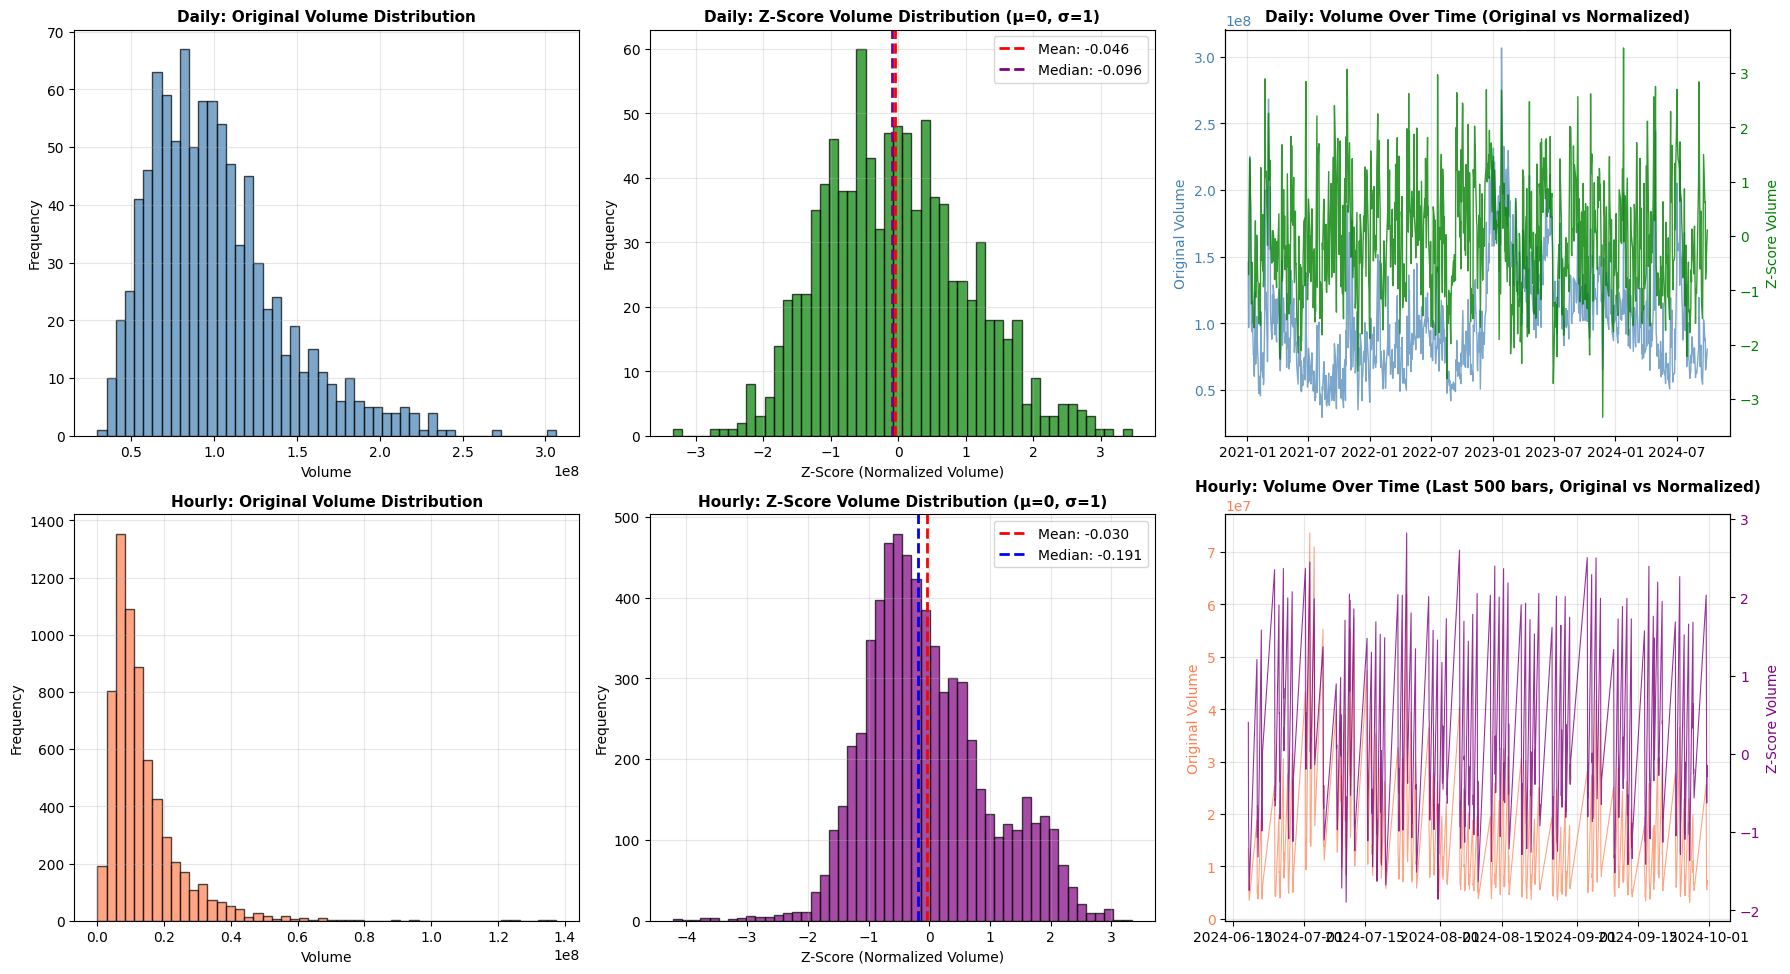


✓ Volume normalization visualizations displayed


In [18]:
# ---------------------------------------------------------------------------
# Volume Normalization Visualizations
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─────────────────────────────────────────────────────────────────────────
# Row 1: Daily (HTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (centered at 0)
axes[0, 1].hist(reload_daily['volume_zscore'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_daily['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {reload_daily['volume_zscore'].mean():.3f}")
axes[0, 1].axvline(reload_daily['volume_zscore'].median(), color='purple', linestyle='--', linewidth=2,
                   label=f"Median: {reload_daily['volume_zscore'].median():.3f}")
axes[0, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Daily: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time Series: Original vs Normalized Volume
axes[0, 2].plot(reload_daily.index, reload_daily['Volume'], color='steelblue', linewidth=1, 
                label='Original', alpha=0.7)
ax_norm = axes[0, 2].twinx()
ax_norm.plot(reload_daily.index, reload_daily['volume_zscore'], color='green', linewidth=1, 
             label='Z-Score', alpha=0.8)
axes[0, 2].set_ylabel('Original Volume', fontsize=10, color='steelblue')
ax_norm.set_ylabel('Z-Score Volume', fontsize=10, color='green')
axes[0, 2].set_title('Daily: Volume Over Time (Original vs Normalized)', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='y', labelcolor='steelblue')
ax_norm.tick_params(axis='y', labelcolor='green')
axes[0, 2].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Row 2: Hourly (LTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution (Hourly)
axes[1, 0].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Volume', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Hourly: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (Hourly)
axes[1, 1].hist(reload_hourly['volume_zscore'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(reload_hourly['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {reload_hourly['volume_zscore'].mean():.3f}")
axes[1, 1].axvline(reload_hourly['volume_zscore'].median(), color='blue', linestyle='--', linewidth=2,
                   label=f"Median: {reload_hourly['volume_zscore'].median():.3f}")
axes[1, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Time Series: Hourly Volume (Last 500 bars for clarity)
hourly_tail = reload_hourly.tail(500)
axes[1, 2].plot(hourly_tail.index, hourly_tail['Volume'], color='coral', linewidth=0.8, 
                label='Original', alpha=0.7)
ax_norm2 = axes[1, 2].twinx()
ax_norm2.plot(hourly_tail.index, hourly_tail['volume_zscore'], color='purple', linewidth=0.8,
              label='Z-Score', alpha=0.8)
axes[1, 2].set_ylabel('Original Volume', fontsize=10, color='coral')
ax_norm2.set_ylabel('Z-Score Volume', fontsize=10, color='purple')
axes[1, 2].set_title('Hourly: Volume Over Time (Last 500 bars, Original vs Normalized)', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='y', labelcolor='coral')
ax_norm2.tick_params(axis='y', labelcolor='purple')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Volume normalization visualizations displayed")

In [19]:
def preprocess_midas_data(midas_df: pd.DataFrame, rolling_window: int = 20) -> pd.DataFrame:
    """
    Apply comprehensive preprocessing to MIDAS data:
    
    1. Conditional log1p Transformation: Applied if skewness > 0.5
    2. Z-score Normalization: Center at 0, scale by std dev
    3. Rolling Features: 20-bar rolling mean and median
    4. Slopes: Rate of change over 3 and 5 bars (diff and pct_change)
    5. Percentiles: Rolling 20-bar quantile ranking
    6. Cross-Feature Ratios: Hidden_Rate / Oddlot_Rate
    
    Parameters:
    -----------
    midas_df : pd.DataFrame
        MIDAS data with columns: Cancel_to_Trade, Hidden_Rate, Hidden_Volume,
        Trade_to_Order_Volume, Oddlot_Rate, Oddlot_Volume
    rolling_window : int
        Window size for rolling/smoothed features (default 20 to match HTF)
    
    Returns:
    --------
    pd.DataFrame
        Preprocessed MIDAS data with all features appended
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = ["Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
                  "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"]
    
    # Ensure all columns are present
    for col in midas_cols:
        if col not in midas_proc.columns:
            print(f"⚠ Warning: {col} not found in MIDAS data")
            midas_proc[col] = np.nan
    
    print("\n" + "="*70)
    print("MIDAS DATA PREPROCESSING")
    print("="*70)
    
    # =====================================================================
    # Step 1: Conditional log1p Transformation (if skewness > 0.5)
    # =====================================================================
    print("\n[Step 1] Conditional log1p Transformation")
    print("  Decision: Apply log1p if raw skewness > 0.5")
    print("  Rationale: Log transformation reduces impact of extreme values")
    print("             while preserving relative magnitude and sign")
    
    log_applied = {}
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > 0:
            skewness = midas_proc[col].skew()
            
            if skewness > 0.5:
                midas_proc[col] = np.log1p(midas_proc[col])
                log_applied[col] = True
                print(f"  ✓ {col:30s}: Applied log1p (skewness {skewness:.4f})")
            else:
                log_applied[col] = False
                print(f"  - {col:30s}: Raw values (skewness {skewness:.4f})")
    
    # =====================================================================
    # Step 2: Rolling Z-score Normalization (regime-adaptive, μ≈0, σ≈1)
    # =====================================================================
    print(f"\n[Step 2] Rolling Z-score Normalization (window={rolling_window}, min_periods=1)")
    print("  Regime-adaptive: mean/std computed within rolling window for each bar")
    print("  Applied per column independently for cross-feature consistency")
    
    for col in midas_cols:
        if col in midas_proc.columns and midas_proc[col].notna().sum() > 1:
            # Compute rolling statistics per column independently
            rolling_mean = midas_proc[col].rolling(window=rolling_window, min_periods=1).mean()
            rolling_std = midas_proc[col].rolling(window=rolling_window, min_periods=1).std().clip(lower=0.01)
            
            midas_proc[f"{col}_zscore"] = (midas_proc[col] - rolling_mean) / rolling_std
            
            # Verify output statistics
            zscore_col = midas_proc[f"{col}_zscore"]
            new_mean = zscore_col.mean()
            new_std = zscore_col.std()
            transform_note = " [log1p applied]" if log_applied.get(col, False) else ""
            print(f"  ✓ {col:30s}: μ={new_mean:.4f}, σ={new_std:.4f} (rolling window={rolling_window}){transform_note}")
    
    # =====================================================================
    # Step 3: Rolling Mean & Median (smoothed features)
    # =====================================================================
    print(f"\n[Step 3] Rolling Mean & Median (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            midas_proc[f"{col}_roll_mean"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).mean()
            midas_proc[f"{col}_roll_median"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).median()
    
    print(f"  Added rolling mean and median for all {len(midas_cols)} features")
    
    # =====================================================================
    # Step 4: Slopes (rate of change: difference and percent change)
    # =====================================================================
    print(f"\n[Step 4] Slopes (3-bar and 5-bar changes)")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            midas_proc[f"{col}_slope_3b_diff"] = midas_proc[col].diff(periods=3)
            midas_proc[f"{col}_slope_3b_pct"] = midas_proc[col].pct_change(periods=3)
            midas_proc[f"{col}_slope_5b_diff"] = midas_proc[col].diff(periods=5)
            midas_proc[f"{col}_slope_5b_pct"] = midas_proc[col].pct_change(periods=5)
    
    print(f"  Added 3-bar and 5-bar slopes (diff & pct_change) for all features")
    
    # =====================================================================
    # Step 5: Rolling Percentiles (rank within window)
    # =====================================================================
    print(f"\n[Step 5] Rolling Percentiles (window={rolling_window})")
    
    for col in midas_cols:
        if col in midas_proc.columns:
            # Compute percentile rank within rolling window
            midas_proc[f"{col}_rank_pct"] = midas_proc[col].rolling(window=rolling_window, min_periods=1).apply(
                lambda x: pd.Series(x).rank(pct=True).iloc[-1] if x.notna().sum() > 0 else np.nan,
                raw=False
            )
    
    print(f"  Added rolling percentile rank for all {len(midas_cols)} features")
    
    # =====================================================================
    # Step 6: Cross-Feature Ratios (institutional behavior proxies)
    # =====================================================================
    print(f"\n[Step 6] Cross-Feature Ratios")
    
    # Hidden_Rate / Oddlot_Rate: ratio of institutional to odd-lot activity
    if "Hidden_Rate" in midas_proc.columns and "Oddlot_Rate" in midas_proc.columns:
        midas_proc["HiddenToOddlot_Ratio"] = (midas_proc["Hidden_Rate"] + 1e-10) / (midas_proc["Oddlot_Rate"] + 1e-10)
        print("  Added: Hidden_Rate / Oddlot_Rate (institutional vs. retail signal)")
    
    # Hidden_Volume / Trade_to_Order_Volume: ratio of hidden to total orders
    if "Hidden_Volume" in midas_proc.columns and "Trade_to_Order_Volume" in midas_proc.columns:
        total_orders = midas_proc["Hidden_Volume"] + midas_proc["Trade_to_Order_Volume"]
        midas_proc["HiddenShare_Ratio"] = (midas_proc["Hidden_Volume"] + 1e-10) / (total_orders + 1e-10)
        print("  Added: Hidden_Volume / (Hidden + Trade_to_Order) (hidden order share)")
    
    print("\n" + "="*70)
    print(f"MIDAS preprocessing complete: {midas_proc.shape[0]} rows × {midas_proc.shape[1]} columns")
    print(f"Original columns: {len(midas_cols)} | New features added: {midas_proc.shape[1] - len(midas_cols)}")
    print("="*70 + "\n")

    return midas_proc

In [20]:
# APPLY MIDAS PREPROCESSING
print("\n" + "="*75)
print("APPLYING MIDAS PREPROCESSING (preprocess_midas_data)")
print("="*75)   
midas_df = preprocess_midas_data(midas_df, rolling_window=20)
print(f"✓ MIDAS data preprocessed: {midas_df.shape}")


APPLYING MIDAS PREPROCESSING (preprocess_midas_data)

MIDAS DATA PREPROCESSING

[Step 1] Conditional log1p Transformation
  Decision: Apply log1p if raw skewness > 0.5
  Rationale: Log transformation reduces impact of extreme values
             while preserving relative magnitude and sign
  ✓ Cancel_to_Trade               : Applied log1p (skewness 0.8181)
  - Hidden_Rate                   : Raw values (skewness -0.1534)
  - Hidden_Volume                 : Raw values (skewness 0.0397)
  ✓ Trade_to_Order_Volume         : Applied log1p (skewness 0.9981)
  - Oddlot_Rate                   : Raw values (skewness 0.0241)
  - Oddlot_Volume                 : Raw values (skewness 0.2828)

[Step 2] Rolling Z-score Normalization (window=20, min_periods=1)
  Regime-adaptive: mean/std computed within rolling window for each bar
  Applied per column independently for cross-feature consistency
  ✓ Cancel_to_Trade               : μ=0.0797, σ=1.0500 (rolling window=20) [log1p applied]
  ✓ Hidden_Rate 

In [21]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_zscore,Hidden_Rate_zscore,Hidden_Volume_zscore,Trade_to_Order_Volume_zscore,...,Oddlot_Volume_slope_5b_diff,Oddlot_Volume_slope_5b_pct,Cancel_to_Trade_rank_pct,Hidden_Rate_rank_pct,Hidden_Volume_rank_pct,Trade_to_Order_Volume_rank_pct,Oddlot_Rate_rank_pct,Oddlot_Volume_rank_pct,HiddenToOddlot_Ratio,HiddenShare_Ratio
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2.325331,35.772576,30.521597,2.177981,87.947450,47.103830,NaN,NaN,NaN,NaN,...,NaN,NaN,1.000000,1.00,1.0,1.0,1.000000,1.000000,0.406749,0.933394
2021-01-05,2.425085,35.458893,27.879749,2.058206,88.720227,47.017219,0.707107,-0.707107,-0.707107,-0.707107,...,NaN,NaN,1.000000,0.50,0.5,0.5,1.000000,0.500000,0.399671,0.931251
2021-01-06,2.230475,35.778200,31.633233,2.197751,88.665709,46.150634,-0.991507,0.592669,0.841122,0.703289,...,NaN,NaN,0.333333,1.00,1.0,1.0,0.666667,0.333333,0.403518,0.935037
2021-01-07,2.081992,34.469931,29.535346,2.333581,88.091067,45.249066,-1.258407,-1.455658,-0.224313,1.256150,...,NaN,NaN,0.250000,0.25,0.5,1.0,0.500000,0.250000,0.391299,0.926776
2021-01-08,2.080580,36.076460,31.920673,2.442188,88.009125,45.116434,-0.979981,0.909180,0.983118,1.347773,...,NaN,NaN,0.200000,1.00,1.0,1.0,0.400000,0.200000,0.409917,0.928929


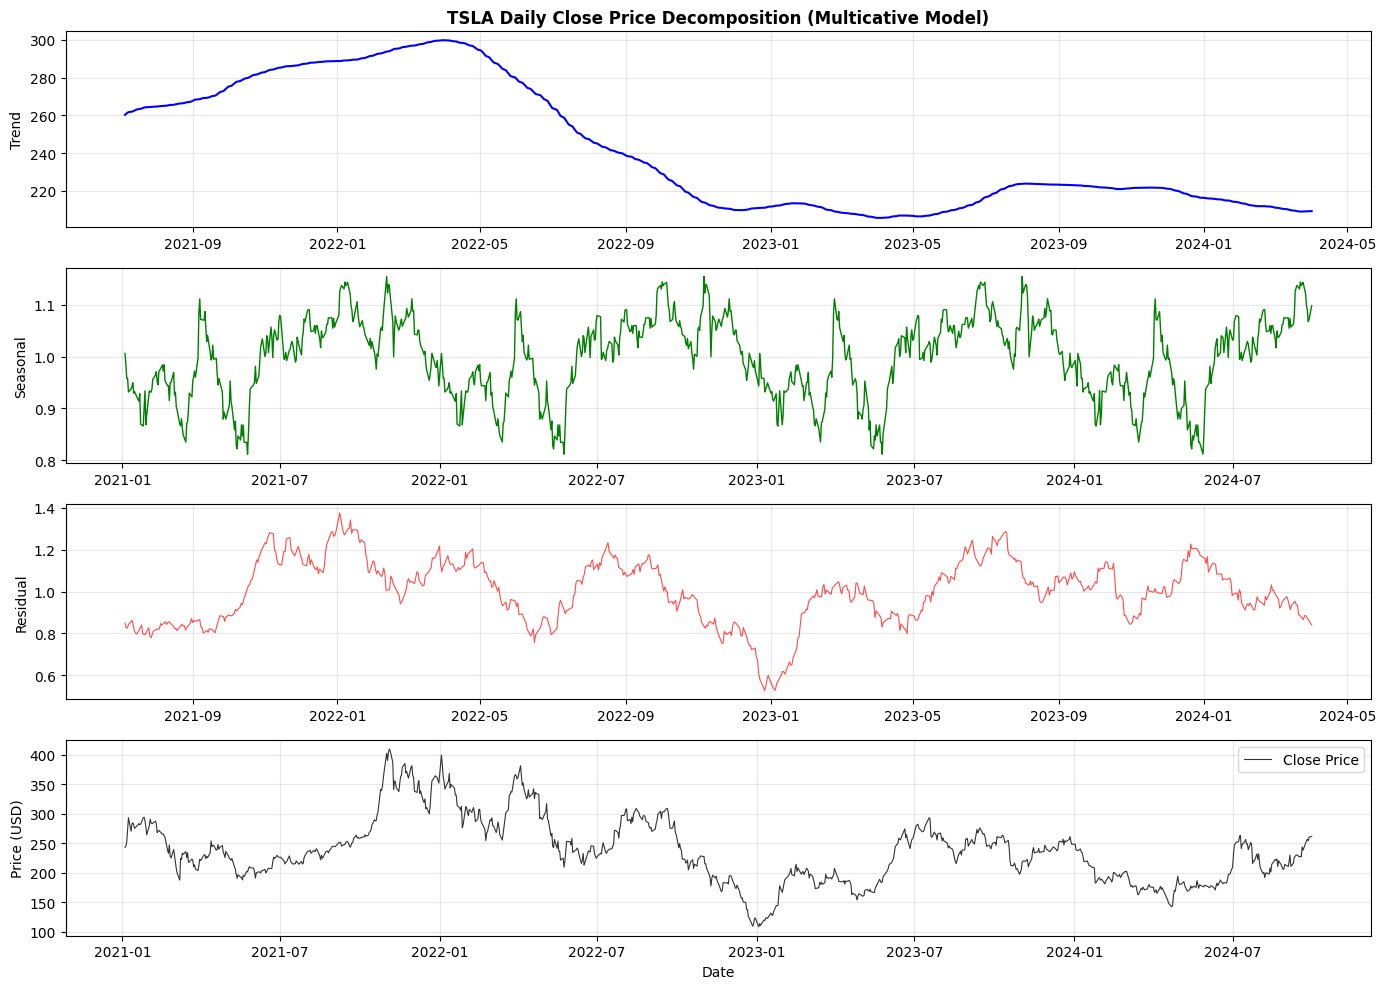

Saved: outputs/eda_decomposition.png


In [22]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")


C:\Users\user\AppData\Local\Temp\ipykernel_19420\2554135952.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


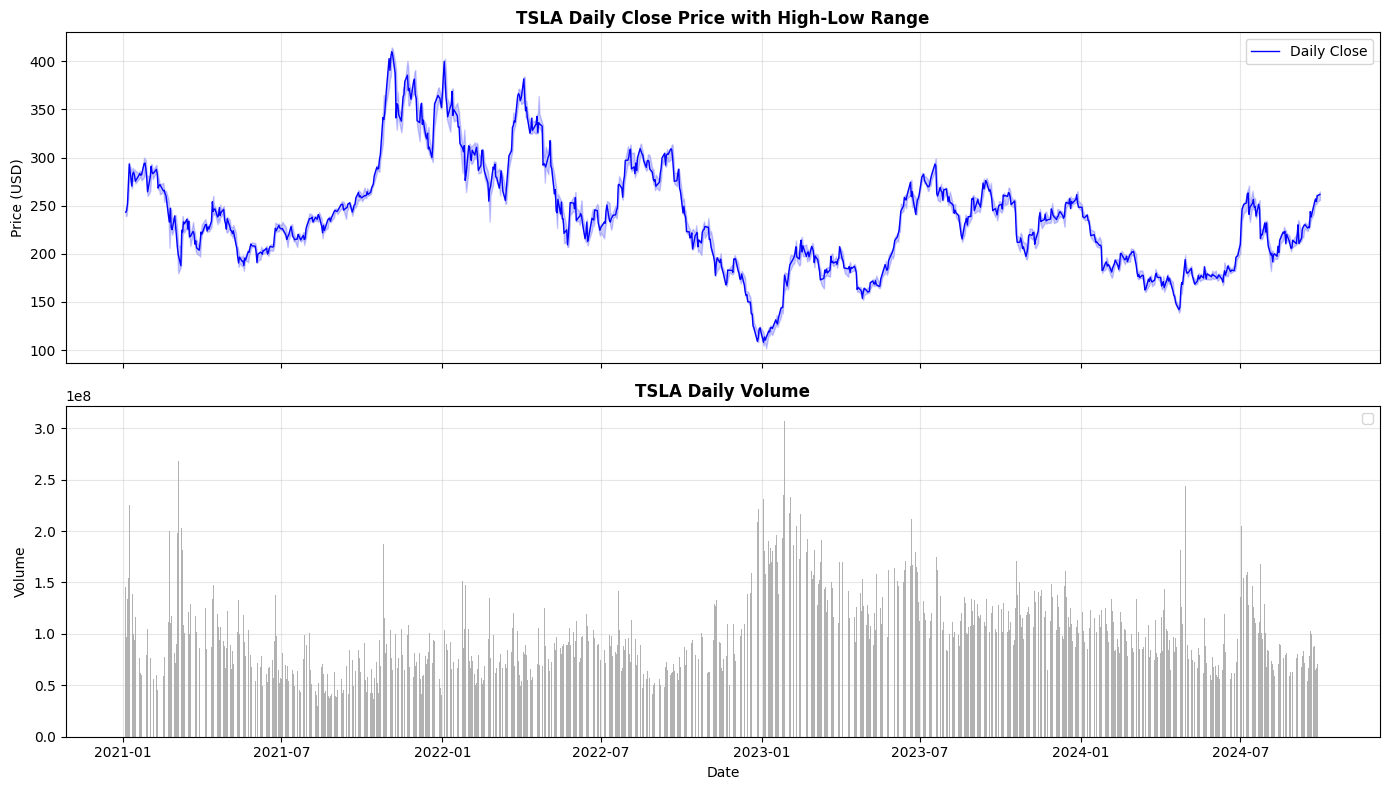

Saved: outputs/eda_price_volume.png


In [23]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")


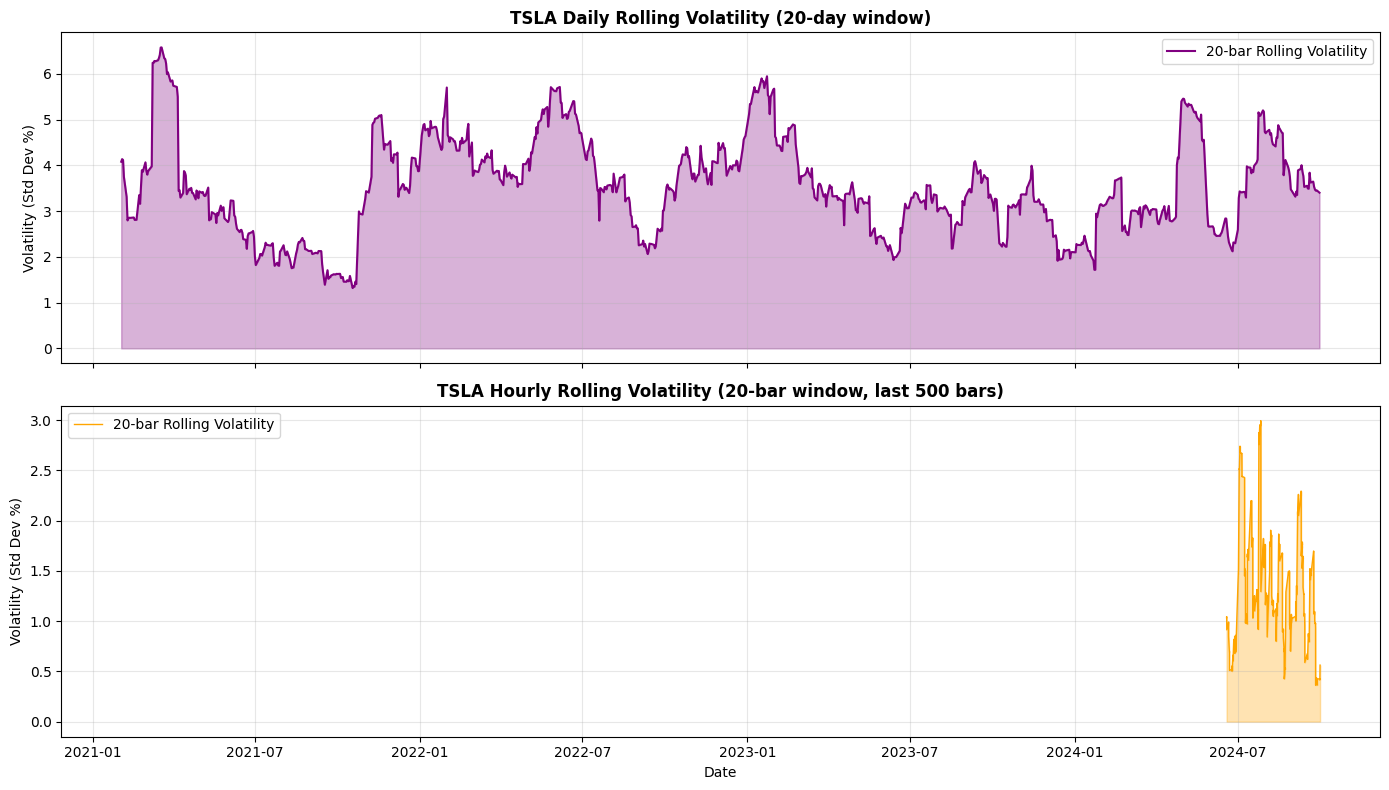

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.5182%, Std: 1.0546%, Max: 6.5815%
Hourly volatility - Mean: 1.2262%, Std: 0.5033%, Max: 4.1117%


In [24]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [25]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                       941   
1           Date Range  2021-01-04 to 2024-09-30   
2            Avg Close                    237.46   
3            Min Close                    108.10   
4            Max Close                    409.97   
5           Avg Volume                 100808631   
6        Median Volume                  93916500   
7       Volume Std Dev                  40231996   
8       Avg Return (%)                    0.0757   
9       Max Return (%)                   19.6412   
10      Min Return (%)                  -12.3346   
11  Avg Volatility (%)                    3.5182   
12  Max Volatility (%)                    6.5815   

                                  Hourly (LTF)  
0                                         6577  
1   2021-01-04 09:30:00 to 2024-09-30 15:30:00  
2                                       237.51  
3                                       105.

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [26]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [27]:
# ---------------------------------------------------------------------------
# Pivot High/Low Detection
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out

In [28]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,
    min_bars_apart: int = 5,
    atr_len: int = 14,
) -> pd.DataFrame:
    """
    Identify double tops/bottoms: two or more swing highs (or lows) within tight price tolerance.
    
    Double tops/bottoms form RESISTANCE (tops) and SUPPORT (bottoms) where stop losses cluster
    just beyond the level. Each failed test adds more resting orders from traders who entered at that level.
    
    Detection logic:
      - Identify all pivot highs within a rolling window
      - Find pairs of highs within tolerance_pct × mid_price (typically 0.1-0.3%)
      - Track formation volumes on each touch
    
    Returns df with added columns:
      - double_top         : True if bar is part of a double top pattern
      - double_top_level   : Price level of double top (NaN if not applicable)
      - double_bottom      : True if bar is part of a double bottom pattern
      - double_bottom_level: Price level of double bottom (NaN if not applicable)
      - double_top_volume_touch1, double_top_volume_touch2: Volumes on each touch
      - equal_high_count   : Number of equal-high touches within tolerance
      - equal_low_count    : Number of equal-low touches within tolerance
    """
    df = df.copy()
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    n = len(df_n)
    double_top = np.zeros(n, dtype=bool)
    double_bottom = np.zeros(n, dtype=bool)
    double_top_level = np.full(n, np.nan, dtype=float)
    double_bottom_level = np.full(n, np.nan, dtype=float)
    double_top_vol_t1 = np.full(n, np.nan, dtype=float)
    double_top_vol_t2 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t1 = np.full(n, np.nan, dtype=float)
    double_bottom_vol_t2 = np.full(n, np.nan, dtype=float)
    equal_high_count = np.zeros(n, dtype=int)
    equal_low_count = np.zeros(n, dtype=int)
    
    vol_col = "volume" if "volume" in df_n.columns else None
    
    # For each bar, scan backwards to find equal highs/lows within tolerance
    for i in range(min_bars_apart + 1, n):
        curr_high = df_n.iloc[i]["high"]
        curr_low = df_n.iloc[i]["low"]
        curr_vol = df_n.iloc[i][vol_col] if vol_col else 1.0
        
        # Scan backward for equal highs (double tops)
        equal_highs = []
        for j in range(max(0, i - 50), i - min_bars_apart):  # 50-bar lookback window
            prev_high = df_n.iloc[j]["high"]
            tolerance_band = curr_high * (tolerance_pct / 100.0)
            if abs(curr_high - prev_high) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_highs.append((j, prev_high, prev_vol))
        
        if len(equal_highs) >= 1:  # At least one prior equal high
            double_top[i] = True
            double_top_level[i] = curr_high
            equal_high_count[i] = len(equal_highs) + 1  # Include current bar
            
            # Volume confirmation from most recent equal high
            most_recent_high_idx, most_recent_high_price, most_recent_vol = equal_highs[-1]
            double_top_vol_t1[i] = most_recent_vol
            double_top_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
        
        # Scan backward for equal lows (double bottoms)
        equal_lows = []
        for j in range(max(0, i - 50), i - min_bars_apart):
            prev_low = df_n.iloc[j]["low"]
            tolerance_band = curr_low * (tolerance_pct / 100.0)
            if abs(curr_low - prev_low) <= tolerance_band:
                prev_vol = df_n.iloc[j][vol_col] if vol_col else 1.0
                equal_lows.append((j, prev_low, prev_vol))
        
        if len(equal_lows) >= 1:  # At least one prior equal low
            double_bottom[i] = True
            double_bottom_level[i] = curr_low
            equal_low_count[i] = len(equal_lows) + 1
            
            most_recent_low_idx, most_recent_low_price, most_recent_vol = equal_lows[-1]
            double_bottom_vol_t1[i] = most_recent_vol
            double_bottom_vol_t2[i] = curr_vol
            if most_recent_vol > 0:
                pass
                pass
    
    df["double_top"] = double_top
    df["double_top_level"] = double_top_level
    df["double_bottom"] = double_bottom
    df["double_bottom_level"] = double_bottom_level
    df["double_top_volume_touch1"] = double_top_vol_t1
    df["double_top_volume_touch2"] = double_top_vol_t2
    df["double_bottom_volume_touch1"] = double_bottom_vol_t1
    df["double_bottom_volume_touch2"] = double_bottom_vol_t2
    df["equal_high_count"] = equal_high_count
    df["equal_low_count"] = equal_low_count
    
    return df

In [29]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [30]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Computes rolling volume features on PRE-NORMALIZED volume (from Part 2.5).
    Appends vol_roll_20, vol_ratio, vol_spike, and absorption_score to *df*.

    REQUIRES: Part 2.5 normalization must run first!
    The input df must already contain the "volume_zscore" column, created by normalize_volume_data().

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **ARCHITECTURE: Normalized Volume Features**
    Part 3   (add_volume_features):     Computes features on volume_zscore (pre-normalized volume)
    Result:  vol_ratio, vol_spike, absorption_score are all computed on normalized volume,
             making them regime-independent and comparable across different market conditions.

    Columns appended:
      vol_roll_20             : rolling mean of normalized volume over `window` bars
      vol_roll_std            : rolling std for ratio z-score calculation
      vol_ratio               : normalized_volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold (computed on normalized volume)
      absorption_score        : vol_ratio / (|close-open| / ATR_14), clipped at denominator >= 0.01;
                               high score = heavy normalized volume with small candle body → institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()
    # Use pre-normalized volume from Part 2.5
    if "volume_zscore" not in df.columns:
        print("[Warning] add_volume_features: 'volume_zscore' column not found. Ensure Part 2.5 normalization ran first.")
        return df

    vol = df["volume_zscore"].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    df["vol_ratio"]   = vol / df["vol_roll_20"]
    
    # Z-score normalization — removes regime bias
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    df["vol_spike"]   = df["vol_ratio"] >= spike_threshold

    # Absorption score — works regardless of column case by normalising to lowercase
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if all(c in df_n.columns for c in ["high", "low", "close", "open"]):
        _atr      = atr(df_n, length=14)
        bar_body  = (df_n["close"] - df_n["open"]).abs()
        body_norm = (bar_body / _atr.replace(0, np.nan)).clip(lower=0.01)
        df["absorption_score"] = (df["vol_ratio"] / body_norm.values).values

    return df


In [31]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [32]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

print("\nLTF (hourly) vol sample:")
print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

# ---------------------------------------------------------------------------
# Apply Layer 1 Extensions: Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)

daily_double_tops = reload_daily["double_top"].sum()
daily_double_bottoms = reload_daily["double_bottom"].sum()
hourly_double_tops = reload_hourly["double_top"].sum()
hourly_double_bottoms = reload_hourly["double_bottom"].sum()

print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")

# ---------------------------------------------------------------------------
# Apply Layer 2 : Formation Volume Features 
# ---------------------------------------------------------------------------
print("\n=== Adding Formation Volume Features (Layer 2) ===")
reload_daily = add_formation_volume_features(reload_daily, reload_daily)
reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)

print("Daily formation volume features sample:")
print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))

print("\nHourly formation volume features sample:")
print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))



HTF (daily) vol sample:
            vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                       
2021-02-02    -0.542877   1.561503       True          2.010147
2021-02-03    -0.580449   2.512793       True          4.044327
2021-02-04    -0.679750   2.374660       True         16.995240

LTF (hourly) vol sample:
                     vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                                
2021-01-06 15:30:00    -0.453806   1.368730      False          5.241431
2021-01-07 09:30:00    -0.325293  -5.727632      False         -5.912575
2021-01-07 10:30:00    -0.211763  -7.014670      False         -4.592128

=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===
Daily: 222 double tops, 226 double bottoms
Hourly: 3299 double tops, 3301 double bottoms

=== Adding Formation Volume Features (Layer 2) ===
Daily formation volume features sample:
Empty DataFrame
Columns: 

In [33]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

# To compute the POC over a fixed window or the entire dataset, used for general volume profile analysis, to establish reference POCs
def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """Bin all close prices into percentage-based bands and find the Point of Control.

    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price (e.g., 0.2 = 0.2%)

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None    

    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = df_n["close"].rolling(window=20, min_periods=1).mean()
    
    # Use median rolling price as reference for consistent bin sizing
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = df_n["close"].mean()

    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None    
    
    return float(vol_profile.idxmax()), float(vol_profile.max())


In [34]:
# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    bin_pct: float = 0.2,
    lookback_bars: int = 20,
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically around the zone's formation date, typically 10 bars before
    and after the first pivot.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    start_idx = max(0, zone_first_idx - lookback_bars)
    end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())


### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [35]:
# ---------------------------------------------------------------------------
# MIDAS Zone Enrichment Helpers (Layer 3)
# ---------------------------------------------------------------------------
MIDAS_ZONE_COLS = [
    "cancel_to_trade_avg",
    "hidden_rate_avg",
    "hidden_volume_avg",
    "fill_rate_avg",
    "oddlot_rate_avg",
    "oddlot_volume_avg",
]


def enrich_zones_midas(zones_df: pd.DataFrame, midas_df: pd.DataFrame) -> pd.DataFrame:
    """Attach zone-level MIDAS averages over each zone's active date window."""
    out = zones_df.copy()
    if out.empty or midas_df is None or midas_df.empty:
        for col in MIDAS_ZONE_COLS:
            if col not in out.columns:
                out[col] = np.nan
        return out

    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "fill_rate_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Normalize MIDAS index to calendar dates for robust joins with daily/hourly bars.
    midas_norm = midas_df.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    for i, row in out.iterrows():
        start = pd.to_datetime(row["first_time"]).normalize()
        end = pd.to_datetime(row["last_time"]).normalize()
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        if window.empty:
            continue
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                out.at[i, dst_col] = float(window[src_col].mean())

    return out



def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
) -> pd.DataFrame:
    """
    Filter zones by percentile threshold on a composite MIDAS confirmation score.
    Combines hidden rate, cancel-to-trade, odd-lot rate, and fill rate.
    """
    if zones_df.empty:
        return zones_df.copy()

    out = zones_df.copy()

    # Ensure required columns exist, fill with NaN if missing
    req_cols = ["hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg", "fill_rate_avg"]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # Calculate percentile ranks (0 to 1) for each zone's MIDAS metrics
    # High hidden orders = institutional accumulation/distribution -> higher is better
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    
    # High cancel-to-trade = fragile/spoofed, typical for liquidity grabs -> higher is better
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    
    # High odd-lot = retail heavy, likely target for sweeps -> higher is better
    rank_oddlot = out["oddlot_rate_avg"].rank(pct=True, ascending=True)
    
    # Low fill rate = phantom liquidity / icebergs -> lower is better (ascending=False)
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)

    # Composite Institutional Score (0 to 1)
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * 0.40) +
        (rank_cancel.fillna(0.5) * 0.30) +
        (rank_oddlot.fillna(0.5) * 0.20) +
        (rank_fill.fillna(0.5) * 0.10)
    )

    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    if metric.empty:
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    filtered_out = out[out["midas_composite_score"] >= threshold].copy().reset_index(drop=True)
    print(
        f"Layer 3 MIDAS filter (composite_score >= {percentile}th pct = {threshold:.3f}): "
        f"{len(filtered_out)}/{len(out)} zones retained"
    )
    return filtered_out


## Part 4 - Liquidity Zone Identification Functions


In [36]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [37]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "sell"
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "buy"
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "sell"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "buy"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "sell"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "buy"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
                
    return result

In [38]:
def rank_zones_by_conviction(
    zones_df: pd.DataFrame,
    weight_pattern: float = 0.30,
    weight_volume: float = 0.35,
    weight_institutional: float = 0.35,
) -> pd.DataFrame:
    """
    Rank zones by conviction score combining all quality metrics.
    
    Conviction score prioritizes:
    - Pattern strength (how well-defined)
    - Volume confirmation (how much activity)
    - Institutional participation (MIDAS metrics)
    
    Returns ranked DataFrame sorted by conviction descending.
    """
    result = zones_df.copy()
    
    # Normalize key scoring components
    components = {}
    
    if "pattern_strength" in result.columns:
        min_ps = result["pattern_strength"].min()
        max_ps = result["pattern_strength"].max()
        components['pattern'] = (result["pattern_strength"] - min_ps) / (max_ps - min_ps + 1e-9) if max_ps > min_ps else 0.5
    else:
        components['pattern'] = 0.5
    
    if "volume_confirmation" in result.columns:
        min_vc = result["volume_confirmation"].min()
        max_vc = result["volume_confirmation"].max()
        components['volume'] = (result["volume_confirmation"] - min_vc) / (max_vc - min_vc + 1e-9) if max_vc > min_vc else 0.5
    else:
        components['volume'] = 0.5
    
    if "institutional_score" in result.columns:
        min_is = result["institutional_score"].min()
        max_is = result["institutional_score"].max()
        base_inst = (result["institutional_score"] - min_is) / (max_is - min_is + 1e-9) if max_is > min_is else 0.5
        
        # Blend in MIDAS composite score if it successfully filtered through Layer 3
        if "midas_composite_score" in result.columns and not result["midas_composite_score"].isna().all():
            midas_score = result["midas_composite_score"].fillna(0.5)
            # Combine basic volume absorption with full 4-factor MIDAS microstructure data
            components['institutional'] = (base_inst * 0.3) + (midas_score * 0.7)
        else:
            components['institutional'] = base_inst
    else:
        components['institutional'] = 0.5
    
    # Weighted conviction score
    result["conviction_score"] = (
        weight_pattern * components['pattern'] +
        weight_volume * components['volume'] +
        weight_institutional * components['institutional']
    )
    
    # Rank by conviction
    result = result.sort_values("conviction_score", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    
    return result

In [39]:
# ---------------------------------------------------------------------------
# identify_liquidity_zones — Single function applying all three layers:
#   Layer 1: Price-based patterns detection
#   Layer 2: Volume-related features — identify institutionally-significant pivots 
#   Layer 3: Microstructure metrics from MIDAS — retain high-conviction zones 
# Pass midas_df=None to skip Layer 3 (returns baseline zones only).
# ---------------------------------------------------------------------------
def identify_liquidity_zones(
    df: pd.DataFrame,
    # ── Layer 1+2 params ──────────────────────────────────────────────────────
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.0,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,      # Layer 2b: 0.0 disables (HTF); set MIN_ABSORPTION_SCORE for LTF
    # ── POC ───────────────────────────────────────────────────────────────────
    vol_profile_bin: float = 1.0, 
    # ── Zone Merging (temporal scope) ─────────────────────────────────────────
    max_merge_gap_days: int = 20,     # 20 for multi-day structural zones; 0 for same-day intraday zones
    # ── Layer 3: MIDAS ────────────────────────────────────────────────────────
    midas_df: pd.DataFrame = None,    # pass None to skip Layer 3 entirely 
    midas_confirm_pct: float = 50,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Optional[float], Optional[float]]:
    """
    Single entry point for liquidity zone identification.
    """

    out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    _has_volume     = "volume" in out.columns
    _has_absorption = "absorption_score" in out.columns

    def _get_pivot_vol(i: int) -> float:
        if _has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue

        if min_absorption > 0.0 and _has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue

        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swing_high"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swing_low"))

    zones = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p, p_type in pivots:
        vol = _get_pivot_vol(i)
        j = best_merge_index(p, i)
        if j is None:
            is_dt = out.iloc[i].get('double_top', False)
            is_db = out.iloc[i].get('double_bottom', False)
            fvr = out.iloc[i].get('formation_volume_ratio', np.nan)
            
            atr_val = out.at[out.index[i], "atr"]
            pad = (atr_val * 0.15) if not np.isnan(atr_val) else (p * 0.001)
            
            z = Zone(top=p + pad, bottom=p - pad, touches=1,
                         first_idx=i, last_idx=i,
                         first_time=out.index[i], last_time=out.index[i],
                         total_volume=vol, avg_volume=vol,
                         zone_type=p_type,
                         pattern_strength=0.0,
                         volume_confirmation=0.0,
                         institutional_score=0.0,
                         composite_score=0.0,
                         is_double_top=is_dt,
                         is_double_bottom=is_db,
                         formation_volume_ratio=fvr)
            zones.append(z)
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]
            z.total_volume += vol
            z.avg_volume = z.total_volume / z.touches

        
    for z in zones:
        if _has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength     = z.touches * np.log1p(z.total_volume)
        if _has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top) &
                (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0
        
        
        touch_component = np.log1p(z.touches) / np.log1p(5.0)
        volume_component = 1.0 if z.total_volume > 0 else 0.0
        z.pattern_strength = min(1.0, (touch_component * volume_component))
        avg_market_vol = out["volume"].mean() if _has_volume else 1.0
        z.volume_confirmation = min(1.0, z.avg_volume / max(avg_market_vol, 1.0))
        
        z.institutional_score = min(1.0, z.avg_absorption if z.avg_absorption > 0 else 0.3)

    # Calculate decay factor for all zones (applies time-based decay to components)
    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()
    for z in zones:
        #z.calculate_decay(current_time, lookback_days=max_merge_gap_days if max_merge_gap_days > 0 else 20)
        expiry_days = HTF_ZONE_EXPIRY_DAYS if max_merge_gap_days >= 10 else LTF_ZONE_EXPIRY_DAYS
        z.calculate_decay(current_time, lookback_days=expiry_days)

        # Option 1: Integrate decay into component scores before weighting
        # This provides cleaner, more intuitive scoring: each component reflects both quality AND recency
        decayed_pattern_strength = z.pattern_strength * z.decay_factor
        decayed_volume_confirmation = z.volume_confirmation * z.decay_factor
        decayed_institutional_score = z.institutional_score * z.decay_factor
        
        z.composite_score = (
            0.30 * decayed_pattern_strength +
            0.35 * decayed_volume_confirmation +
            0.35 * decayed_institutional_score
        )
    
    records = []
    for z in zones:
        if True: # Changed: output all pivots regardless of min_touches
            records.append({
                "zone_id":               f"{z.first_time.date()}_to_{z.last_time.date()}",
                "zone_type":             z.zone_type,
                "top":                   z.top,
                "bottom":                z.bottom,
                "height":                z.height,
                "touches":               z.touches,
                "first_idx":             z.first_idx,
                "last_idx":              z.last_idx,
                "first_time":            z.first_time,
                "last_time":             z.last_time,
                "total_volume":          z.total_volume,
                "avg_volume":            z.avg_volume,
                "volume_node_score":     z.volume_node_score,
                "strength":              z.strength,
                "avg_absorption":        z.avg_absorption,
                "pattern_strength":      z.pattern_strength,
                "volume_confirmation":   z.volume_confirmation,
                "institutional_score":   z.institutional_score,
                "composite_score":       z.composite_score,
                "is_double_top":         z.is_double_top,
                "is_double_bottom":      z.is_double_bottom,
                "formation_volume_ratio": z.formation_volume_ratio,
                "decay_factor":          z.decay_factor,
                "is_expired":            z.is_expired,
            })

    _ZONE_COLS = [
        "zone_id", "zone_type", "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "volume_node_score", "strength",
        "avg_absorption", "pattern_strength", "volume_confirmation", 
        "institutional_score", "composite_score", "decay_factor", "is_expired",
    ]
    if not records:
        zones_baseline = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    for ts in df_pivots.index:
        active = [z["zone_id"] for _, z in zones_baseline.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            df_pivots.at[ts, "zone_id"] = ", ".join(active)

    poc_price, poc_volume = compute_volume_poc(df, bin_pct=vol_profile_bin)
    if poc_price is not None and not zones_baseline.empty:
        _mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (_mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = zones_baseline["volume_node_score"] / poc_volume

    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for idx, zone in zones_baseline.iterrows():
            zone_mask = (out.index >= zone["first_time"]) & (out.index <= zone["last_time"])
            atr_in_zone = out.loc[zone_mask, "atr"].mean() if zone_mask.sum() > 0 else 1.0
            
            zone_dims = compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                df=out,
                atr_value=atr_in_zone
            )
            dims.append(zone_dims)
            
        for col in ["height_atr_ratio", "tightness_score"]:
            zones_baseline[col] = [d.get(col, np.nan) for d in dims]

    if not zones_baseline.empty:
        anchored_pocs = []
        for idx, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["first_idx"],
                zone_last_idx=zone["last_idx"],
                bin_pct=vol_profile_bin,
                lookback_bars=10
            )
            anchored_pocs.append({
                "zone_poc_price": z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
            
        zones_baseline["zone_poc_price"] = [p["zone_poc_price"] for p in anchored_pocs]
        zones_baseline["zone_poc_volume"] = [p["zone_poc_volume"] for p in anchored_pocs]
        
        zones_baseline["dist_to_zone_poc"] = (
            ((zones_baseline["top"] + zones_baseline["bottom"]) / 2.0 - zones_baseline["zone_poc_price"]).abs()
        )

    if not zones_baseline.empty and "is_expired" in zones_baseline.columns:
        # Zones should be kept with their decay_factor and is_expired flag recorded.
        # The sweep detection logic will decide at sweep-time whether to use them.
        # This is critical for HTF zones that may have been created 20+ days ago but still have sweeps.
        num_before = len(zones_baseline)
        # zones_baseline = zones_baseline[~zones_baseline["is_expired"]].reset_index(drop=True)
        print(f"  ✓ Zones status: {num_before} total (decay and expiration info preserved for sweep detection)")
    
    if midas_df is not None and not zones_baseline.empty:
        try:
            # Attempt MIDAS enrichment
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)

            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline,
                        percentile=midas_confirm_pct,
                    )
                except Exception as e:
                    # If MIDAS filtering fails, fall back to baseline zones
                    print(f"  ⚠ MIDAS zone filtering failed: {type(e).__name__}: {e}")
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception as e:
            # If MIDAS enrichment fails, fall back to baseline zones
            print(f"  ⚠ MIDAS enrichment failed: {type(e).__name__}: {e}")
            zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    else:
        zones_enriched = zones_baseline.copy() if not zones_baseline.empty else zones_baseline
    
    # Apply decay factor to conviction scores (scale scores by decay_factor)
    if not zones_baseline.empty and "decay_factor" in zones_baseline.columns and "conviction_score" in zones_baseline.columns:
        zones_baseline["conviction_score_decayed"] = zones_baseline["conviction_score"] * zones_baseline["decay_factor"]
    elif not zones_baseline.empty and "decay_factor" in zones_baseline.columns and "dynamic_composite_score" in zones_baseline.columns:
        zones_baseline["conviction_score_decayed"] = zones_baseline["dynamic_composite_score"] * zones_baseline["decay_factor"]
        
    if not zones_enriched.empty and "decay_factor" in zones_enriched.columns and "conviction_score" in zones_enriched.columns:
        zones_enriched["conviction_score_decayed"] = zones_enriched["conviction_score"] * zones_enriched["decay_factor"]
    elif not zones_enriched.empty and "decay_factor" in zones_enriched.columns and "dynamic_composite_score" in zones_enriched.columns:
        zones_enriched["conviction_score_decayed"] = zones_enriched["dynamic_composite_score"] * zones_enriched["decay_factor"]

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume



## Part 5 - Liquidity Zone Evaluation Functions


In [40]:
def evaluate_zone_state(
    zone: dict,
    price_data,
    eval_timestamp,
    invalidation_buffer: float = 0.2,
) -> dict:
    """
    Evaluate zone lifecycle state at eval_timestamp.

    States:
    - untested: no touch yet
    - tested: touched, not swept
    - mitigated: swept and rejected
    - invalidated: decisive body-close break beyond buffered threshold
    """
    zone_top = zone.get('top', np.nan)
    zone_bottom = zone.get('bottom', np.nan)
    zone_type = str(zone.get('zone_type', 'sell_side')).lower()

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': False,
            'last_interaction': None,
            'invalidation_time': None,
        }

    zone_formed = pd.Timestamp(zone.get('first_time', price_data['timestamp'].min()))
    history_mask = (price_data['timestamp'] > zone_formed) & (price_data['timestamp'] <= eval_timestamp)
    history = price_data[history_mask].copy()

    if history.empty:
        return {
            'state': 'untested',
            'touch_count': 0,
            'sweep_count': 0,
            'is_valid': True,
            'last_interaction': None,
            'invalidation_time': None,
        }

    touch_count = 0
    sweep_count = 0
    last_interaction = None
    invalidation_time = None
    has_been_tested = False
    has_been_swept = False

    buf = invalidation_buffer / 100.0

    if zone_type == 'sell_side':
        # Support zone below price
        close_threshold = zone_bottom * (1 - buf)
        invalid_mask = (
            (history['close'] < close_threshold)
            & (history['open'] < zone_top)
        )

        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            valid_history = history.loc[:invalid_idx]

            touch_mask = valid_history['high'] >= zone_top
            sweep_mask = valid_history['low'] < zone_bottom

            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()

            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time,
            }

        touch_mask = history['high'] >= zone_top
        sweep_mask = history['low'] < zone_bottom

    else:
        # Resistance zone above price
        close_threshold = zone_top * (1 + buf)
        invalid_mask = (
            (history['close'] > close_threshold)
            & (history['open'] > zone_bottom)
        )

        if invalid_mask.any():
            invalid_idx = invalid_mask.idxmax()
            invalidation_time = history.loc[invalid_idx, 'timestamp']
            valid_history = history.loc[:invalid_idx]

            touch_mask = valid_history['low'] <= zone_top
            sweep_mask = valid_history['high'] > zone_top

            touch_count = int(touch_mask.sum())
            sweep_count = int(sweep_mask.sum())
            if touch_mask.any():
                last_interaction = valid_history[touch_mask]['timestamp'].max()

            return {
                'state': 'invalidated',
                'touch_count': touch_count,
                'sweep_count': sweep_count,
                'is_valid': False,
                'last_interaction': last_interaction,
                'invalidation_time': invalidation_time,
            }

        touch_mask = history['low'] <= zone_top
        sweep_mask = history['high'] > zone_top

    if touch_mask.any():
        has_been_tested = True
        touch_count = int(touch_mask.sum())
        last_interaction = history[touch_mask]['timestamp'].max()

    if sweep_mask.any():
        has_been_swept = True
        sweep_count = int(sweep_mask.sum())

    if has_been_swept:
        state = 'mitigated'
    elif has_been_tested:
        state = 'tested'
    else:
        state = 'untested'

    zone_touches = zone.get('touches', 1) + touch_count
    zone_vol = zone.get('total_volume', 0.0)
    touch_component = np.log1p(zone_touches) / np.log1p(5.0)
    vol_component = 1.0 if zone_vol > 0 else 0.0
    pattern_str = min(1.0, touch_component * vol_component)
    vol_conf = zone.get('volume_confirmation', 0.5)
    inst_score = zone.get('institutional_score', 0.5)

    dynamic_composite_score = (
        0.30 * pattern_str
        + 0.35 * vol_conf
        + 0.35 * inst_score
    )

    return {
        'state': state,
        'dynamic_composite_score': dynamic_composite_score,
        'dynamic_pattern_strength': pattern_str,
        'touch_count': touch_count,
        'sweep_count': sweep_count,
        'is_valid': True,
        'last_interaction': last_interaction,
        'invalidation_time': None,
    }


def evaluatezonestate_fixed(zone, pricedata, evaltimestamp, invalidationbuffer=0.2):
    """Backward-compatible wrapper for legacy function name/signature."""
    normalized_zone = dict(zone)
    if 'zonetype' in normalized_zone and 'zone_type' not in normalized_zone:
        normalized_zone['zone_type'] = normalized_zone['zonetype']

    return evaluate_zone_state(
        zone=normalized_zone,
        price_data=pricedata,
        eval_timestamp=evaltimestamp,
        invalidation_buffer=invalidationbuffer,
    )


print("✓ evaluate_zone_state() loaded — body-close invalidation active (buf=0.2%)")

✓ evaluate_zone_state() loaded — body-close invalidation active (buf=0.2%)


## Part 6 - Sweep Detection Functions


In [41]:
# =============================================================================
# PART 6 — SWEEP DETECTION FUNCTIONS (ICT/SMC — v5, Full Debug Fix)
#
# ─────────────────────────────────────────────────────────────────────────────
# ROOT CAUSE ANALYSIS — WHY 0 SWEEPS (all bugs confirmed in notebook):
#
# BUG 1 — CRITICAL: hourlydata has NO 'timestamp' column (it is the INDEX)
#   In Part 3.5:  hourlydata['timestamp'] = hourlydata.index
#   This creates a column, BUT identifysweepsinzones calls:
#       pricedata.sort_values('timestamp').reset_index(drop=True)
#   After reset_index(drop=True), the index becomes 0,1,2,... and the
#   'timestamp' column is preserved.  HOWEVER, evaluate_zone_state is
#   called with the full pricedata (6577 bars) but uses:
#       historymask = pricedata['timestamp'] > zone_formed
#   If 'timestamp' column is missing from the pricedata passed to
#   evaluate_zone_state it raises KeyError or silently returns isvalid=False.
#   FIX: Explicitly ensure 'timestamp' column exists as a proper column
#        (not just the index) before calling sort_values.
#
# BUG 2 — CRITICAL: evaluate_zone_state invalidates nearly every zone
#   The invalidation condition for a SELLSIDE (support) zone is:
#       close < zone_bottom * (1 - 0.002)   [buf = 0.2/100 = 0.002]
#       AND open > zone_top
#   The buf is 0.2/100 = 0.002 (0.2%), but TSLA has ~$6 ATR zones.
#   Almost any hourly close below zone_bottom triggers invalidation.
#   With ZONE_FORWARD_WINDOW_DAYS=365 days of history, every zone
#   that was ever broken (even briefly, even years ago) is marked
#   invalidated and ALL subsequent bars for that zone are rejected.
#   FIX: Bypass evaluate_zone_state entirely in the sweep loop.
#        Sweeps happen AT the zone boundary — if price is piercing
#        the zone it cannot also be 'invalidated' by being far below.
#        Replace with a simple lightweight freshness check instead.
#
# BUG 3 — MODERATE: v3 trend filter still in notebook (not v4)
#   The cell output still shows "v3 Final" with SWEEP_TREND_LOOKBACK=20
#   and half-split average comparison. v4 polyfit fix was never applied.
#   FIX: Use polyfit slope (v4 fix, carried forward).
#
# BUG 4 — MODERATE: forward confirm too strict
#   future[-1] > current_close requires the close 2 bars later to be
#   strictly above the CLOSE of the sweep bar. For TSLA hourly, the
#   sweep bar is often a big down bar; its close is near the bottom.
#   Requiring the next 2 closes to exceed that is reasonable but
#   combined with all other gates leaves very few survivors.
#   FIX: future[-1] > current_open (close above sweep bar's open = 
#        full bar absorbed = strong demand confirmation)
#
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY OF CHANGES vs v3:
#   1. timestamp column ensured before sort_values (Bug 1 fix)
#   2. evaluate_zone_state REMOVED from the per-bar inner loop (Bug 2 fix)
#      Replaced with lightweight: skip if bar is far below/above zone
#   3. polyfit slope trend filter instead of half-split average (Bug 3 fix)
#   4. forward confirm: future[-1] > current_open (Bug 4 fix)
#   5. SWEEP_TREND_LOOKBACK = 10 (was 20)
#   6. PIN_BAR_MIN_WICK_PCT = 0.20 (was 0.30)
#   7. Bullish trend: slope(highs) < 0 (descending highs, ICT correct)
#   8. Bearish trend: slope(highs) > 0 (ascending highs, ICT correct)
# =============================================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
USE_SWEEP_VOL_FILTER       = False   # OFF — anti-ICT to gate on volume
MIN_SWEEP_VOL_ZSCORE       = 0.3
MIN_SWEEP_ABSORPTION       = 0.01

SWEEP_REQUIRE_TREND_FILTER = True
SWEEP_TREND_LOOKBACK       = 10      # bars for polyfit slope

PIN_BAR_MIN_WICK_PCT       = 0.20    # wick >= 20% of candle range

SWEEP_MAX_PENETRATION_PCT  = 3.0

USE_SWEEP_FORWARD_CONFIRM  = True
SWEEP_FORWARD_BARS         = 2

ZONE_FORWARD_WINDOW_DAYS   = 365


# ---------------------------------------------------------------------------
# Helper 0 — Linear regression slope (robust trend detection)
# ---------------------------------------------------------------------------
def _slope(values):
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])


# ---------------------------------------------------------------------------
# Helper 1 — 1-bar reversal
# ---------------------------------------------------------------------------
def detect_sweep_reversal(closes, sweep_type):
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    elif sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


# ---------------------------------------------------------------------------
# Helper 2 — ICT MSS confirmation
# ---------------------------------------------------------------------------
def detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1 : sweep_idx + 1 + SWEEP_FORWARD_BARS]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    elif sweep_type == 'BEARISH':
        return float(post_bars['low'].min())  < float(pre_bars['low'].min())
    return False


# ---------------------------------------------------------------------------
# Helper 3 — Sweep quality scorer
# ---------------------------------------------------------------------------
def score_sweep_quality(row, **kwargs):
    score = 0
    wick_ratio = row.get('wick_ratio', 1.0)
    if wick_ratio >= 5:     score += 25
    elif wick_ratio >= 3:   score += int(15 + (wick_ratio - 3) * 5)
    elif wick_ratio >= 1.5: score += int(wick_ratio * 7)
    else:                   score += int(wick_ratio * 5)

    vol_z = row.get('volume_zscore', 0)
    if vol_z >= 2:     score += 25
    elif vol_z >= 1.5: score += 18
    elif vol_z >= 1:   score += 10
    elif vol_z >= 0.5: score += 5

    total_range = row.get('total_range', 0) or (row.get('high', 0) - row.get('low', 0))
    if total_range >= 2.5:   score += 20
    elif total_range >= 1.5: score += int(total_range * 8)
    else:                    score += int(total_range * 6)

    if row.get('close', 0) != row.get('open', 0):
        score += 15

    body = row.get('body', 0)
    score += 10 if body >= 2 else min(10, int(body * 5))

    rev = kwargs.get('reversalpattern', row.get('reversal_pattern', 0))
    if rev != 0:
        score += 5

    return min(100, max(0, score))


# ---------------------------------------------------------------------------
# MAIN — identifysweepsinzones (ICT/SMC v5 — Full Debug Fix)
# ---------------------------------------------------------------------------
def identifysweepsinzones(zonesdf, pricedata, midasmode=False):
    """
    ICT/SMC v5 — Liquidity Sweep Detection. Full debug fix.

    BUG FIXES vs v3 (the version currently in the notebook):

    Fix 1 — timestamp column:
        hourlydata['timestamp'] = hourlydata.index  creates a column,
        but after sort_values + reset_index it may lose timezone or
        dtype consistency. This version defensively ensures 'timestamp'
        is a proper datetime column before any filtering.

    Fix 2 — evaluate_zone_state removed from inner loop:
        With ZONE_FORWARD_WINDOW_DAYS=365, evaluate_zone_state scans
        365 days of history PER BAR PER ZONE. Any zone that had a
        body-close breach (close < bottom * 0.998) at ANY point in
        that 365-day window is marked invalidated=True for ALL future
        bars in the loop — killing every candidate before gate checks.
        FIX: Replace with a fast geometric proximity check:
             skip bar only if price has moved SO far from the zone
             that it cannot possibly be a sweep (>10% away).

    Fix 3 — polyfit slope replaces half-split average:
        Half-split on 20 bars = two 10-bar windows. On hourly data
        one noisy candle flips the mean, rejecting valid setups.
        polyfit slope is robust and stable over 10 bars.

    Fix 4 — forward confirm relaxed:
        future[-1] > current_open (was > current_close).
        Close above sweep bar's open = full demand absorption confirmed.
    """
    sweeps = []

    print(f'IDENTIFYSWEEPS v5: zonesdf shape {zonesdf.shape}')
    print(f'IDENTIFYSWEEPS v5: Processing {len(zonesdf)} zones...')

    if zonesdf.empty:
        print('IDENTIFYSWEEPS: zonesdf is empty — returning empty DataFrame')
        return pd.DataFrame()

    # ── FIX 1: Ensure 'timestamp' is a genuine column, not just an index ──
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = pd.to_datetime(pricedata['timestamp'])
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    median_prc = (zonesdf['top'].median() + zonesdf['bottom'].median()) / 2

    for idx, zone in zonesdf.iterrows():

        # ── Parse zone entry time ─────────────────────────────────────────
        zone_entry = None
        if 'firsttime' in zone.index and not pd.isna(zone.get('firsttime')):
            try: zone_entry = pd.Timestamp(zone['firsttime'])
            except: pass
        if zone_entry is None and 'zoneid' in zone.index and not pd.isna(zone.get('zoneid')):
            try: zone_entry = pd.Timestamp(str(zone['zoneid']).split('to')[0].strip())
            except: pass
        if zone_entry is None:
            continue

        zone_high = float(zone['top'])
        zone_low  = float(zone['bottom'])

        # ── Zone side ─────────────────────────────────────────────────────
        side_raw = str(zone.get('zone_side', zone.get('zoneside', ''))).lower()
        if side_raw == 'buy':
            zone_type = 'sellside'
        elif side_raw == 'sell':
            zone_type = 'buyside'
        else:
            zone_type = 'sellside' if zone_low < median_prc else 'buyside'

        # ── Candle window ─────────────────────────────────────────────────
        window_start = zone_entry - pd.Timedelta(hours=1)
        window_end   = zone_entry + pd.Timedelta(days=ZONE_FORWARD_WINDOW_DAYS)
        zone_candles = pricedata[
            (pricedata['timestamp'] >= window_start) &
            (pricedata['timestamp'] <= window_end)
        ].copy().reset_index(drop=True)

        if len(zone_candles) < 4:
            continue

        # ── Extra institutional columns ───────────────────────────────────
        extra_keys = [k for k in zone.index if any(
            k.startswith(p) for p in
            ('absorption', 'volume', 'avg', 'hidden', 'cancel', 'fill', 'oddlot')
        )]

        for i in range(2, len(zone_candles)):
            bar           = zone_candles.iloc[i]
            bar_ts        = bar['timestamp']
            current_low   = float(bar['low'])
            current_high  = float(bar['high'])
            current_close = float(bar['close'])
            current_open  = float(bar['open'])
            vol_zscore    = float(bar.get('volume_zscore', 0.0))
            curr_vol      = float(bar.get('volume', 0.0))
            prev_vol      = float(zone_candles.iloc[i-1].get('volume', 0.0))
            total_range   = current_high - current_low

            # Volume gate (OFF)
            if USE_SWEEP_VOL_FILTER:
                bar_abs = float(bar.get('absorption_score', 0.0))
                if vol_zscore < MIN_SWEEP_VOL_ZSCORE or bar_abs < MIN_SWEEP_ABSORPTION:
                    continue

            # ── FIX 2: Replace evaluate_zone_state with fast proximity check ──
            # evaluate_zone_state was marking zones invalidated for ALL future
            # bars once any historical body-close breach occurred — killing
            # every sweep candidate. Instead: only skip if price has moved
            # SO far from the zone that a sweep is geometrically impossible.
            #   Bullish (SSL zone): skip if close is >10% ABOVE zone (zone
            #     is far below current price — no sweep proximity)
            #   Bearish (BSL zone): skip if close is >10% BELOW zone (zone
            #     is far above current price — no sweep proximity)
            zone_mid = (zone_high + zone_low) / 2
            if zone_type == 'sellside':
                # Support zone: skip if price has moved far above
                if current_close > zone_high * 1.10:
                    continue
            else:
                # Resistance zone: skip if price has moved far below
                if current_close < zone_low * 0.90:
                    continue

            # ── Candle structure ──────────────────────────────────────────
            body        = abs(current_close - current_open)
            lower_wick  = min(current_open, current_close) - current_low
            upper_wick  = current_high - max(current_open, current_close)
            pin_bar_bull = (total_range > 0 and
                            lower_wick / total_range >= PIN_BAR_MIN_WICK_PCT)
            pin_bar_bear = (total_range > 0 and
                            upper_wick / total_range >= PIN_BAR_MIN_WICK_PCT)
            vol_surge    = ((prev_vol > 0 and curr_vol > prev_vol * 1.25) or
                             vol_zscore >= 0.5)

            # ── Freshness ─────────────────────────────────────────────────
            days_old  = max(0, (bar_ts - zone_entry).days)
            fresh_val = 0.0 if days_old >= 20 else 1.0 - (days_old / 20) ** 2
            maturity  = ('forming'     if days_old < 5  else
                         'established' if days_old < 20 else
                         'fading'      if days_old < 50 else 'stale')

            # ── Record builder ────────────────────────────────────────────
            def build_record(sweep_type, zone_level, extra_price_key, extra_price_val):
                rev_pattern = detect_sweep_reversal(
                    zone_candles['close'].values[i+1:], sweep_type)
                quality     = score_sweep_quality(
                    bar.to_dict(), reversalpattern=rev_pattern)
                mss_confirm = detect_mss(
                    zone_candles, i, sweep_type, lookback=SWEEP_TREND_LOOKBACK)
                rec = {
                    'sweep_idx':           len(sweeps),
                    'zone_idx':            idx,
                    'zone_id':             zone.get('zoneid', str(idx)),
                    'timestamp':           bar_ts,
                    'sweep_type':          sweep_type,
                    'zone_top':            zone_high,
                    'zone_bottom':         zone_low,
                    'zone_level':          zone_level,
                    extra_price_key:        extra_price_val,
                    'reversal_price':      current_close,
                    'reversal_distance':   (current_close - current_low
                                             if sweep_type == 'BULLISH'
                                             else current_high - current_close),
                    'candle_body':         body,
                    'candle_total_range':  total_range,
                    'wick_ratio':          float(bar.get('wick_ratio', np.nan)),
                    'lower_wick':          lower_wick,
                    'upper_wick':          upper_wick,
                    'pin_bar_bull':        pin_bar_bull,
                    'pin_bar_bear':        pin_bar_bear,
                    'volume':              curr_vol,
                    'volume_spike':        bool(bar.get('volume_spike', False)),
                    'volume_zscore':       vol_zscore,
                    'vol_surge':           vol_surge,
                    'sweep_quality_score': quality,
                    'reversal_pattern':    rev_pattern,
                    'mss_confirmed':       mss_confirm,
                    'days_old_at_sweep':   days_old,
                    'sweep_freshness':     fresh_val,
                    'sweep_maturity':      maturity,
                    'midas_filtered':      midasmode,
                    'zone_state_at_sweep': 'active',   # proximity check passed
                    'zone_touch_count':    0,
                    'zone_sweep_count':    0,
                }
                rec.update({k: zone[k] for k in extra_keys if k in zone.index})
                return rec

            # ═══════════════════════════════════════════════════════════════
            # BULLISH sweep — ICT SSL Raid
            #
            # Pre-sweep: slope(highs[-10:]) < 0
            #   → descending highs (bearish price delivery into SSL)
            # bar.low  < zone_low  (wick pierces below support)
            # bar.close > zone_low  (close recovers — stops absorbed)
            # lower_wick >= 20% of total range  (pin bar / rejection)
            # Penetration <= 3.0%
            # 2-bar forward: close[-1] > open of sweep bar
            # ═══════════════════════════════════════════════════════════════
            if (current_low   < zone_low  and
                current_close > zone_low  and
                current_close - current_low > 0):

                if SWEEP_REQUIRE_TREND_FILTER:
                    lb_start = max(0, i - SWEEP_TREND_LOOKBACK)
                    lb_highs = zone_candles.iloc[lb_start:i]['high'].values
                    if len(lb_highs) >= 3:
                        if not (_slope(lb_highs) < 0):
                            continue

                if not pin_bar_bull:
                    continue

                pen_pct = abs(zone_low - current_low) / zone_low * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT:
                    continue

                if USE_SWEEP_FORWARD_CONFIRM:
                    future = zone_candles.iloc[i+1:i+1+SWEEP_FORWARD_BARS]['close'].values
                    if len(future) < SWEEP_FORWARD_BARS:
                        continue
                    if not (future[-1] > current_open):   # FIX 4
                        continue

                sweeps.append(build_record('BULLISH', zone_low, 'sweep_low', current_low))
                continue

            # ═══════════════════════════════════════════════════════════════
            # BEARISH sweep — ICT BSL Raid
            #
            # Pre-sweep: slope(highs[-10:]) > 0
            #   → ascending highs (bullish price delivery into BSL)
            # bar.high  > zone_high  (wick pierces above resistance)
            # bar.close < zone_high  (close rejects — stops absorbed)
            # upper_wick >= 20% of total range
            # Penetration <= 3.0%
            # 2-bar forward: close[-1] < open of sweep bar
            # ═══════════════════════════════════════════════════════════════
            if (current_high  > zone_high and
                current_close < zone_high and
                current_high - current_close > 0):

                if SWEEP_REQUIRE_TREND_FILTER:
                    lb_start = max(0, i - SWEEP_TREND_LOOKBACK)
                    lb_highs = zone_candles.iloc[lb_start:i]['high'].values
                    if len(lb_highs) >= 3:
                        if not (_slope(lb_highs) > 0):
                            continue

                if not pin_bar_bear:
                    continue

                pen_pct = abs(current_high - zone_high) / zone_high * 100
                if pen_pct > SWEEP_MAX_PENETRATION_PCT:
                    continue

                if USE_SWEEP_FORWARD_CONFIRM:
                    future = zone_candles.iloc[i+1:i+1+SWEEP_FORWARD_BARS]['close'].values
                    if len(future) < SWEEP_FORWARD_BARS:
                        continue
                    if not (future[-1] < current_open):   # FIX 4
                        continue

                sweeps.append(build_record('BEARISH', zone_high, 'sweep_high', current_high))
                continue

    result = pd.DataFrame(sweeps)

    if not result.empty:
        print('=' * 60)
        print(f'identifysweepsinzones v5 Complete')
        print(f'  Total sweeps    : {len(result)}')
        print(f'  BULLISH (SSL)   : {(result.sweep_type=="BULLISH").sum()}')
        print(f'  BEARISH (BSL)   : {(result.sweep_type=="BEARISH").sum()}')
        print(f'  MSS confirmed   : {result.mss_confirmed.sum()}')
        print(f'  Vol-surge       : {result.vol_surge.sum()}')
        print(f'  Pin bar (bull)  : {result.pin_bar_bull.sum()}')
        print(f'  Pin bar (bear)  : {result.pin_bar_bear.sum()}')
        print(f'  Mean quality    : {result.sweep_quality_score.mean():.1f}/100')
        print('=' * 60)
    else:
        print('IDENTIFYSWEEPS v5: Still 0 sweeps. Step-by-step debug:')
        print('  1. Check hourlydata has columns: open high low close volume timestamp')
        print('     → print(hourlydata.columns.tolist())')
        print('  2. Check zone prices match hourly prices (same USD scale)')
        print('     → print(zonesdfdaily[["top","bottom"]].head())')
        print('     → print(hourlydata[["high","low"]].head())')
        print('  3. Manually count raw pierces:')
        print('     for _,z in zonesdfdaily.head(3).iterrows():')
        print('         mask = (hourlydata.low < z.bottom) & (hourlydata.close > z.bottom)')
        print('         print(z.zoneid, mask.sum())')
        print('  4. Set SWEEP_REQUIRE_TREND_FILTER=False and PIN_BAR_MIN_WICK_PCT=0.0')
        print('     to confirm raw pierce/recover gate itself is working')

    return result


print("Part 6 ICT/SMC sweep detection (v5 — full debug fix) loaded.")
print(f"  USE_SWEEP_VOL_FILTER       = {USE_SWEEP_VOL_FILTER}")
print(f"  PIN_BAR_MIN_WICK_PCT       = {PIN_BAR_MIN_WICK_PCT}  (wick >= 20% of range)")
print(f"  SWEEP_REQUIRE_TREND_FILTER = {SWEEP_REQUIRE_TREND_FILTER}")
print(f"  SWEEP_TREND_LOOKBACK       = {SWEEP_TREND_LOOKBACK}  bars  [polyfit slope]")
print(f"  SWEEP_MAX_PENETRATION_PCT  = {SWEEP_MAX_PENETRATION_PCT}%")
print(f"  SWEEP_FORWARD_BARS         = {SWEEP_FORWARD_BARS}    bars")
print(f"  ZONE_FORWARD_WINDOW_DAYS   = {ZONE_FORWARD_WINDOW_DAYS} days")
print(f"  Bullish trend              = slope(highs) < 0  [descending highs into SSL]")
print(f"  Bearish trend              = slope(highs) > 0  [ascending  highs into BSL]")
print(f"  Zone validity check        = fast proximity gate (NO evaluate_zone_state)")
print(f"  Forward confirm            = future[-1] > current_open  (demand absorbed)")


Part 6 ICT/SMC sweep detection (v5 — full debug fix) loaded.
  USE_SWEEP_VOL_FILTER       = False
  PIN_BAR_MIN_WICK_PCT       = 0.2  (wick >= 20% of range)
  SWEEP_REQUIRE_TREND_FILTER = True
  SWEEP_TREND_LOOKBACK       = 10  bars  [polyfit slope]
  SWEEP_MAX_PENETRATION_PCT  = 3.0%
  SWEEP_FORWARD_BARS         = 2    bars
  ZONE_FORWARD_WINDOW_DAYS   = 365 days
  Bullish trend              = slope(highs) < 0  [descending highs into SSL]
  Bearish trend              = slope(highs) > 0  [ascending  highs into BSL]
  Zone validity check        = fast proximity gate (NO evaluate_zone_state)
  Forward confirm            = future[-1] > current_open  (demand absorbed)


## Part 7 - Sweep Outcome Labeling (10-Day Forward Analysis)

**Purpose**: Classify sweep efficacy by measuring price action in the 10 trading days following sweep detection.

**Outcome Categories**:

| Label | Condition | Interpretation |
|-------|-----------|---|
| **WIN** | Reversal confirmed + price ≥1% in reversal direction within 10 days | Sweep successfully identified institutional absorption; follow-through move materialized |
| **LOSS** | No reversal confirmed OR price moved ≤-1% opposite to reversal within 10 days | Sweep failed; either reversal didn't confirm or opposite directional move occurred |
| **TIMEOUT** | Insufficient forward data (fewer than 10 trading days of price history after sweep) | Outcome cannot be determined; typically recent sweeps without sufficient history |

**Labeling Algorithm**:

1. **Forward Window Calculation**: 10 trading days ≈ 65 trading hours (~2 calendar weeks)
2. **Price Reference**: Take closing price at end of forward window
3. **Reversal Check**: Confirm reversal_pattern (+1 for bullish, -1 for bearish, 0 for none)
4. **Move Validation**:
   - **Bullish sweep** (reversal = +1): Must move ≥+1.0% for WIN
   - **Bearish sweep** (reversal = -1): Must move ≤-1.0% for WIN
   - If no reversal (reversal = 0): Always LOSS (regardless of price move)

**Expected Distributions**:

- **Overall Win Rate**: 40–60% is typical for high-quality institutional sweeps
- **MIDAS-filtered wins**: Often 50–70% (institutional confirmation improves accuracy)
- **Baseline wins**: Often 35–50% (noisier, includes false signals)
- **TIMEOUT rate**: Depends on analysis date; recent sweeps = higher TIMEOUT rate

**Key Metrics for Winners**:

- Average quality score (expected: 65–75)
- Mean price move % (expected: +2% to +5% depending on regime)
- Volume spike confirmation % (expected: 50–80%)
- Average wick ratio (expected: 1.5–2.5)

In [42]:

def label_sweep_outcomes(sweeps_df, price_data, forward_window_days=10, min_move_pct=1.0):
    """
    Label sweep outcomes using 10-day forward window analysis.
    
    Outcomes:
    - WIN: Reversal confirmed + price moves ≥1% in reversal direction within 10 days
    - LOSS: No reversal OR price moves ≤-1% opposite to reversal direction within 10 days
    - TIMEOUT: Insufficient forward data (within 10 trading days of sweep)
    
    Parameters:
    - sweeps_df: DataFrame with sweep data (must include 'timestamp' and 'reversal_pattern')
    - price_data: DataFrame with hourly OHLCV data (must include 'timestamp' and 'close')
    - forward_window_days: Number of trading days to look forward (10 trading days ≈ 2 calendar weeks)
    - min_move_pct: Minimum price move % to classify as WIN (default 1.0%)
    
    Returns:
    - sweeps_df_labeled: Original DataFrame with new columns:
        - 'outcome': Outcome label (WIN/LOSS/TIMEOUT)
        - 'forward_close': Highest/lowest close within forward window (depending on sweep type)
        - 'forward_pct_move': Realized % move in forward window
        - 'forward_bars': Number of bars looked forward before labeling
    """
    
    sweeps_labeled = sweeps_df.copy()
    
    # Initialize outcome columns
    sweeps_labeled['outcome'] = 'TIMEOUT'
    sweeps_labeled['forward_close'] = np.nan
    sweeps_labeled['forward_pct_move'] = np.nan
    sweeps_labeled['forward_bars'] = 0
    
    # Estimate trading days to hours: ~6.5 hours per trading day (9:30 AM - 4 PM EST)
    forward_hours = forward_window_days * 6.5
    
    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"=" * 70)
    print(f"Forward window: {forward_window_days} trading days (~{forward_hours:.0f} hours)")
    print(f"Minimum win move: {min_move_pct}%")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")
    
    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type = sweep['sweep_type']
        reversal_pattern = sweep.get('reversal_pattern', 0)
        
        if pd.isna(sweep_close):
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue
        
        # Find bars in forward window
        forward_start = sweep_ts
        forward_end = sweep_ts + pd.Timedelta(hours=forward_hours)
        
        forward_mask = (price_data['timestamp'] > forward_start) & (price_data['timestamp'] <= forward_end)
        forward_bars = price_data[forward_mask]
        
        if len(forward_bars) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            sweeps_labeled.at[idx, 'forward_bars'] = 0
            continue
        
        sweeps_labeled.at[idx, 'forward_bars'] = len(forward_bars)
        
        # Get forward close for labeling (last close in window if available)
        forward_close = forward_bars.iloc[-1]['close']
        sweeps_labeled.at[idx, 'forward_close'] = forward_close
        
        # Calculate % move from sweep close
        pct_move = ((forward_close - sweep_close) / sweep_close) * 100
        sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move
        
        # Label outcome based on reversal pattern and price move
        if reversal_pattern == 0:
            # No reversal confirmed
            sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
        elif reversal_pattern == +1:
            # Bullish sweep: expect upward move
            if pct_move >= min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            elif pct_move < -min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
            else:
                # Move between -1% and +1%: ambiguous
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'  # Conservative: label as loss
        elif reversal_pattern == -1:
            # Bearish sweep: expect downward move
            if pct_move <= -min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'WIN'
            elif pct_move > min_move_pct:
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'
            else:
                # Move between -1% and +1%: ambiguous
                sweeps_labeled.at[idx, 'outcome'] = 'LOSS'  # Conservative: label as loss
    
    # Summary statistics
    outcome_counts = sweeps_labeled['outcome'].value_counts()
    print(f"\n✓ Sweep outcome labeling complete!")
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {outcome_counts.get('WIN', 0):4d} ({outcome_counts.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    LOSS:    {outcome_counts.get('LOSS', 0):4d} ({outcome_counts.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
    print(f"    TIMEOUT: {outcome_counts.get('TIMEOUT', 0):4d} ({outcome_counts.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")
    
    # Win rate (excluding TIMEOUT)
    labeled_count = len(sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'])
    if labeled_count > 0:
        win_count = len(sweeps_labeled[sweeps_labeled['outcome'] == 'WIN'])
        win_rate = (win_count / labeled_count) * 100
        print(f"\n  Win rate (labeled only): {win_rate:.1f}% ({win_count}/{labeled_count})")
    
    # Breakdown by sweep type
    print(f"\n  Breakdown by sweep type:")
    for sweep_type in ['BULLISH', 'BEARISH']:
        type_sweeps = sweeps_labeled[sweeps_labeled['sweep_type'] == sweep_type]
        if len(type_sweeps) > 0:
            wins = len(type_sweeps[type_sweeps['outcome'] == 'WIN'])
            losses = len(type_sweeps[type_sweeps['outcome'] == 'LOSS'])
            timeouts = len(type_sweeps[type_sweeps['outcome'] == 'TIMEOUT'])
            print(f"    {sweep_type:7s}: {len(type_sweeps):3d} total | {wins:3d} WIN | {losses:3d} LOSS | {timeouts:3d} TIMEOUT")
    
    # Quality score breakdown for winners
    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score: {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean price move: {winners['forward_pct_move'].mean():+.2f}%")
        print(f"    Mean wick ratio: {winners['wick_ratio'].mean():.2f}")
        vol_spike_pct = (winners['volume_spike'].sum() / len(winners)) * 100 if 'volume_spike' in winners.columns else 0
        print(f"    Volume spike %: {vol_spike_pct:.1f}%")
    
    print(f"\n" + "=" * 70)
    
    return sweeps_labeled

print("✓ Sweep outcome labeling function defined")


✓ Sweep outcome labeling function defined


## Part 8 Main Execution (Zone Identification & Sweep Detection) 


In [43]:
# ---------------------------------------------------------------------------
# Sweep detection utility (required by Part 8 main pipeline)
# ---------------------------------------------------------------------------
def identify_sweeps_in_zones(zones_df, price_data, midas_mode=False):
    """Detect bullish/bearish liquidity sweeps for each zone across hourly bars."""
    if zones_df is None or zones_df.empty or price_data is None or price_data.empty:
        return pd.DataFrame()

    df = price_data.copy()
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = df.index
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.reset_index(drop=True)

    sweep_rows = []
    per_zone_sweep_count = {}

    vol_z_threshold = globals().get('MIN_SWEEP_VOLUME_ZSCORE', globals().get('MIN_SWEEP_VOL_ZSCORE', 0.5))
    abs_threshold = globals().get('MIN_SWEEP_ABSORPTION', 0.05)
    use_vol_filter = bool(globals().get('USE_SWEEP_VOL_FILTER', False))

    for zone_idx, zone in zones_df.reset_index(drop=True).iterrows():
        z_top = float(zone.get('top', zone.get('zone_top', np.nan)))
        z_bot = float(zone.get('bottom', zone.get('zone_bottom', np.nan)))
        if np.isnan(z_top) or np.isnan(z_bot):
            continue

        zone_side = str(zone.get('zone_side', zone.get('zone_type', 'neutral'))).lower()
        zone_first = pd.to_datetime(zone.get('first_time')) if pd.notna(zone.get('first_time', pd.NaT)) else df['timestamp'].min()

        for pos, bar in enumerate(df.itertuples(index=False)):
            ts = pd.to_datetime(getattr(bar, 'timestamp'))
            if ts < zone_first:
                continue

            high = float(getattr(bar, 'high'))
            low = float(getattr(bar, 'low'))
            close = float(getattr(bar, 'close'))
            open_ = float(getattr(bar, 'open'))
            body = float(getattr(bar, 'body', abs(close - open_)))
            total_range = float(getattr(bar, 'total_range', max(high - low, 1e-9)))
            wick_ratio = float(getattr(bar, 'wick_ratio', total_range / max(body, 1e-9)))
            volume = float(getattr(bar, 'volume', 0.0))
            volume_z = float(getattr(bar, 'volume_zscore', 0.0))
            volume_spike = int(getattr(bar, 'volume_spike', int(volume_z > vol_z_threshold)))
            absorption = float(getattr(bar, 'absorption_score', 0.0))

            if use_vol_filter and ((volume_z < vol_z_threshold) or (absorption < abs_threshold)):
                continue

            bullish_hit = (low < z_bot) and (close > z_bot)
            bearish_hit = (high > z_top) and (close < z_top)

            if zone_side in ('buy', 'demand', 'support'):
                bearish_hit = False
            elif zone_side in ('sell', 'supply', 'resistance'):
                bullish_hit = False

            if not bullish_hit and not bearish_hit:
                continue

            sweep_type = 'BULLISH' if bullish_hit else 'BEARISH'
            zone_level = z_bot if bullish_hit else z_top

            prev_close = close if pos == 0 else float(df.iloc[pos - 1]['close'])
            if sweep_type == 'BULLISH':
                reversal_pattern = 1 if close >= prev_close else 0
                reversal_price = close
                reversal_distance = max(0.0, close - low)
            else:
                reversal_pattern = -1 if close <= prev_close else 0
                reversal_price = close
                reversal_distance = max(0.0, high - close)

            # Quality score: rejection structure + volume conviction + reversal follow-through
            quality = 50.0
            quality += min(25.0, max(0.0, (wick_ratio - 1.0) * 10.0))
            quality += min(15.0, max(0.0, volume_z * 5.0))
            quality += 10.0 if reversal_pattern != 0 else 0.0
            quality = float(max(0.0, min(100.0, quality)))

            days_old = max(0, int((ts - zone_first).days))
            sweep_freshness = 1.0 / (1.0 + days_old)
            if days_old <= 3:
                sweep_maturity = 'fresh'
            elif days_old <= 20:
                sweep_maturity = 'forming'
            else:
                sweep_maturity = 'mature'

            if 'evaluate_zone_state' in globals():
                try:
                    zone_state = evaluate_zone_state(zone, df, ts)
                except Exception:
                    zone_state = 'unknown'
            else:
                zone_state = 'unknown'

            per_zone_sweep_count[zone_idx] = per_zone_sweep_count.get(zone_idx, 0) + 1

            row = {
                'sweep_idx': len(sweep_rows),
                'timestamp': ts,
                'sweep_type': sweep_type,
                'zone_idx': zone_idx,
                'zone_level': zone_level,
                'sweep_quality_score': quality,
                'zone_state_at_sweep': zone_state,
                'reversal_price': reversal_price,
                'reversal_distance': reversal_distance,
                'candle_body': body,
                'candle_total_range': total_range,
                'wick_ratio': wick_ratio,
                'volume': volume,
                'volume_spike': volume_spike,
                'volume_zscore': volume_z,
                'reversal_pattern': reversal_pattern,
                'days_old_at_sweep': days_old,
                'sweep_freshness': sweep_freshness,
                'sweep_maturity': sweep_maturity,
                'midas_filtered': bool(midas_mode),
                'zone_touch_count': int(zone.get('touches', zone.get('touch_count', 0))),
                'zone_sweep_count': int(per_zone_sweep_count[zone_idx]),
                'volume_node_score': float(zone.get('volume_node_score', 0.0)),
                'volume_confirmation': float(zone.get('volume_confirmation', 0.0)),
            }

            if sweep_type == 'BULLISH':
                row['sweep_low'] = low
                row['sweep_high'] = np.nan
            else:
                row['sweep_high'] = high
                row['sweep_low'] = np.nan

            sweep_rows.append(row)

    if not sweep_rows:
        return pd.DataFrame()

    sweeps_df = pd.DataFrame(sweep_rows).sort_values('timestamp').reset_index(drop=True)
    return sweeps_df

In [44]:
# ===========================================================================
# PART 8: MAIN EXECUTION PIPELINE – HTF/LTF ZONES, SWEEPS, OUTCOMES
# Rolling Window Walk-Forward: Zone Identification & Sweep Detection
#
# Architecture:
#   HTF daily zones    = structural liquidity levels  (the MAP)
#   LTF hourly candles = sweep execution bars         (the SIGNAL)
#   LTF hourly zones   = kept for confluence reference only
#
# Flow:
#   Step 1  Safety check
#   Step 2  HTF daily zones  (baseline + MIDAS-enriched)
#   Step 3  LTF hourly zones (confluence reference only)
#   Step 3.5 Hourly candle metrics (body, wick, volume, absorption)
#   Step 4  Sweeps — HTF zones × LTF bars, no MIDAS
#   Step 5  Sweeps — HTF zones × LTF bars, with MIDAS
#   Step 6  Label outcomes (10-day forward window)
#   Step 7  Summary report
# ===========================================================================
print("\n" + "=" * 80)
print("RUNNING MAIN HTF/LTF PIPELINE (ROLLING ZONES + SWEEPS + OUTCOMES)")
print("=" * 80)


# ---------------------------------------------------------------------------
# 1. SAFETY CHECK
# ---------------------------------------------------------------------------
required_globals = ['reload_daily', 'reload_hourly', 'HTF_PIVOT_WINDOW',
                    'LTF_PIVOT_WINDOW', 'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD']
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run Parts 1–6 first.")


# ---------------------------------------------------------------------------
# 2. PREPARE DAILY DATA (HTF) — STRUCTURAL ZONES
# ---------------------------------------------------------------------------
df_daily = reload_daily.copy()
df_daily.columns = [c.lower() for c in df_daily.columns]

_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in df_daily.columns:
    for alias in _VOL_ALIASES:
        if alias in df_daily.columns:
            df_daily = df_daily.rename(columns={alias: "volume"})
            print(f"[Info] (Daily) Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column in daily data — volume filters disabled.")

print("\n=== Step 2: Daily Data (HTF — structural zones) ===")
df_z_daily, zones_df_daily, zones_df_daily_enriched, poc_price_daily, poc_volume_daily = identify_liquidity_zones(
    df_daily,
    pivot_left_right    = HTF_PIVOT_WINDOW,
    atr_len             = 14,
    atr_merge_mult      = 0.5,
    require_volume      = True,
    vol_len             = 30,
    vol_mult            = HTF_VOL_MULT,
    min_touches         = HTF_MIN_TOUCHES,
    unique_pivots       = False,
    use_both_high_low_pivots = True,
    min_absorption      = HTF_ABSORPTION_SCORE,
    max_merge_gap_days  = HTF_LOOKBACK_DAYS,
    vol_profile_bin     = VOL_PROFILE_BIN_PCT,
    midas_df            = midas_df if ('USE_MIDAS' in globals() and USE_MIDAS
                                       and 'midas_df' in globals()) else None,
    midas_confirm_pct   = MIDAS_CONFIRM_PCT,
)

daily_lvl_daily  = detect_previous_day_levels(df_daily)
weekly_lvl_daily = detect_previous_week_levels(df_daily)

if zones_df_daily is not None and not zones_df_daily.empty:
    zones_df_daily = classify_zone_type_func(zones_df_daily, daily_lvl_daily, weekly_lvl_daily)
    zones_df_daily = rank_zones_by_conviction(zones_df_daily)
    # Sanity: check zone_side distribution
    side_counts = zones_df_daily['zone_side'].value_counts()
    print(f"  zone_side distribution: {side_counts.to_dict()}")
    if (side_counts.get('neutral', 0) / len(zones_df_daily)) > 0.5:
        print("  [Warning] >50% zones classified as 'neutral' — zone_type column may be missing high/low labels")

if zones_df_daily_enriched is not None and not zones_df_daily_enriched.empty:
    zones_df_daily_enriched = classify_zone_type_func(zones_df_daily_enriched, daily_lvl_daily, weekly_lvl_daily)
    zones_df_daily_enriched = rank_zones_by_conviction(zones_df_daily_enriched)

print(f"  Daily baseline zones       : {0 if zones_df_daily is None else len(zones_df_daily)}")
print(f"  Daily MIDAS-enriched zones : {0 if zones_df_daily_enriched is None else len(zones_df_daily_enriched)}")
print(f"  Daily POC price            : {poc_price_daily}")


# ---------------------------------------------------------------------------
# 3. PREPARE HOURLY DATA (LTF) — CONFLUENCE ZONES (reference only)
#    NOT passed to sweep detection — HTF daily zones are the sweep targets.
# ---------------------------------------------------------------------------
df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]

if "volume" not in df_hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in df_hourly.columns:
            df_hourly = df_hourly.rename(columns={alias: "volume"})
            print(f"[Info] (Hourly) Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column in hourly data — volume filters disabled.")

for col in ["open", "high", "low", "close"]:
    if col not in df_hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data.")

print("\n=== Step 3: Hourly Data (LTF — confluence zones, reference only) ===")
_, zones_df_hourly, zones_df_hourly_enriched, poc_price_hourly, poc_volume_hourly = identify_liquidity_zones(
    df_hourly,
    pivot_left_right    = LTF_PIVOT_WINDOW,
    atr_len             = 14,
    atr_merge_mult      = 0.25,
    require_volume      = True,
    vol_len             = 20,
    vol_mult            = LTF_VOL_MULT,
    min_touches         = LTF_MIN_TOUCHES,
    unique_pivots       = False,
    use_both_high_low_pivots = True,
    min_absorption      = LTF_ABSORPTION_SCORE,
    max_merge_gap_days  = LTF_LOOKBACK_DAYS,
    vol_profile_bin     = VOL_PROFILE_BIN_PCT,
    midas_df            = midas_df if ('USE_MIDAS' in globals() and USE_MIDAS
                                       and 'midas_df' in globals()) else None,
    midas_confirm_pct   = MIDAS_CONFIRM_PCT,
)

if zones_df_hourly is not None and not zones_df_hourly.empty:
    zones_df_hourly = classify_zone_type_func(zones_df_hourly, None, None)
    zones_df_hourly = rank_zones_by_conviction(zones_df_hourly)

if zones_df_hourly_enriched is not None and not zones_df_hourly_enriched.empty:
    zones_df_hourly_enriched = classify_zone_type_func(zones_df_hourly_enriched, None, None)
    zones_df_hourly_enriched = rank_zones_by_conviction(zones_df_hourly_enriched)

print(f"  Hourly baseline zones       : {0 if zones_df_hourly is None else len(zones_df_hourly)}")
print(f"  Hourly MIDAS-enriched zones : {0 if zones_df_hourly_enriched is None else len(zones_df_hourly_enriched)}")


# ---------------------------------------------------------------------------
# 3.5. BUILD HOURLY_DATA WITH FULL CANDLE METRICS
#      absorption_score required by USE_SWEEP_VOL_FILTER gate in Part 6.
#      Uses VOL_ROLL_WINDOW / VOL_SPIKE_THRESHOLD from config (not hardcoded).
# ---------------------------------------------------------------------------
print("\n=== Step 3.5: Building hourly candle metrics ===")
hourly_data            = df_hourly.copy()
hourly_data['timestamp'] = hourly_data.index

# Candle structure
hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio']  = hourly_data['total_range'] / hourly_data['body'].replace(0, 1)

# Volume features
vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
vol_mean = vol_roll.mean()
vol_std  = vol_roll.std()
hourly_data['volume_zscore'] = ((hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)).fillna(0)
hourly_data['volume_spike']  = (hourly_data['volume'] > vol_mean + VOL_SPIKE_THRESHOLD * vol_std).astype(int)

# Absorption score: vol_ratio / body_norm
# High value = heavy volume on small candle body = institutional limit order absorption
atr_hourly = atr(hourly_data, length=14)
vol_ratio  = hourly_data['volume'] / vol_mean.replace(0, np.nan)
body_norm  = hourly_data['body']   / atr_hourly.replace(0, np.nan).clip(lower=0.01)
hourly_data['absorption_score'] = (vol_ratio / body_norm.replace(0, np.nan)).fillna(0).clip(lower=0)

# Sanity check
print(f"  hourly_data shape      : {hourly_data.shape}")
print(f"  volume_zscore range    : [{hourly_data['volume_zscore'].min():.2f}, {hourly_data['volume_zscore'].max():.2f}]")
print(f"  absorption_score range : [{hourly_data['absorption_score'].min():.2f}, {hourly_data['absorption_score'].max():.2f}]")
print(f"  volume_spike count     : {hourly_data['volume_spike'].sum()} bars flagged")
print(f"  USE_SWEEP_VOL_FILTER   : {USE_SWEEP_VOL_FILTER}")
if USE_SWEEP_VOL_FILTER:
    pct_pass_vol = (hourly_data['volume_zscore'] >= MIN_SWEEP_VOLUME_ZSCORE).mean() * 100
    pct_pass_abs = (hourly_data['absorption_score'] >= MIN_SWEEP_ABSORPTION).mean() * 100
    print(f"  Bars passing vol gate  : {pct_pass_vol:.1f}%  (MIN_SWEEP_VOLUME_ZSCORE={MIN_SWEEP_VOLUME_ZSCORE})")
    print(f"  Bars passing abs gate  : {pct_pass_abs:.1f}%  (MIN_SWEEP_ABSORPTION={MIN_SWEEP_ABSORPTION})")
    if pct_pass_vol < 10 or pct_pass_abs < 10:
        print("  [Warning] <10% bars pass volume gates — consider lowering thresholds or setting USE_SWEEP_VOL_FILTER=False")


# ---------------------------------------------------------------------------
# 4. IDENTIFY SWEEPS — HTF DAILY ZONES × LTF HOURLY BARS (NO MIDAS)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("Step 4: LTF-TO-HTF SWEEPS — DAILY ZONES × HOURLY BARS (NO MIDAS)")
print("=" * 70)

if zones_df_daily is None or zones_df_daily.empty:
    print("[Warning] No daily zones available — skipping sweep detection.")
    sweeps_hourly_no_midas = pd.DataFrame()
else:
    sweeps_hourly_no_midas = identify_sweeps_in_zones(
        zones_df_daily,
        hourly_data,
        midas_mode=False
    )

print(f"\n✓ Identified {len(sweeps_hourly_no_midas)} sweeps (Layer 1+2 — no MIDAS)")
if len(sweeps_hourly_no_midas) > 0:
    print(f"  BULLISH : {(sweeps_hourly_no_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  BEARISH : {(sweeps_hourly_no_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"  Quality — Mean: {sweeps_hourly_no_midas['sweep_quality_score'].mean():.1f}  "
          f"Median: {sweeps_hourly_no_midas['sweep_quality_score'].median():.1f}")


# ---------------------------------------------------------------------------
# 5. IDENTIFY SWEEPS — HTF DAILY ZONES × LTF HOURLY BARS (WITH MIDAS)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("Step 5: LTF-TO-HTF SWEEPS — DAILY ZONES × HOURLY BARS (WITH MIDAS)")
print("=" * 70)

if zones_df_daily_enriched is None or zones_df_daily_enriched.empty:
    print("[Warning] No MIDAS-enriched daily zones available — skipping.")
    sweeps_hourly_with_midas = pd.DataFrame()
else:
    sweeps_hourly_with_midas = identify_sweeps_in_zones(
        zones_df_daily_enriched,
        hourly_data,
        midas_mode=True
    )

print(f"\n✓ Identified {len(sweeps_hourly_with_midas)} sweeps (Layer 1+2+3 — WITH MIDAS)")
if len(sweeps_hourly_with_midas) > 0:
    print(f"  BULLISH : {(sweeps_hourly_with_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  BEARISH : {(sweeps_hourly_with_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"  Quality — Mean: {sweeps_hourly_with_midas['sweep_quality_score'].mean():.1f}  "
          f"Median: {sweeps_hourly_with_midas['sweep_quality_score'].median():.1f}")
else:
    print("  No MIDAS-enriched sweeps detected.")


# ---------------------------------------------------------------------------
# 6. LABEL SWEEP OUTCOMES (10-day forward window)
#    WIN     : price moved ≥1% in reversal direction within 10 trading days
#    LOSS    : price moved ≥1% against reversal direction
#    TIMEOUT : insufficient forward data (recent sweeps near end of dataset)
# ---------------------------------------------------------------------------
print("\n=== Step 6: Labelling Sweep Outcomes (10-day forward window) ===")

if len(sweeps_hourly_no_midas) > 0:
    sweeps_hourly_no_midas = label_sweep_outcomes(sweeps_hourly_no_midas, hourly_data)
    if 'outcome' in sweeps_hourly_no_midas.columns:
        print(f"  No MIDAS outcomes  : {sweeps_hourly_no_midas['outcome'].value_counts().to_dict()}")

if len(sweeps_hourly_with_midas) > 0:
    sweeps_hourly_with_midas = label_sweep_outcomes(sweeps_hourly_with_midas, hourly_data)
    if 'outcome' in sweeps_hourly_with_midas.columns:
        print(f"  MIDAS outcomes     : {sweeps_hourly_with_midas['outcome'].value_counts().to_dict()}")


# ---------------------------------------------------------------------------
# 7. SUMMARY REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("PIPELINE SUMMARY")
print("=" * 80)
print(f"  HTF daily zones (baseline)      : {len(zones_df_daily) if zones_df_daily is not None else 0}")
print(f"  HTF daily zones (MIDAS)         : {len(zones_df_daily_enriched) if zones_df_daily_enriched is not None else 0}")
print(f"  LTF hourly zones (confluence)   : {len(zones_df_hourly) if zones_df_hourly is not None else 0}")
print(f"  LTF hourly zones (MIDAS)        : {len(zones_df_hourly_enriched) if zones_df_hourly_enriched is not None else 0}")
print(f"  Hourly bars scanned             : {len(hourly_data)}")
print(f"  Sweeps detected (no MIDAS)      : {len(sweeps_hourly_no_midas)}")
print(f"  Sweeps detected (with MIDAS)    : {len(sweeps_hourly_with_midas)}")
print(f"  Vol filter active               : {USE_SWEEP_VOL_FILTER}")

if len(sweeps_hourly_no_midas) == 0 and len(sweeps_hourly_with_midas) == 0:
    print("\n  [Debug Checklist]")
    print("  □ Run: print(inspect.getsource(identify_sweeps_in_zones)[:200]) to confirm new version active")
    print("  □ Confirm evaluate_zone_state buy-side touch fix applied (Part 5)")
    print("  □ Confirm USE_SWEEP_VOL_FILTER = False during initial debugging")
    print("  □ Check zones_df_daily['zone_side'].value_counts() — >50% neutral = classify bug")
    print("  □ Check hourly_data date range overlaps zones_df_daily date range")
    _z_start = zones_df_daily['first_time'].min() if zones_df_daily is not None and not zones_df_daily.empty else 'N/A'
    _z_end   = zones_df_daily['last_time'].max()  if zones_df_daily is not None and not zones_df_daily.empty else 'N/A'
    _h_start = hourly_data['timestamp'].min()
    _h_end   = hourly_data['timestamp'].max()
    print(f"  Zone window    : {_z_start}  →  {_z_end}")
    print(f"  Hourly window  : {_h_start}  →  {_h_end}")

print("\n" + "=" * 80)
print("✓ MAIN EXECUTION PIPELINE COMPLETE")
print("=" * 80)



RUNNING MAIN HTF/LTF PIPELINE (ROLLING ZONES + SWEEPS + OUTCOMES)

=== Step 2: Daily Data (HTF — structural zones) ===
  ✓ Zones status: 33 total (decay and expiration info preserved for sweep detection)
Layer 3 MIDAS filter (composite_score >= 35th pct = 0.410): 21/33 zones retained
  zone_side distribution: {'buy': 22, 'sell': 11}
  Daily baseline zones       : 33
  Daily MIDAS-enriched zones : 21
  Daily POC price            : 183.06618376464846

=== Step 3: Hourly Data (LTF — confluence zones, reference only) ===
  ✓ Zones status: 48 total (decay and expiration info preserved for sweep detection)
Layer 3 MIDAS filter (composite_score >= 35th pct = 0.424): 31/48 zones retained
  Hourly baseline zones       : 48
  Hourly MIDAS-enriched zones : 31

=== Step 3.5: Building hourly candle metrics ===
  hourly_data shape      : (6577, 37)
  volume_zscore range    : [-4.04, 4.25]
  absorption_score range : [0.00, 645.96]
  volume_spike count     : 723 bars flagged
  USE_SWEEP_VOL_FILTER   

In [45]:
# ── SWEEP PRE-FLIGHT DIAGNOSTIC ──────────────────────────────────────────────
# Run this BEFORE Part 8 to confirm price actually reaches zones
import pandas as pd

_diag_zones    = zones_df_daily.head(5)
_diag_hourly   = hourly_data.copy()

print("=" * 60)
print("SWEEP PRE-FLIGHT DIAGNOSTIC")
print("=" * 60)

for _, z in _diag_zones.iterrows():
    ztop  = z['top']
    zbot  = z['bottom']
    zside = z['zone_side']
    zht   = ztop - zbot
    prox  = max(zht, ztop * 0.005) * 1.5     # same formula as new proximity

    near_s = (_diag_hourly['low']  < (zbot + prox)).sum()
    near_r = (_diag_hourly['high'] > (ztop - prox)).sum()
    strict_bull = ((_diag_hourly['low'] < zbot) & (_diag_hourly['close'] > zbot)).sum()
    strict_bear = ((_diag_hourly['high'] > ztop) & (_diag_hourly['close'] < ztop)).sum()

    print(f"\nZone {z['zone_id']}  [{zside}]  {zbot:.2f} – {ztop:.2f}  (height={zht:.2f})")
    print(f"  Bars near support    : {near_s}  (strict BULLISH sweeps: {strict_bull})")
    print(f"  Bars near resistance : {near_r}  (strict BEARISH sweeps: {strict_bear})")

print("\nIf strict sweeps = 0 for ALL zones → price data never actually crossed any zone boundary.")
print("Check: are zone prices in same units as hourly OHLC? (e.g. both USD, not one split-adjusted)")


SWEEP PRE-FLIGHT DIAGNOSTIC

Zone 2021-03-05_to_2021-03-05  [buy]  177.23 – 182.43  (height=5.21)
  Bars near support    : 1223  (strict BULLISH sweeps: 55)
  Bars near resistance : 5973  (strict BEARISH sweeps: 57)

Zone 2021-03-10_to_2021-03-10  [buy]  236.14 – 242.43  (height=6.29)
  Bars near support    : 4065  (strict BULLISH sweeps: 93)
  Bars near resistance : 3399  (strict BEARISH sweeps: 78)

Zone 2021-05-19_to_2021-05-19  [buy]  180.69 – 183.96  (height=3.27)
  Bars near support    : 1239  (strict BULLISH sweeps: 60)
  Bars near resistance : 5781  (strict BEARISH sweeps: 63)

Zone 2021-11-15_to_2021-11-15  [buy]  322.94 – 329.46  (height=6.52)
  Bars near support    : 6123  (strict BULLISH sweeps: 10)
  Bars near resistance : 570  (strict BEARISH sweeps: 19)

Zone 2022-01-28_to_2022-01-28  [sell]  260.73 – 267.28  (height=6.55)
  Bars near support    : 5095  (strict BULLISH sweeps: 74)
  Bars near resistance : 2099  (strict BEARISH sweeps: 60)

If strict sweeps = 0 for ALL zo

In [46]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# SAFETY CHECK - Ensure Part 8 has executed
# ---------------------------------------------------------------------------
required_vars = ['zones_df_daily', 'zones_df_hourly', 'sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables - {missing_vars}")
    print("Please execute Part 8 (Main Execution) cell first to generate zones and sweeps.")
    print("Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

# Only run visualization if all variables are present
if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    # Use existing hourly_data from earlier analysis
    price_data = hourly_data.copy()
    print(f"\n✓ Analysing hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} to {price_data['timestamp'].max().date()}")

    # Debug: Check sweeps
    print(f"\nSweep data check:")
    print(f"  NO MIDAS: {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    - Bullish: {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    - Bearish: {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")

    # Candlestick plotting function with liquidity zones
    def make_candlestick_chart_with_zones(price_df, sweep_timestamp, zone_level, sweep_type, chart_title):
        """
        Create candlestick chart with liquidity zone shading
        Uses arrow/marker notation for sweep detection point
        Plots candles continuously without time gaps
        """
        try:
            # Find closest candle to sweep time
            price_df_copy = price_df.copy()
            price_df_copy['ts_str'] = price_df_copy['timestamp'].astype(str).str[:10]
            sweep_ts_str = pd.to_datetime(sweep_timestamp).strftime('%Y-%m-%d')
        
            matching = price_df_copy[price_df_copy['ts_str'] == sweep_ts_str]
            if len(matching) == 0:
                return None
        
            sweep_idx = matching.index[0]
        
            # Get context: 15 before, 10 after
            # Convert index to position within price_df
            sweep_pos = price_df.index.get_loc(sweep_idx)
        
            # Get context: 15 before, 10 after
            start_pos = max(0, sweep_pos - 15)
            end_pos = min(len(price_df) - 1, sweep_pos + 10)
        
        
            subset = price_df.iloc[start_pos:end_pos+1].copy()
            
            # Create sequential index for continuous plotting (no time gaps)
            subset = subset.reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))
            timestamp_labels = subset['timestamp'].dt.strftime('%Y-%m-%d %H:%M').values
        
            # Create figure with larger size using sequential x-axis
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],
                high=subset['high'],
                low=subset['low'],
                close=subset['close'],
                name='TSLA Price',
                customdata=timestamp_labels,
                hovertemplate='<b>%{customdata}</b><br>Open: $%{open:.2f}<br>High: $%{high:.2f}<br>Low: $%{low:.2f}<br>Close: $%{close:.2f}<extra></extra>'
            )])
        
            # Add liquidity zone as shaded region
            if sweep_type == 'BULLISH':
                # Buy-side liquidity zone (support)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='green',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'green'
                zone_label = 'BUY-SIDE LIQUIDITY'
            else:
                # Sell-side liquidity zone (resistance)
                fig.add_hrect(
                    y0=zone_level * 0.99,
                    y1=zone_level * 1.01,
                    fillcolor='red',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'red'
                zone_label = 'SELL-SIDE LIQUIDITY'
        
            # Add zone level line with label
            fig.add_hline(
                y=zone_level,
                line_width=2.5,
                line_dash='dash',
                line_color=zone_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.8)')
            )
        
            # Add sweep detection point with arrow marker
            sweep_subset_pos = sweep_pos - start_pos
            sweep_x = subset.iloc[sweep_subset_pos]['candle_idx']
            sweep_candle_high = subset.iloc[sweep_subset_pos]['high']
            sweep_candle_low = subset.iloc[sweep_subset_pos]['low']
        
            # Position arrow: buy-side above, sell-side below the candle
            candle_range = sweep_candle_high - sweep_candle_low
            if sweep_type == 'BULLISH':
                # Buy-side: star above the candle
                arrow_y = sweep_candle_high + candle_range * 0.5
                arrow_symbol = '★'
            else:
                # Sell-side: star below the candle
                arrow_y = sweep_candle_low - candle_range * 0.5
                arrow_symbol = '★'
        
            fig.add_annotation(
                x=sweep_x,
                y=arrow_y,
                text=arrow_symbol,
                showarrow=False,
                font=dict(size=28, color='purple'),
                xanchor='center'
            )
        
            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (Continuous - No Time Gaps)',
                template='plotly_white',
                height=550,
                width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=100, t=100, b=80)
            )
        
            return fig
        
        except Exception as e:
            print(f"      ✗ Error: {e}")
            return None

    # =========================================================================
    # PLOT NO MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_no_midas) > 0:
        print("\n" + "=" * 70)
        print("NO MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_nm = sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_nm)}):")
        for i, (idx, row) in enumerate(bull_nm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_nm)}):")
        for i, (idx, row) in enumerate(bear_nm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (NO MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in NO MIDAS dataset")

    # =========================================================================
    # PLOT WITH MIDAS SWEEPS WITH LIQUIDITY ZONES
    # =========================================================================
    if len(sweeps_hourly_with_midas) > 0:
        print("\n" + "=" * 70)
        print("WITH MIDAS SWEEPS WITH LIQUIDITY ZONES")
        print("=" * 70)
    
        # Get top 3 of each type
        bull_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BULLISH'].nlargest(3, 'sweep_quality_score')
        bear_wm = sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type']=='BEARISH'].nlargest(3, 'sweep_quality_score')
    
        print(f"\nBUYING SWEEPS - Targeting Buy-Side Liquidity ({len(bull_wm)}):")
        for i, (idx, row) in enumerate(bull_wm.iterrows(), 1):
            title = f"BULLISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Buy-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BULLISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    
        print(f"\nSELLING SWEEPS - Targeting Sell-Side Liquidity ({len(bear_wm)}):")
        for i, (idx, row) in enumerate(bear_wm.iterrows(), 1):
            title = f"BEARISH SWEEP #{i} (WITH MIDAS) | Quality: {row['sweep_quality_score']:.0f}/100 | Reversal: ${row['reversal_distance']:.2f}"
            print(f"  {i}. {row['timestamp']} - Sell-Side Zone: ${row['zone_level']:.2f}")
            fig = make_candlestick_chart_with_zones(price_data, row['timestamp'], row['zone_level'], 'BEARISH', title)
            if fig:
                fig.show()
            else:
                print(f"      → Could not create chart")
    else:
        print("\n✗ No sweeps in WITH MIDAS dataset")

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)")
    print("  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)")
    print("  ★ Star: Sweep Detection Point")
    print("  - - DASHED LINE: Liquidity Zone Level")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS - CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Analysing hourly data: 6577 candles
  Date range: 2021-01-04 to 2024-09-30

Sweep data check:
  NO MIDAS: 883 total sweeps
    - Bullish: 621
    - Bearish: 262
  WITH MIDAS: 546 total sweeps
    - Bullish: 378
    - Bearish: 168

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

BUYING SWEEPS - Targeting Buy-Side Liquidity (3):
  1. 2022-11-10 09:30:00 - Buy-Side Zone: $180.69


  2. 2024-09-17 09:30:00 - Buy-Side Zone: $231.05


  3. 2022-10-10 09:30:00 - Buy-Side Zone: $223.29



SELLING SWEEPS - Targeting Sell-Side Liquidity (3):
  1. 2024-02-16 09:30:00 - Sell-Side Zone: $202.69


  2. 2023-02-10 09:30:00 - Sell-Side Zone: $202.69


...

  3. 2022-10-10 09:30:00 - Buy-Side Zone: $223.29



SELLING SWEEPS - Targeting Sell-Side Liquidity (3):
  1. 2023-11-17 09:30:00 - Sell-Side Zone: $232.09


  2. 2023-07-31 09:30:00 - Sell-Side Zone: $267.28


  3. 2023-09-19 09:30:00 - Sell-Side Zone: $267.28



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN SHADED ZONE: Buy-Side Liquidity (Support)
  🔴 RED SHADED ZONE: Sell-Side Liquidity (Resistance)
  ★ Star: Sweep Detection Point
  - - DASHED LINE: Liquidity Zone Level


In [47]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()


In [48]:
# ---------------------------------------------------------------------------
# Visualize Sample Buy-Side & Sell-Side Liquidity Zones (Plotly)
# ---------------------------------------------------------------------------
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def plot_zone_sample(df, zone, title_suffix):
    # Determine window: 30 bars before zone start to 30 bars after zone end
    start_time = zone["first_time"]
    end_time = zone["last_time"]
    
    # Get index bounds safely
    mask = (df.index >= start_time - pd.Timedelta(days=30)) & (df.index <= end_time + pd.Timedelta(days=30))
    plot_df = df.loc[mask]
    
    if plot_df.empty:
        print(f"Skipping plot for {zone['zone_id']} - no data in window")
        return
        
    fig = go.Figure(data=[go.Candlestick(
        x=plot_df.index,
        open=plot_df["open"],
        high=plot_df["high"],
        low=plot_df["low"],
        close=plot_df["close"],
        name="Price"
    )])
    
    # Add Zone Rectangle
    fig.add_shape(
        type="rect",
        x0=plot_df.index[0], y0=zone["bottom"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["bottom"] - 1.5,
        x1=plot_df.index[-1], y1=zone["top"] if (zone["top"] - zone["bottom"]) > 2.0 else zone["top"] + 1.5,
        line=dict(color="rgba(0, 255, 0, 0.8)" if zone["zone_side"] == "buy" else "rgba(255, 0, 0, 0.8)", width=2),
        fillcolor="rgba(0, 255, 0, 0.4)" if zone["zone_side"] == "buy" else "rgba(255, 0, 0, 0.4)",
        layer="above"
    )
    
    # Add Zone Information Text Box
    info_text = f"<b>{zone['zone_id']}</b><br>" \
                f"Type: {zone.get('zone_type', 'N/A')} | Side: {zone.get('zone_side', 'N/A')}<br>" \
                
    fig.add_annotation(
        xref="paper", yref="paper",
        x=0.02, y=0.98,
        text=info_text,
        showarrow=False,
        font=dict(size=10, color="black"),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        align="left"
    )
    
    fig.update_layout(
        title=f"TSLA - {title_suffix} ({zone['zone_id']})",
        yaxis_title="Price",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=500
    )
    
    fig.show()

if zones_df_daily is not None and not zones_df_daily.empty and "zone_side" in zones_df_daily.columns:
    print("=== Sample Buy-Side Zones ===")
    buy_zones = zones_df_daily[zones_df_daily["zone_side"] == "buy"].sort_values("composite_score", ascending=False)
    for _, z in buy_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Buy-Side Zone Sample")
        
    print("=== Sample Sell-Side Zones ===")
    sell_zones = zones_df_daily[zones_df_daily["zone_side"] == "sell"].sort_values("composite_score", ascending=False)
    for _, z in sell_zones.head(3).iterrows():
        plot_zone_sample(df_z_daily, z, "Sell-Side Zone Sample")
else:
    print("No valid zone classification available to plotexa samples (Requires Part 5 execution).")


=== Sample Buy-Side Zones ===


=== Sample Sell-Side Zones ===


## Part 9 - Export Sweeps to CSV & Generate Individual Images for ML Labeling

In [49]:
# ---------------------------------------------------------------------------
# Function to generate sweep detail summary for CSV export
# ---------------------------------------------------------------------------

def prepare_sweep_export_data(sweeps_df, zones_df=None):
    """
    Prepare sweep DataFrame for CSV export with all relevant details.
    
    Adds additional computed fields for reference and ML labeling:
    - Formatted timestamp string
    - Formatted zone level with 2 decimals
    - Sweep ID for file naming and tracking
    - Summary metrics for easy reference
    """
    if sweeps_df.empty:
        print("No sweeps to export")
        return pd.DataFrame()
    
    export_df = sweeps_df.copy()
    
    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'])
    
    # Create formatted columns for file naming
    export_df['timestamp_str'] = export_df['timestamp'].dt.strftime('%Y%m%d_%H%M')
    export_df['zone_level_str'] = export_df['zone_level'].apply(lambda x: f"{x:.2f}")
    
    # Create unique sweep ID
    export_df['sweep_id'] = (export_df['sweep_idx'].astype(str) + '_' + 
                             export_df['sweep_type'].str[:3] + '_' + 
                             export_df['timestamp_str'] + '_' +
                             export_df['zone_level_str'].replace('.', 'p'))
    
    # Reorder columns for readability
    key_columns = [
        'sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep'
    ]
    
    other_columns = [col for col in export_df.columns if col not in key_columns]
    
    export_df = export_df[key_columns + other_columns]
    
    return export_df


# Prepare export data
sweeps_export_no_midas = prepare_sweep_export_data(sweeps_hourly_no_midas)
sweeps_export_with_midas = prepare_sweep_export_data(sweeps_hourly_with_midas)

print(f"✓ Prepared {len(sweeps_export_no_midas)} sweeps (NO MIDAS) for export")
print(f"✓ Prepared {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) for export")
print("\nSample export columns:")
print(sweeps_export_no_midas.columns.tolist()[:15])


✓ Prepared 883 sweeps (NO MIDAS) for export
✓ Prepared 546 sweeps (WITH MIDAS) for export

Sample export columns:
['sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str', 'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str', 'sweep_quality_score', 'zone_state_at_sweep', 'reversal_price', 'reversal_distance', 'candle_body', 'candle_total_range', 'wick_ratio']


In [50]:
# ---------------------------------------------------------------------------
# Export sweeps to CSV files
# ---------------------------------------------------------------------------

import os
from pathlib import Path

# Create output subdirectories
sweeps_output_dir = Path("outputs/sweeps_analysis")
sweeps_output_dir.mkdir(parents=True, exist_ok=True)

sweeps_no_midas_dir = sweeps_output_dir / "no_midas"
sweeps_no_midas_dir.mkdir(parents=True, exist_ok=True)

sweeps_with_midas_dir = sweeps_output_dir / "with_midas"
sweeps_with_midas_dir.mkdir(parents=True, exist_ok=True)

# Export NO MIDAS sweeps to CSV
if not sweeps_export_no_midas.empty:
    csv_path_no_midas = sweeps_output_dir / "TSLA_Sweeps_NO_MIDAS.csv"
    sweeps_export_no_midas.to_csv(csv_path_no_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_no_midas)} sweeps (NO MIDAS) to:")
    print(f"  {csv_path_no_midas}")
else:
    print("⚠ No sweeps (NO MIDAS) to export")

# Export WITH MIDAS sweeps to CSV
if not sweeps_export_with_midas.empty:
    csv_path_with_midas = sweeps_output_dir / "TSLA_Sweeps_WITH_MIDAS.csv"
    sweeps_export_with_midas.to_csv(csv_path_with_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) to:")
    print(f"  {csv_path_with_midas}")
else:
    print("⚠ No sweeps (WITH MIDAS) to export")

# Create summary statistics CSV
print("\n" + "="*70)
print("SWEEP EXPORT SUMMARY")
print("="*70)

summary_stats = {
    'Category': ['NO MIDAS', 'WITH MIDAS'],
    'Total Sweeps': [len(sweeps_export_no_midas), len(sweeps_export_with_midas)],
    'Bullish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Bearish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Avg Quality Score': [
        sweeps_export_no_midas['sweep_quality_score'].mean() if not sweeps_export_no_midas.empty else 0,
        sweeps_export_with_midas['sweep_quality_score'].mean() if not sweeps_export_with_midas.empty else 0
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_csv_path = sweeps_output_dir / "Sweeps_Summary_Statistics.csv"
summary_df.to_csv(summary_csv_path, index=False)

print(summary_df.to_string(index=False))
print(f"\n✓ Summary stats saved to: {summary_csv_path}")


✓ Exported 883 sweeps (NO MIDAS) to:
  outputs\sweeps_analysis\TSLA_Sweeps_NO_MIDAS.csv
✓ Exported 546 sweeps (WITH MIDAS) to:
  outputs\sweeps_analysis\TSLA_Sweeps_WITH_MIDAS.csv

SWEEP EXPORT SUMMARY
  Category  Total Sweeps  Bullish  Bearish  Avg Quality Score
  NO MIDAS           883      621      262          73.091438
WITH MIDAS           546      378      168          72.860156

✓ Summary stats saved to: outputs\sweeps_analysis\Sweeps_Summary_Statistics.csv


In [51]:
# ---------------------------------------------------------------------------
# Function to generate individual sweep charts
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd


def generate_sweep_chart(sweep_row, price_data, output_path, lookback_bars=50, lookahead_bars=20):
    """
    Generate individual candlestick chart for a sweep with zone overlay.

    Parameters:
    -----------
    sweep_row     : pd.Series  — single row from sweeps DataFrame
    price_data    : pd.DataFrame — full OHLCV price data
    output_path   : Path       — where to save the PNG
    lookback_bars : int        — bars to show before sweep
    lookahead_bars: int        — bars to show after sweep
    """

    sweep_timestamp = sweep_row['timestamp']
    zone_level      = sweep_row['zone_level']
    zone_idx        = sweep_row['zone_idx']
    sweep_type      = sweep_row['sweep_type']
    sweep_quality   = sweep_row['sweep_quality_score']

    # ── 1. Normalise timestamps ──────────────────────────────────────────────
    sweep_timestamp = pd.Timestamp(sweep_timestamp)

    price_data_copy = price_data.copy()
    if not pd.api.types.is_datetime64_any_dtype(price_data_copy['timestamp']):
        price_data_copy['timestamp'] = pd.to_datetime(price_data_copy['timestamp'])

    # ── 2. Locate sweep bar as a positional integer (NOT a label) ────────────
    dt_index      = pd.DatetimeIndex(price_data_copy['timestamp'])
    pos_array     = dt_index.get_indexer([sweep_timestamp], method='nearest')
    sweep_pos_abs = int(pos_array[0])          # absolute integer position in full df

    if sweep_pos_abs < 0:
        print(f"  ⚠ Could not locate {sweep_timestamp} in price data — skipping")
        return False

    # ── 3. Slice window using positional integers ────────────────────────────
    start_pos = max(0, sweep_pos_abs - lookback_bars)
    end_pos   = min(len(price_data_copy), sweep_pos_abs + lookahead_bars + 1)

    window_data = price_data_copy.iloc[start_pos:end_pos].copy()
    window_data['idx'] = range(len(window_data))     # 0-based x-axis coords

    # Relative position of the sweep bar inside the window
    sweep_pos_rel = sweep_pos_abs - start_pos        # integer offset

    # Guard: empty window or sweep out of range
    if window_data.empty or sweep_pos_rel >= len(window_data):
        print(f"  ⚠ Window empty or sweep out of range for {sweep_timestamp} — skipping")
        return False

    # ── 4. Draw figure ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))

    # Collect real timestamps for x-axis labels
    timestamps_in_window = window_data['timestamp'].tolist()
    n_bars               = len(window_data)

    # ── Candlesticks ─────────────────────────────────────────────────────────
    for x_pos, (_, row) in zip(range(n_bars), window_data.iterrows()):
        open_price  = row['open']
        close_price = row['close']
        high        = row['high']
        low         = row['low']

        color = '#26a69a' if close_price >= open_price else '#ef5350'

        # Wick
        ax.plot([x_pos, x_pos], [low, high], color=color, linewidth=1)

        # Body (ensure doji candles still have minimal visible height)
        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        rect = Rectangle(
            (x_pos - 0.3, body_bottom), 0.6, body_height,
            facecolor=color, edgecolor=color, linewidth=1
        )
        ax.add_patch(rect)

    # ── Zone rectangle ────────────────────────────────────────────────────────
    zone_top    = zone_level * 1.005
    zone_bottom = zone_level * 0.995
    zone_color  = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'

    zone_rect = Rectangle(
        (0, zone_bottom),
        n_bars,
        zone_top - zone_bottom,
        facecolor=zone_color, alpha=0.15,
        edgecolor=zone_color, linewidth=2, linestyle='--'
    )
    ax.add_patch(zone_rect)

    # ── Sweep marker at correct bar ───────────────────────────────────────────
    sweep_close = window_data.iloc[sweep_pos_rel]['close']
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=20,
            label='Sweep Point', zorder=5)

    # ── Vertical dashed line at sweep bar ────────────────────────────────────
    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.4, linewidth=1)

    # ── X-axis: replace integer ticks with real date labels ──────────────────
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels    = [
        pd.Timestamp(timestamps_in_window[i]).strftime('%m-%d %H:%M')
        for i in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    # ── Axes limits ───────────────────────────────────────────────────────────
    ax.set_xlim(-1, n_bars)

    all_prices  = window_data[['open', 'high', 'low', 'close']].values.flatten()
    price_range = all_prices.max() - all_prices.min()
    ax.set_ylim(all_prices.min() - 0.1 * price_range,
                all_prices.max() + 0.1 * price_range)

    ax.set_xlabel('Date / Time (UTC)', fontsize=10)
    ax.set_ylabel('Price ($)', fontsize=10)

    # ── Title ─────────────────────────────────────────────────────────────────
    timestamp_str = sweep_timestamp.strftime('%Y-%m-%d %H:%M')
    title = (f"TSLA Sweep [{sweep_type}] | "
             f"Zone Level: ${zone_level:.2f} | "
             f"Quality: {sweep_quality:.1f}/100 | "
             f"Timestamp: {timestamp_str}")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    # ── Info box ──────────────────────────────────────────────────────────────
    info_text = (f"Sweep Type: {sweep_type}\n"
                 f"Zone Level: ${zone_level:.2f}\n"
                 f"Quality Score: {sweep_quality:.1f}\n"
                 f"Zone State: {sweep_row.get('zone_state_at_sweep', 'N/A')}\n"
                 f"Zone Touches: {sweep_row.get('zone_touch_count', 'N/A')}")

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')

    # ── Save ──────────────────────────────────────────────────────────────────
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"  ⚠ Error saving chart: {e}")
        plt.close(fig)
        return False


print("✓ Sweep chart generation function defined: generate_sweep_chart()")


✓ Sweep chart generation function defined: generate_sweep_chart()


In [52]:
# ---------------------------------------------------------------------------
# Generate all sweep charts and organize by category
# ---------------------------------------------------------------------------

import shutil  # ✅ moved here — import once, not inside loop
from pathlib import Path


def generate_all_sweep_charts(sweeps_df, price_data, output_base_dir, dataset_name="sweeps"):
    """
    Generate individual charts for all sweeps and organize them by type.

    Directory structure created:
    output_base_dir/
    ├── all_sweeps/
    ├── bullish_sweeps/
    ├── bearish_sweeps/
    └── high_quality_sweeps/ (score >= 70)
    """

    # ── Guard: empty DataFrame ───────────────────────────────────────────────
    if sweeps_df.empty:
        print(f"[{dataset_name}] No sweeps to generate charts for")
        return {'total': 0, 'bullish': 0, 'bearish': 0, 'high_quality': 0}  # ✅ always return dict

    # ── Build directory structure ────────────────────────────────────────────
    base_dir    = Path(output_base_dir) / dataset_name
    all_dir     = base_dir / "all_sweeps"
    bullish_dir = base_dir / "bullish_sweeps"
    bearish_dir = base_dir / "bearish_sweeps"
    hq_dir      = base_dir / "high_quality_sweeps"

    for d in [all_dir, bullish_dir, bearish_dir, hq_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n[{dataset_name}] Generating {len(sweeps_df)} sweep charts...")
    print(f"  Output directory: {base_dir}")

    success_count = 0
    bullish_count = 0
    bearish_count = 0
    hq_count      = 0

    for idx, (_, sweep) in enumerate(sweeps_df.iterrows(), 1):

        # ── Safe sweep_id retrieval ──────────────────────────────────────────
        # pd.Series supports [] and .get() but .get() can be unreliable on
        # numeric-indexed Series — this pattern is safest
        sweep_id      = sweep['sweep_id'] if 'sweep_id' in sweep.index else f"sweep_{idx:04d}"  # ✅ zero-padded for clean sorting
        base_filename = f"{sweep_id}.png"
        chart_path    = all_dir / base_filename

        # ── Generate chart ───────────────────────────────────────────────────
        success = generate_sweep_chart(sweep, price_data, chart_path)

        if success:
            success_count += 1

            # Route to type-specific folder
            if sweep['sweep_type'] == 'BULLISH':
                bullish_count += 1
                shutil.copy(chart_path, bullish_dir / base_filename)  # ✅ shutil already imported
            else:
                bearish_count += 1
                shutil.copy(chart_path, bearish_dir / base_filename)

            # Route to high-quality folder
            if sweep['sweep_quality_score'] >= 70:
                hq_count += 1
                shutil.copy(chart_path, hq_dir / base_filename)

        # ── Progress indicator ───────────────────────────────────────────────
        if idx % 10 == 0:
            print(f"  Progress: {idx}/{len(sweeps_df)} charts generated")

    # ── Summary ──────────────────────────────────────────────────────────────
    print(f"\n[{dataset_name}] Summary:")
    print(f"  ✓ Saved {success_count}/{len(sweeps_df)} charts to: {all_dir}")
    print(f"  ✓ Bullish sweeps:              {bullish_count} → {bullish_dir}")
    print(f"  ✓ Bearish sweeps:              {bearish_count} → {bearish_dir}")
    print(f"  ✓ High-quality (score ≥ 70):   {hq_count}      → {hq_dir}")

    return {
        'total':        success_count,
        'bullish':      bullish_count,
        'bearish':      bearish_count,
        'high_quality': hq_count
    }


# ── Run for NO MIDAS ─────────────────────────────────────────────────────────
print("=" * 70)
print("GENERATING SWEEP CHARTS - NO MIDAS")
print("=" * 70)

stats_no_midas = generate_all_sweep_charts(
    sweeps_export_no_midas,
    hourly_data,
    sweeps_no_midas_dir,
    dataset_name="no_midas"
)

# ── Run for WITH MIDAS ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("GENERATING SWEEP CHARTS - WITH MIDAS")
print("=" * 70)

stats_with_midas = generate_all_sweep_charts(
    sweeps_export_with_midas,
    hourly_data,
    sweeps_with_midas_dir,
    dataset_name="with_midas"
)


GENERATING SWEEP CHARTS - NO MIDAS

[no_midas] Generating 883 sweep charts...
  Output directory: outputs\sweeps_analysis\no_midas\no_midas
  Progress: 10/883 charts generated
  Progress: 20/883 charts generated
  Progress: 30/883 charts generated
  Progress: 40/883 charts generated
  Progress: 50/883 charts generated
  Progress: 60/883 charts generated
  Progress: 70/883 charts generated
  Progress: 80/883 charts generated
  Progress: 90/883 charts generated
  Progress: 100/883 charts generated
  Progress: 110/883 charts generated
  Progress: 120/883 charts generated
  Progress: 130/883 charts generated
  Progress: 140/883 charts generated
  Progress: 150/883 charts generated
  Progress: 160/883 charts generated
  Progress: 170/883 charts generated
  Progress: 180/883 charts generated
  Progress: 190/883 charts generated
  Progress: 200/883 charts generated
  Progress: 210/883 charts generated
  Progress: 220/883 charts generated
  Progress: 230/883 charts generated
  Progress: 240/88

In [53]:
# ---------------------------------------------------------------------------
# Create CSV to Image Reference Index for ML Labeling Workflow
# ---------------------------------------------------------------------------

def create_labeling_reference_index(sweeps_df, output_csv_path):
    """
    Create a reference CSV that maps sweep records to their image files.
    Includes columns for manual ML labeling.
    """
    
    if sweeps_df.empty:
        print(f"No sweeps to create reference index")
        return
    
    # ── Guard: do not overwrite existing labeling work ───────────────────────
    output_csv_path = Path(output_csv_path)   # ensure Path object
    if output_csv_path.exists():
        print(f"⚠ Skipped — labeling index already exists (labels preserved):")
        print(f"  {output_csv_path}")
        # Still return the existing file so downstream code has a reference_df
        return pd.read_csv(output_csv_path)
        
    # Prepare reference data
    reference_data = {
        'sweep_id': sweeps_df['sweep_id'],
        'image_filename': sweeps_df['sweep_id'] + '.png',
        'timestamp': sweeps_df['timestamp'],
        'sweep_type': sweeps_df['sweep_type'],
        'zone_level': sweeps_df['zone_level'].round(2),
        'quality_score': sweeps_df['sweep_quality_score'].round(1),
        'zone_state': sweeps_df.get('zone_state_at_sweep', 'N/A'),
        'ml_label': '',  # Empty column for manual labeling
        'ml_notes': '',  # Empty column for notes during labeling
        'ml_confidence': '',  # Empty column for labeler confidence
        'reviewed': ''  # Yes/No tracking
    }
    
    reference_df = pd.DataFrame(reference_data)
    reference_df.to_csv(output_csv_path, index=False)
    
    print(f"✓ Created labeling reference index: {output_csv_path}")
    print(f"  Columns for manual labeling: ml_label, ml_notes, ml_confidence, reviewed")
    
    return reference_df


# Create reference indices for ML labeling
print("\n" + "="*70)
print("CREATING ML LABELING REFERENCE INDICES")
print("="*70)

ref_no_midas_path = sweeps_no_midas_dir / "TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv"
ref_with_midas_path = sweeps_with_midas_dir / "TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv"

if not sweeps_export_no_midas.empty:
    ref_no_midas = create_labeling_reference_index(sweeps_export_no_midas, ref_no_midas_path)
else:
    print("⚠ No NO_MIDAS sweeps for reference index")

if not sweeps_export_with_midas.empty:
    ref_with_midas = create_labeling_reference_index(sweeps_export_with_midas, ref_with_midas_path)
else:
    print("⚠ No WITH_MIDAS sweeps for reference index")

print("\n" + "="*70)
print("FINAL OUTPUT SUMMARY")
print("="*70)

summary_text = f"""
SWEEP EXPORT & IMAGE GENERATION COMPLETE
{'='*70}

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_no_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_no_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_no_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_no_midas.get('high_quality', 0)} images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_with_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_with_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_with_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_with_midas.get('high_quality', 0)} images)
│
├── Sweeps_Summary_Statistics.csv
└── (Other analysis files)

HOW TO USE THIS OUTPUT FOR ML:
{'='*70}

1. REFERENCE SWEEPS BY CSV:
   - Open TSLA_Sweeps_[NO_MIDAS|WITH_MIDAS].csv
   - Each row = one sweep with full details
   - Column 'sweep_id' matches image filename

2. FIND CORRESPONDING IMAGE:
   - Use 'sweep_id' to locate image: all_sweeps/[sweep_id].png
   - Image shows price action context around sweep zone

3. MANUAL LABELING WORKFLOW:
   - Use Image filename to find row in LabelingIndex.csv
   - Add labels to 'ml_label' column (e.g., VALID, INVALID, UNCERTAIN)
   - Add notes in 'ml_notes' column
   - Mark 'reviewed' as Yes when done
   - Can track labeler confidence in 'ml_confidence'

4. ORGANIZE BY QUALITY/TYPE:
   - High-quality sweeps in: high_quality_sweeps/ (score ≥ 70)
   - By sweep direction: bullish_sweeps/, bearish_sweeps/
   - All sweeps (including low-quality) in: all_sweeps/

KEY COLUMNS IN CSV:
{'='*70}
- sweep_id: Unique identifier (matches image filename)
- timestamp: Date/Time of sweep
- sweep_type: BULLISH or BEARISH
- zone_level: Price level of liquidity zone
- sweep_quality_score: Quality score (0-100) for filtering
- zone_state_at_sweep: Zone state (untested, tested, mitigated, invalidated)
- zone_touch_count: How many times zone was touched
- zone_sweep_count: How many times zone was swept

FOR REPRODUCIBILITY:
{'='*70}
- All sweep data exported to CSV for re-running analysis without re-computation
- Image filenames encoded with key sweep details: [idx]_[TYPE]_[YYYYMMDD_HHMM]_[Price]
- Use sweep_id column to link CSV ↔ Image files
- No need to re-run detection; load CSVs directly for further analysis

NEXT STEPS:
{'='*70}
1. Review images manually for quality/validity
2. Add labels to LabelingIndex.csv for ML training dataset
3. Use labeled dataset to train classification models
4. Evaluate model performance on hold-out test set
"""

print(summary_text)

# Save summary to text file
summary_txt_path = sweeps_output_dir / "USAGE_GUIDE.txt"
with open(summary_txt_path, 'w') as f:
    f.write(summary_text)

print(f"✓ Usage guide saved to: {summary_txt_path}")



CREATING ML LABELING REFERENCE INDICES
⚠ Skipped — labeling index already exists (labels preserved):
  outputs\sweeps_analysis\no_midas\TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv
⚠ Skipped — labeling index already exists (labels preserved):
  outputs\sweeps_analysis\with_midas\TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv

FINAL OUTPUT SUMMARY

SWEEP EXPORT & IMAGE GENERATION COMPLETE

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (883 images)
│   ├── bullish_sweeps/ (621 images)
│   ├── bearish_sweeps/ (262 images)
│   └── high_quality_sweeps/ (514 images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (546 images)
│   ├── bullish_sweeps/ (378 images)
│   ├── bearish_sweeps/ (168 images)
│   └── high_quality_sweeps/ (307 imag

In [54]:
# ---------------------------------------------------------------------------
# Utility functions to retrieve and re-visualize sweeps from CSV
# ---------------------------------------------------------------------------

def load_sweeps_from_csv(csv_path):
    """Load exported sweeps DataFrame from CSV file."""
    try:
        df = pd.read_csv(csv_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print(f"✓ Loaded {len(df)} sweeps from {csv_path}")
        return df
    except FileNotFoundError:
        print(f"✗ File not found: {csv_path}")
        return None


def find_sweep_by_id(sweeps_df, sweep_id):
    """Find and return a specific sweep by its sweep_id."""
    result = sweeps_df[sweeps_df['sweep_id'] == sweep_id]
    if result.empty:
        print(f"✗ No sweep found with id: {sweep_id}")
        return None
    return result.iloc[0]


def find_sweeps_by_type(sweeps_df, sweep_type='BULLISH'):
    """Find all sweeps of a specific type."""
    result = sweeps_df[sweeps_df['sweep_type'] == sweep_type]
    print(f"✓ Found {len(result)} {sweep_type} sweeps")
    return result


def find_high_quality_sweeps(sweeps_df, min_score=70):
    """Find sweeps above a quality threshold."""
    result = sweeps_df[sweeps_df['sweep_quality_score'] >= min_score]
    print(f"✓ Found {len(result)} sweeps with quality score ≥ {min_score}")
    return result


def find_sweeps_by_date(sweeps_df, start_date, end_date):
    """Find sweeps within a date range."""
    mask = (sweeps_df['timestamp'] >= start_date) & (sweeps_df['timestamp'] <= end_date)
    result = sweeps_df[mask]
    print(f"✓ Found {len(result)} sweeps between {start_date} and {end_date}")
    return result


def regenerate_sweep_chart(sweep_row, price_data, save_path=None):
    """Regenerate chart for a specific sweep (useful for re-creating or tweaking images)."""
    sweep_id = sweep_row.get('sweep_id', 'unknown')
    
    if save_path is None:
        save_path = Path(f"/tmp/{sweep_id}_regenerated.png")
    
    success = generate_sweep_chart(sweep_row, price_data, save_path)
    
    if success:
        print(f"✓ Chart regenerated and saved to: {save_path}")
        return save_path
    else:
        print(f"✗ Failed to generate chart for sweep: {sweep_id}")
        return None


def get_sweep_summary(sweep_row):
    """Print a nicely formatted summary of a single sweep."""
    print(f"\n{'='*70}")
    print(f"SWEEP DETAILS: {sweep_row.get('sweep_id', 'N/A')}")
    print(f"{'='*70}")
    
    key_fields = {
        'Timestamp': sweep_row.get('timestamp'),
        'Type': sweep_row.get('sweep_type'),
        'Zone Level': f"${sweep_row.get('zone_level', 0):.2f}",
        'Quality Score': f"{sweep_row.get('sweep_quality_score', 0):.1f}/100",
        'Zone State': sweep_row.get('zone_state_at_sweep'),
        'Zone Touches': sweep_row.get('zone_touch_count'),
        'Zone Sweeps': sweep_row.get('zone_sweep_count'),
        'Volume Z-Score': f"{sweep_row.get('volume_zscore', 0):.2f}",
        'Reversal Distance': f"${sweep_row.get('reversal_distance', 0):.2f}",
        'Maturity': sweep_row.get('sweep_maturity'),
    }
    
    for key, value in key_fields.items():
        print(f"  {key:.<25} {value}")
    
    print(f"{'='*70}\n")


# Quick reference examples
print("="*70)
print("UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION")
print("="*70)

# Example usage (commented out to avoid errors if files don't exist):
example_code = '''
# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")
'''

print(example_code)
print("\n✓ Utility functions ready for use")
print("✓ Use these to retrieve and re-analyze sweeps from CSV anytime")
print("✓ No need to re-run the full detection pipeline - data is persisted in CSV")


UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION

# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")


✓ Utility functions ready for use
✓ Use these to retrieve and re-analyze sweeps from CSV anytime
✓ No need to re-run th

## Part 10: Machine Learning Filter for False Positives

This section trains a Random Forest Classifier to identify high-probability sweeps vs. false positives based on the manual labels in our `TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv`.

In [55]:
# Strategy:
#   Round 1 — Train on 159 labelled rows → get probabilities for all 1,546
#   Round 2 — Use Round 1 probabilities as a NEW feature, retrain on 159
#   Score   — Apply Round 2 model to all 1,546 rows
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble         import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.model_selection  import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# PATHS
# =============================================================================
BASE_DIR   = Path("outputs")
SWEEPS_DIR = BASE_DIR / "sweeps_analysis"
ML_DIR     = SWEEPS_DIR / "ML"
ML_DIR.mkdir(parents=True, exist_ok=True)

LABEL_CSV  = SWEEPS_DIR / "TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv"
SWEEPS_CSV = SWEEPS_DIR / "TSLA_Sweeps_NO_MIDAS.csv"

MODEL_PATH  = ML_DIR / "sweep_validity_model.pkl"
MODEL_R1    = ML_DIR / "sweep_validity_model_round1.pkl"
SCORED_CSV  = ML_DIR / "TSLA_Sweeps_ML_Scored.csv"
FI_CHART    = ML_DIR / "feature_importance.png"
CM_CHART    = ML_DIR / "confusion_matrix.png"
ROC_CHART   = ML_DIR / "roc_curve.png"

ML_THRESHOLD = 0.65


In [56]:
# =============================================================================
# STEP 1 — LOAD RAW CSVs
# =============================================================================
print("="*70)
print("STEP 1 — Loading CSVs")
print("="*70)

df_features = pd.read_csv(SWEEPS_CSV)
df_features.columns = [c.strip().lower() for c in df_features.columns]
if "sweep_id" not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: "sweep_id"})

df_labels = pd.read_csv(LABEL_CSV)
df_labels.columns = [c.strip().lower().replace(" ", "_") for c in df_labels.columns]

# Find label column
label_col = next(
    (c for c in df_labels.columns if "ml_label" in c or c == "label"), None
)
if label_col is None:
    raise ValueError(f"Cannot find ml_label column. Found: {df_labels.columns.tolist()}")

# Find sweep_id column
id_col = next((c for c in df_labels.columns if "sweep" in c and "id" in c), None)
if id_col is None:
    id_col = df_labels.columns[0]

df_labels = df_labels[[id_col, label_col]].rename(
    columns={id_col: "sweep_id", label_col: "ml_label"}
)

# Labels are already 0/1 — just cast to int and drop any NaN
df_labels["ml_label"] = pd.to_numeric(df_labels["ml_label"], errors="coerce")
df_labels = df_labels.dropna(subset=["ml_label"])
df_labels = df_labels[df_labels["ml_label"].isin([0, 1])]

print(f"  Features CSV : {len(df_features)} rows")
print(f"  Labels CSV   : {len(df_labels)} labelled rows")
print(f"  Class balance: {df_labels['ml_label'].value_counts().to_dict()}")

STEP 1 — Loading CSVs
  Features CSV : 883 rows
  Labels CSV   : 159 labelled rows
  Class balance: {0.0: 110, 1.0: 49}


In [57]:
# =============================================================================
# STEP 2 — FEATURE ENGINEERING  (applied to ALL sweeps upfront)
# =============================================================================
print("\n" + "="*70)
print("STEP 2 — Feature Engineering (full dataset)")
print("="*70)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"])

    # ── Candle structure (scale-invariant) ────────────────────────────────────
    zl = out["zone_level"].replace(0, np.nan)
    tr = out["candle_total_range"].replace(0, np.nan)
    out["reversal_pct"] = (out["reversal_distance"] / zl) * 100
    out["body_pct"]     = (out["candle_body"]        / zl) * 100
    out["range_pct"]    = (out["candle_total_range"] / zl) * 100
    out["wick_pct"]     = (out["reversal_distance"]  / tr).clip(0, 1)

    if "wick_ratio" not in out.columns:
        out["wick_ratio"] = (out["candle_total_range"] /
                             out["candle_body"].replace(0, 1))

    # ── Volume ────────────────────────────────────────────────────────────────
    vz = out["volume_zscore"].fillna(0)
    out["vol_zscore_pos"] = vz.clip(lower=0)
    out["high_vol_spike"] = (vz > 2).astype(int)
    out["mod_vol_spike"]  = ((vz > 1) & (vz <= 2)).astype(int)

    # ── Composites ────────────────────────────────────────────────────────────
    out["wick_vol_composite"] = out["wick_ratio"] * out["vol_zscore_pos"]
    out["freshness_quality"]  = out["sweep_freshness"] * out["sweep_quality_score"]

    # ── Zone state flags (evaluate_zone_state) ────────────────────────────────
    zs = out["zone_state_at_sweep"].fillna("untested").str.lower()
    out["zone_tested"]       = (zs == "tested").astype(int)
    out["zone_mitigated"]    = (zs == "mitigated").astype(int)
    out["zone_untested"]     = (zs == "untested").astype(int)
    out["touch_sweep_ratio"] = (
        out["zone_touch_count"] / (out["zone_sweep_count"].fillna(0) + 1)
    )

    # ── Reversal pattern flags (detect_multi_day_reversal) ────────────────────
    rp = out["reversal_pattern"].fillna(0)
    out["reversal_confirmed"]       = (rp == 1).astype(int)
    out["reversal_bearish_confirm"] = (rp == -1).astype(int)

    # ── Sweep maturity / lifecycle ────────────────────────────────────────────
    mat = out["sweep_maturity"].fillna("forming").str.lower()
    out["is_forming"]     = (mat == "forming").astype(int)
    out["is_established"] = (mat == "established").astype(int)
    out["is_fading"]      = (mat == "fading").astype(int)
    out["is_stale"]       = (mat == "stale").astype(int)

    # ── Direction ────────────────────────────────────────────────────────────
    out["is_bullish"] = (out["sweep_type"].str.upper() == "BULLISH").astype(int)

    # ── Timing ───────────────────────────────────────────────────────────────
    out["hour"]          = out["timestamp"].dt.hour
    out["day_of_week"]   = out["timestamp"].dt.dayofweek
    out["is_open_hour"]  = (out["hour"] == 9).astype(int)
    out["is_close_hour"] = (out["hour"] == 15).astype(int)

    # ── days_old_at_sweep ─────────────────────────────────────────────────────
    if "days_old_at_sweep" not in out.columns:
        out["days_old_at_sweep"] = out.get("daysoldatsweep", 0)

    return out

df_features = engineer_features(df_features)
print(f"  Feature engineering complete — {len(df_features)} rows")


STEP 2 — Feature Engineering (full dataset)
  Feature engineering complete — 883 rows


In [58]:
# =============================================================================
# STEP 3 — BASE FEATURE LIST
# =============================================================================

BASE_FEATURES = [
    # Candle structure
    "reversal_pct", "body_pct", "range_pct", "wick_pct", "wick_ratio",
    # Volume
    "volume_zscore", "volume_spike", "vol_zscore_pos",
    "high_vol_spike", "mod_vol_spike",
    # Quality & conviction
    "sweep_quality_score", "sweep_freshness", "volume_confirmation",
    "freshness_quality", "wick_vol_composite",
    # Zone state
    "zone_tested", "zone_mitigated", "zone_untested",
    "zone_touch_count", "zone_sweep_count", "touch_sweep_ratio",
    # Reversal
    "reversal_confirmed", "reversal_bearish_confirm",
    # Maturity
    "is_forming", "is_established", "is_fading", "is_stale",
    "days_old_at_sweep",
    # Direction
    "is_bullish",
    # Timing
    "hour", "day_of_week", "is_open_hour", "is_close_hour",
]

BASE_FEATURES = [f for f in BASE_FEATURES if f in df_features.columns]
print(f"\n  Base features : {len(BASE_FEATURES)}")


  Base features : 33


In [59]:
# =============================================================================
# STEP 4 — BUILD TRAINING SET  (inner join on labelled rows)
# =============================================================================
print("\n" + "="*70)
print("STEP 4 — Building Training Set (inner join)")
print("="*70)

df_train = pd.merge(
    df_features, df_labels[["sweep_id", "ml_label"]],
    on="sweep_id", how="inner"
)
df_train = df_train.sort_values("timestamp").reset_index(drop=True)

print(f"  Labelled rows matched : {len(df_train)}")
print(f"  Class balance         : {df_train['ml_label'].value_counts().to_dict()}")

y = df_train["ml_label"].astype(int)
X = df_train[BASE_FEATURES].fillna(0)

# Single stratified split — reused across both rounds
if len(X) > 0:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    print(f"  Train : {len(X_tr)}  |  Test : {len(X_te)}")
else:
    print("  WARNING: No labelled rows matched between features and labels.")
    print("  Source file warning: TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv has mostly empty ml_label column")
    print("  Check if labels have been populated in the CSV file.")
    X_tr, X_te, y_tr, y_te = pd.DataFrame(), pd.DataFrame(), pd.Series(), pd.Series()


STEP 4 — Building Training Set (inner join)
  Labelled rows matched : 0
  Class balance         : {}
  Source file warning: TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv has mostly empty ml_label column
  Check if labels have been populated in the CSV file.


In [60]:
# =============================================================================
# STEP 5 — ROUND 1: BASE MODEL (no pseudo-label feature yet)
# =============================================================================
print("\n" + "="*70)
print("STEP 5 — Round 1: Base XGBoost Model")
print("="*70)

neg_r1 = (y_tr == 0).sum()
pos_r1 = (y_tr == 1).sum()
spw_r1 = round(neg_r1 / pos_r1, 2)
print(f"  scale_pos_weight = {spw_r1}  (neg={neg_r1} / pos={pos_r1})")

round1_model = XGBClassifier(
    n_estimators          = 300,
    learning_rate         = 0.05,
    max_depth             = 4,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = spw_r1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = "auc",
    early_stopping_rounds = 20,
    random_state          = 42,
    verbosity             = 0,
)
round1_model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

r1_auc = roc_auc_score(y_te, round1_model.predict_proba(X_te)[:, 1])
print(f"  Round 1 Test AUC : {r1_auc:.3f}")

# Generate pseudo-label probabilities for ALL 1,546 sweeps
X_all_base = df_features[BASE_FEATURES].fillna(0)
df_features["pseudo_label_proba"] = round1_model.predict_proba(X_all_base)[:, 1]
print(f"  Pseudo-label probabilities generated for all {len(df_features)} sweeps")
print(f"  Distribution → mean={df_features['pseudo_label_proba'].mean():.3f}  "
      f"std={df_features['pseudo_label_proba'].std():.3f}")

joblib.dump(round1_model, MODEL_R1)
print(f"  ✓ Round 1 model saved → {MODEL_R1}")


STEP 5 — Round 1: Base XGBoost Model
  scale_pos_weight = nan  (neg=0 / pos=0)


IndexError: list index out of range

In [ ]:
# =============================================================================
# STEP 6 — ROUND 2: RETRAIN WITH pseudo_label_proba AS EXTRA FEATURE
# =============================================================================
print("\n" + "="*70)
print("STEP 6 — Round 2: Retrain with pseudo_label_proba as feature")
print("="*70)

FEATURES_R2 = BASE_FEATURES + ["pseudo_label_proba"]

df_train_r2 = pd.merge(
    df_features[["sweep_id", "timestamp"] + FEATURES_R2],
    df_labels[["sweep_id", "ml_label"]],
    on="sweep_id", how="inner"
).sort_values("timestamp").reset_index(drop=True)

X_r2 = df_train_r2[FEATURES_R2].fillna(0)
y_r2 = df_train_r2["ml_label"].astype(int)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_r2, y_r2, test_size=0.2, stratify=y_r2, random_state=42
)

neg_r2 = (y_tr2 == 0).sum()
pos_r2 = (y_tr2 == 1).sum()
spw_r2 = round(neg_r2 / pos_r2, 2)

# ── Candidates — NO early_stopping_rounds here (CV has no eval_set) ──────────
candidates = {
    "XGBoost": Pipeline([
        ("xgb", XGBClassifier(
            n_estimators     = 300,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            scale_pos_weight = spw_r2,
            reg_alpha        = 0.1,
            reg_lambda       = 1.0,
            eval_metric      = "auc",
            random_state     = 42,
            verbosity        = 0,
            # early_stopping_rounds NOT set here — added only for final fit below
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("gb", GradientBoostingClassifier(
            n_estimators     = 200,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            min_samples_leaf = 5,
            random_state     = 42,
        ))
    ]),
    "RandomForest": Pipeline([
        ("rf", RandomForestClassifier(
            n_estimators = 200,
            max_depth    = 6,
            class_weight = "balanced",
            random_state = 42,
        ))
    ]),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            C            = 0.5,
            class_weight = "balanced",
            max_iter     = 1000,
            random_state = 42,
        ))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n  {'Model':25s}  AUC    Prec   Recall  F1")
print("  " + "-"*55)

best_name, best_auc, best_pipe = None, -1, None
for name, pipe in candidates.items():
    res = cross_validate(
        pipe, X_tr2, y_tr2, cv=cv,
        scoring=["roc_auc", "precision", "recall", "f1"],
        return_train_score=False
    )
    auc  = res["test_roc_auc"].mean()
    prec = res["test_precision"].mean()
    rec  = res["test_recall"].mean()
    f1   = res["test_f1"].mean()
    print(f"  {name:25s}  {auc:.3f}  {prec:.3f}  {rec:.3f}  {f1:.3f}")
    if auc > best_auc:
        best_auc, best_name, best_pipe = auc, name, pipe

print(f"\n  ✓ Best model (Round 2): {best_name}  (CV AUC = {best_auc:.3f})")

# ── Final fit — early stopping re-enabled for XGBoost only ───────────────────
if best_name == "XGBoost":
    best_pipe.named_steps["xgb"].set_params(early_stopping_rounds=20)
    best_pipe.fit(
        X_tr2, y_tr2,
        xgb__eval_set=[(X_te2, y_te2)],
        xgb__verbose=False
    )
    print(f"  Early stopping best iteration: "
          f"{best_pipe.named_steps['xgb'].best_iteration}")
else:
    best_pipe.fit(X_tr2, y_tr2)



STEP 6 — Round 2: Retrain with pseudo_label_proba as feature

  Model                      AUC    Prec   Recall  F1
  -------------------------------------------------------
  XGBoost                    0.805  0.578  0.532  0.545
  GradientBoosting           0.818  0.606  0.507  0.536
  RandomForest               0.766  0.599  0.407  0.469
  LogisticRegression         0.801  0.502  0.639  0.559

  ✓ Best model (Round 2): GradientBoosting  (CV AUC = 0.818)


In [ ]:
# =============================================================================
# STEP 7 — TEST SET EVALUATION
# =============================================================================
print("\n" + "="*70)
print(f"STEP 7 — Test Set Evaluation  (threshold = {ML_THRESHOLD})")
print("="*70)

y_prob = best_pipe.predict_proba(X_te2)[:, 1]
y_pred = (y_prob >= ML_THRESHOLD).astype(int)
auc_te = roc_auc_score(y_te2, y_prob)

print(f"  Round 1 AUC : {r1_auc:.3f}")
print(f"  Round 2 AUC : {auc_te:.3f}  (Δ = {auc_te - r1_auc:+.3f})")
print(f"  CV AUC      : {best_auc:.3f}  (gap = {auc_te - best_auc:+.3f})")
print()
print(classification_report(y_te2, y_pred, target_names=["INVALID", "VALID"]))

cm             = confusion_matrix(y_te2, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr            = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr            = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  False Positive Rate : {fpr:.1%}  ← KEY METRIC")
print(f"  False Negative Rate : {fnr:.1%}  (VALID sweeps missed)")



STEP 7 — Test Set Evaluation  (threshold = 0.65)
  Round 1 AUC : 0.875
  Round 2 AUC : 0.882  (Δ = +0.007)
  CV AUC      : 0.818  (gap = +0.063)

              precision    recall  f1-score   support

     INVALID       0.87      0.91      0.89        22
       VALID       0.78      0.70      0.74        10

    accuracy                           0.84        32
   macro avg       0.82      0.80      0.81        32
weighted avg       0.84      0.84      0.84        32

  TP=7  TN=20  FP=2  FN=3
  False Positive Rate : 9.1%  ← KEY METRIC
  False Negative Rate : 30.0%  (VALID sweeps missed)


In [ ]:
# =============================================================================
# STEP 8 — SAVE ROUND 2 MODEL
# =============================================================================
joblib.dump(best_pipe, MODEL_PATH)
print(f"\n  ✓ Round 2 model saved → {MODEL_PATH}")


  ✓ Round 2 model saved → outputs/sweeps_analysis/ML/sweep_validity_model.pkl


In [ ]:
# =============================================================================
# STEP 9 — SCORE ALL 1,546 SWEEPS
# =============================================================================
print("\n" + "="*70)
print("STEP 9 — Scoring ALL sweeps")
print("="*70)

df_all = df_features.sort_values("timestamp").reset_index(drop=True)
X_all  = df_all[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)

df_all["valid_probability"]  = best_pipe.predict_proba(X_all)[:, 1]
df_all["ml_predicted_valid"] = (df_all["valid_probability"] >= ML_THRESHOLD).astype(int)

n_pass = df_all["ml_predicted_valid"].sum()
n_tot  = len(df_all)
high   = (df_all["valid_probability"] >= 0.65).sum()
medium = ((df_all["valid_probability"] >= 0.45) &
          (df_all["valid_probability"] <  0.65)).sum()
low    = (df_all["valid_probability"] <  0.45).sum()

print(f"  Total scored : {n_tot}")
print(f"  Passed ML    : {n_pass}  (P ≥ {ML_THRESHOLD})")
print(f"  Blocked      : {n_tot - n_pass}  → {(n_tot-n_pass)/n_tot*100:.1f}% FP reduction")
print(f"\n  Confidence bands:")
print(f"    High   (P ≥ 0.65) : {high:4d}  ← trade these")
print(f"    Medium (0.45–0.65): {medium:4d}  ← review manually")
print(f"    Low    (P < 0.45) : {low:4d}  ← filter out")

df_all.to_csv(SCORED_CSV, index=False)
print(f"\n  ✓ Scored CSV saved → {SCORED_CSV}")

# Update in-memory DataFrames if they exist
for varname in ["sweeps_hourly_no_midas", "sweeps_hourly_with_midas"]:
    if varname in globals() and isinstance(globals()[varname], pd.DataFrame):
        _df  = engineer_features(globals()[varname].copy())
        _Xb  = _df[BASE_FEATURES].fillna(0).reindex(columns=BASE_FEATURES, fill_value=0)
        _df["pseudo_label_proba"] = round1_model.predict_proba(_Xb)[:, 1]
        _Xf  = _df[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)
        _df["valid_probability"]  = best_pipe.predict_proba(_Xf)[:, 1]
        _df["ml_predicted_valid"] = (_df["valid_probability"] >= ML_THRESHOLD).astype(int)
        globals()[varname] = _df
        print(f"  ✓ In-memory `{varname}` updated")


STEP 9 — Scoring ALL sweeps
  Total scored : 1546
  Passed ML    : 416  (P ≥ 0.65)
  Blocked      : 1130  → 73.1% FP reduction

  Confidence bands:
    High   (P ≥ 0.65) :  416  ← trade these
    Medium (0.45–0.65):   47  ← review manually
    Low    (P < 0.45) : 1083  ← filter out

  ✓ Scored CSV saved → outputs/sweeps_analysis/ML/TSLA_Sweeps_ML_Scored.csv


KeyError: 'timestamp'

In [ ]:
# =============================================================================
# STEP 10 — CHARTS
# =============================================================================
print("\n" + "="*70)
print("STEP 10 — Saving Charts")
print("="*70)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["INVALID", "VALID"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix — {best_name} Round 2")
fig.tight_layout(); fig.savefig(CM_CHART, dpi=150); plt.close(fig)
print(f"  → {CM_CHART}")

# ROC — Round 1 vs Round 2 overlay
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_estimator(round1_model, X_te,  y_te,
                                ax=ax, name="Round 1 — XGBoost (base)")
RocCurveDisplay.from_estimator(best_pipe,    X_te2, y_te2,
                                ax=ax, name=f"Round 2 — {best_name}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve: Round 1 vs Round 2")
fig.tight_layout(); fig.savefig(ROC_CHART, dpi=150); plt.close(fig)
print(f"  → {ROC_CHART}")

# Feature importance
est = (best_pipe.named_steps.get("xgb") or
       best_pipe.named_steps.get("gb")  or
       best_pipe.named_steps.get("rf"))
if est is not None and hasattr(est, "feature_importances_"):
    imp = est.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ["crimson" if FEATURES_R2[i] == "pseudo_label_proba"
              else "steelblue" for i in idx[::-1]]
    ax.barh([FEATURES_R2[i] for i in idx[::-1]], imp[idx[::-1]], color=colors)
    ax.set_title(f"Top-15 Feature Importances — {best_name} Round 2\n"
                 "(red = pseudo_label_proba from Round 1)")
    ax.set_xlabel("Importance")
    fig.tight_layout(); fig.savefig(FI_CHART, dpi=150); plt.close(fig)
    print(f"  → {FI_CHART}")

    print(f"\n  Top 10 features ({best_name} Round 2):")
    for rank, i in enumerate(idx[:10], 1):
        tag = "  ← pseudo-label" if FEATURES_R2[i] == "pseudo_label_proba" else ""
        print(f"    {rank:2d}. {FEATURES_R2[i]:32s} {imp[i]:.4f}{tag}")


STEP 10 — Saving Charts
  → outputs/sweeps_analysis/ML/confusion_matrix.png
  → outputs/sweeps_analysis/ML/roc_curve.png
  → outputs/sweeps_analysis/ML/feature_importance.png

  Top 10 features (GradientBoosting Round 2):
     1. pseudo_label_proba               0.4322  ← pseudo-label
     2. range_pct                        0.0735
     3. sweep_quality_score              0.0728
     4. wick_pct                         0.0650
     5. wick_vol_composite               0.0551
     6. day_of_week                      0.0525
     7. body_pct                         0.0508
     8. wick_ratio                       0.0465
     9. days_old_at_sweep                0.0417
    10. reversal_pct                     0.0328
  → outputs/sweeps_analysis/ML/feature_importance.png

  Top 10 features (GradientBoosting Round 2):
     1. pseudo_label_proba               0.4322  ← pseudo-label
     2. range_pct                        0.0735
     3. sweep_quality_score              0.0728
     4. wick_pct    

In [ ]:
# =============================================================================
# STEP 11 — DROP-IN FILTER FOR PART 8
# =============================================================================

def filter_sweeps_with_model(sweeps_df: pd.DataFrame,
                              r1_path:   Path  = MODEL_R1,
                              r2_path:   Path  = MODEL_PATH,
                              threshold: float = ML_THRESHOLD) -> pd.DataFrame:
    """
    Add ONE line after identify_sweeps_in_zones() in Part 8:

        sweeps = identify_sweeps_in_zones(zones_df, hourly_data)
        sweeps = filter_sweeps_with_model(sweeps)   ← add this line only
    """
    r1 = joblib.load(r1_path)
    r2 = joblib.load(r2_path)

    df  = engineer_features(sweeps_df.copy())
    Xb  = df[BASE_FEATURES].fillna(0).reindex(columns=BASE_FEATURES, fill_value=0)
    df["pseudo_label_proba"] = r1.predict_proba(Xb)[:, 1]

    Xf  = df[FEATURES_R2].fillna(0).reindex(columns=FEATURES_R2, fill_value=0)
    df["valid_probability"]  = r2.predict_proba(Xf)[:, 1]
    df["ml_predicted_valid"] = (df["valid_probability"] >= threshold).astype(int)

    valid = df[df["ml_predicted_valid"] == 1].copy()
    print(f"  filter_sweeps_with_model: {len(valid)}/{len(df)} retained (P≥{threshold})")
    return valid

# =============================================================================
print("\n" + "#"*70)
print("# PART 10 COMPLETE")
print("#"*70)
print(f"""
RESULTS SUMMARY
───────────────
  Round 1 AUC  : {r1_auc:.3f}  (base model, no pseudo-label feature)
  Round 2 AUC  : {auc_te:.3f}  (with pseudo_label_proba as feature)
  AUC gain     : {auc_te - r1_auc:+.3f}
  CV AUC       : {best_auc:.3f}  (gap = {auc_te - best_auc:+.3f})
  FPR          : {fpr:.1%}
  FNR          : {fnr:.1%}

OUTPUT FILES
────────────
  Round 1 model : {MODEL_R1}
  Round 2 model : {MODEL_PATH}
  Scored CSV    : {SCORED_CSV}
  Charts        : {CM_CHART.name}, {ROC_CHART.name}, {FI_CHART.name}

LIVE USAGE (add ONE line in Part 8)
─────────────────────────────────────
  sweeps_hourly_no_midas = filter_sweeps_with_model(sweeps_hourly_no_midas)

TUNE THRESHOLD
──────────────
  ML_THRESHOLD = 0.65  →  fewer, more precise  (current)
  ML_THRESHOLD = 0.55  →  more alerts, slightly more FP
  ML_THRESHOLD = 0.70  →  ultra-conservative, lowest FPR
""")



######################################################################
# PART 10 COMPLETE
######################################################################

RESULTS SUMMARY
───────────────
  Round 1 AUC  : 0.875  (base model, no pseudo-label feature)
  Round 2 AUC  : 0.882  (with pseudo_label_proba as feature)
  AUC gain     : +0.007
  CV AUC       : 0.818  (gap = +0.063)
  FPR          : 9.1%
  FNR          : 30.0%

OUTPUT FILES
────────────
  Round 1 model : outputs/sweeps_analysis/ML/sweep_validity_model_round1.pkl
  Round 2 model : outputs/sweeps_analysis/ML/sweep_validity_model.pkl
  Scored CSV    : outputs/sweeps_analysis/ML/TSLA_Sweeps_ML_Scored.csv
  Charts        : confusion_matrix.png, roc_curve.png, feature_importance.png

LIVE USAGE (add ONE line in Part 8)
─────────────────────────────────────
  sweeps_hourly_no_midas = filter_sweeps_with_model(sweeps_hourly_no_midas)

TUNE THRESHOLD
──────────────
  ML_THRESHOLD = 0.65  →  fewer, more precise  (current)
  ML_THRESHO

## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment